# DORAnet → enzyme hypotheses → DNA design (one Antiviral compound)

This notebook converts DORAnet-generated reaction networks into concise downstream design tables: parsed reactions, enzyme hypotheses, enzyme-candidate templates, and non-operational DNA design plans for expert review.

In [30]:
from pathlib import Path
import glob
import json
import os
import re
import textwrap
import numpy as np
import pandas as pd
import pubchempy as pcp
from tqdm.auto import tqdm
from rdkit import Chem, rdBase
from rdkit.Chem import rdmolfiles, Draw, AllChem, Descriptors
from IPython.display import display, Markdown, HTML
import time
import requests
from io import StringIO, BytesIO
import ast
import sys
import yaml
from tqdm.auto import tqdm
tqdm.pandas()

from DORA_XGB import DORA_XGB
by_desc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_descending_MW')
by_asc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_ascending_MW')
add_concat_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat')
add_subtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_subtract')

from Bio.Data import CodonTable

from dnachisel import (
    DnaOptimizationProblem,
    EnforceTranslation,
    EnforceGCContent,
    AvoidPattern,
    MaximizeCAI,
)

import hashlib
from PIL import Image, ImageDraw, ImageFont
import base64

In [21]:
def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

In [31]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
resultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW_allDB_generative/')
DORANETmoleculesDataDir = os.path.join(resultsDir, 'DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run3/')
DNADesignResultsDir = os.path.join(resultsDir, 'DNA_design/')
os.makedirs(DNADesignResultsDir, exist_ok=True)

print("Reading DORAnet results from:", DORANETmoleculesDataDir)
print("DNA design results will be saved at:", DNADesignResultsDir)

Reading DORAnet results from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run3/
DNA design results will be saved at: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/


## 1. Read list of target DORAnet compounds

In [32]:
targetCompound_DF = pd.read_csv(DORANETmoleculesDataDir + "combinedEbola_allDORAnetGenerated_Antivirals_wARTprediction_top20.csv")
targetCompound_DF

,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
0,1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,5.758,0.479591,1.747229,AdenosineOnly_gen3
1,2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,5.693,0.478908,2.026785,GuanosineOnly_gen3
2,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.692,0.473252,2.030622,AdenosineOnly_gen3
3,4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,5.683,0.471067,2.074770,AdenosineOnly_gen3
4,5,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,5.679,0.476017,2.094051,GuanosineOnly_gen3
5,6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H...,5.677,0.471412,2.104081,GuanosineOnly_gen3
6,7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C1N=C2NC=Nc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@...,5.670,0.471980,2.136730,InosineOnly_gen3
7,8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.669,0.470421,2.140884,AdenosineOnly_gen3
8,9,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@...,5.667,0.470071,2.155065,AdenosineOnly_gen3
9,10,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)OP(=O)(O)O,5.664,0.478859,2.166036,AdenosineOnly_gen3


### Visualize compounds

Rank,starter_Canonical_SMILES,Canonical_SMILES,Structure,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,,5.758,0.479591,1.747229,AdenosineOnly_gen3
2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)[nH]1,CC(=O)OP(=O)(O)OP(=O)(O)O,,5.693,0.478908,2.026785,GuanosineOnly_gen3
3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,,5.692,0.473252,2.030622,AdenosineOnly_gen3
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@H]1O,,5.683,0.471067,2.074770,AdenosineOnly_gen3
5,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)[nH]1,O=C(O)CC(=O)OP(=O)(O)O,,5.679,0.476017,2.094051,GuanosineOnly_gen3
6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)[nH]1,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H](O)[C@@H]1O,,5.677,0.471412,2.104081,GuanosineOnly_gen3
7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,O=C1N=C2NC=Nc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,,5.670,0.471980,2.136730,InosineOnly_gen3
8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,,5.669,0.470421,2.140884,AdenosineOnly_gen3
9,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@H]1O,,5.667,0.470071,2.155065,AdenosineOnly_gen3
10,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)OP(=O)(O)O,,5.664,0.478859,2.166036,AdenosineOnly_gen3

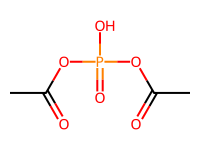
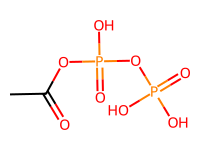
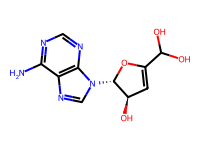
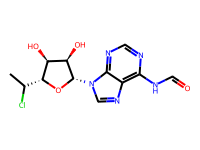
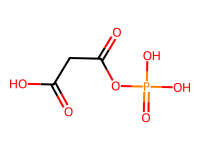
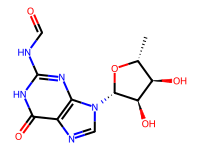
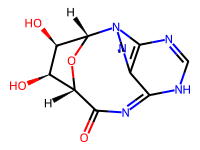
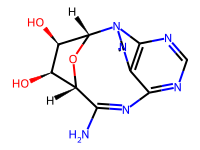
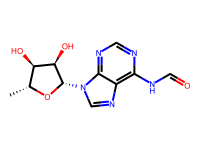
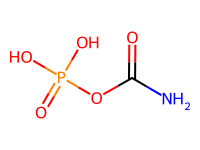
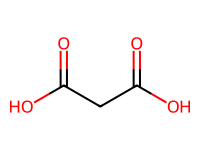
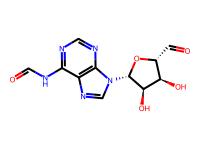
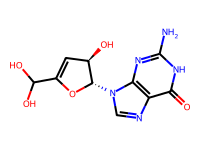
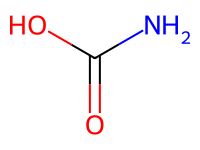
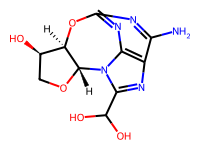
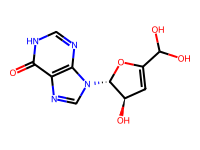
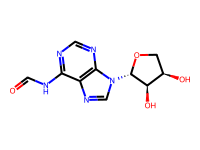
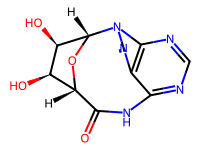
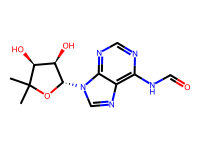
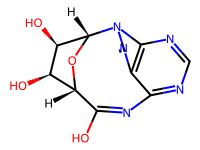

In [33]:
def smilesToImgHtml(smiles, imgSize=(200, 150)):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return ""
    buf = BytesIO()
    Draw.MolToImage(mol, size=imgSize).save(buf, format="PNG")
    encoded = base64.b64encode(buf.getvalue()).decode()
    return f'<img src="data:image/png;base64,{encoded}"/>'

targetCompound_DF["Structure"] = targetCompound_DF["Canonical_SMILES"].apply(smilesToImgHtml)

targetCompound_DF = targetCompound_DF[
    ["Rank", "starter_Canonical_SMILES", "Canonical_SMILES", "Structure", "pPotency_prediction", "pPotency_std", "IC50 (µM)", "source_DataBase"]
]

HTML(targetCompound_DF.to_html(escape=False, index=False))

In [34]:
DORANETmoleculesDataDir = Path(DORANETmoleculesDataDir)

def canonicalizeSmilesCollection(x):
    if not isinstance(x, (set, list, tuple)):
        return []
    out = []
    for s in x:
        c = canonicalizeSmiles(s)
        if c is not None:
            out.append(c)
    return sorted(set(out))

def parseLiteralFromScript(text, varName):
    # captures lines like: varName = {...} / [...] / "..."
    m = re.search(rf"^\s*{re.escape(varName)}\s*=\s*(.+)\s*$", text, flags=re.MULTILINE)
    if not m:
        return None
    raw = m.group(1).strip()
    try:
        return ast.literal_eval(raw)
    except Exception:
        return None

def parseHelpersFromScript(text):
    # Supports YAML-like line: helpers: ["O", ...]
    m = re.search(r"^\s*helpers\s*:\s*(.+)\s*$", text, flags=re.MULTILINE)
    if not m:
        # fallback in case file uses python assignment: helpers = [...]
        return parseLiteralFromScript(text, "helpers")
    raw = m.group(1).strip()
    try:
        return ast.literal_eval(raw)
    except Exception:
        return None

allReproFiles = sorted(
    DORANETmoleculesDataDir.rglob("reproDoranetJob.py"),
    key=lambda p: str(p).lower()
)

records = []
for reproPath in allReproFiles:
    txt = reproPath.read_text(encoding="utf-8", errors="ignore")

    startersRaw = parseLiteralFromScript(txt, "starters")
    targetRaw = parseLiteralFromScript(txt, "target")
    maxAtomsRaw = parseLiteralFromScript(txt, "maxAtoms")
    generationsRaw = parseLiteralFromScript(txt, "generations")
    helpersRaw = parseHelpersFromScript(txt)

    records.append({
        "dirName": reproPath.parent.name,
        "starters": canonicalizeSmilesCollection(startersRaw),
        "target": canonicalizeSmilesCollection(targetRaw),
        "helpers": canonicalizeSmilesCollection(helpersRaw),   # NEW
        "maxAtoms": maxAtomsRaw if isinstance(maxAtomsRaw, dict) else None,
        "generations": int(generationsRaw) if generationsRaw is not None else None,
    })

targetCompoundDir_DF = pd.DataFrame(
    records,
    columns=["dirName", "starters", "target", "helpers", "maxAtoms", "generations"]  # NEW
)

print(f"Total DORAnet configuration files: {len(targetCompoundDir_DF)}")

# join key from first target smiles
targetCompoundDir_DF = targetCompoundDir_DF.copy()
targetCompoundDir_DF["targetSmiles"] = targetCompoundDir_DF["target"].apply(
    lambda x: x[0] if isinstance(x, (list, tuple)) and len(x) > 0 else None
)

colsToAdd = ["Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
targetCompoundDir_DF = targetCompoundDir_DF.merge(
    targetCompound_DF[colsToAdd].drop_duplicates(subset=["Canonical_SMILES"]),
    left_on="targetSmiles",
    right_on="Canonical_SMILES",
    how="left"
).drop(columns=["Canonical_SMILES"])

targetCompoundDir_DF = targetCompoundDir_DF.drop(columns=["targetSmiles"])
targetCompoundDir_DF = targetCompoundDir_DF.rename(columns={
    "starters": "starters_Canonical_SMILES",
    "target": "target_Canonical_SMILES",
    "helpers": "helpers_Canonical_SMILES",   
})

for c in ["starters_Canonical_SMILES", "target_Canonical_SMILES"]:
    targetCompoundDir_DF[c] = targetCompoundDir_DF[c].apply(
        lambda x: ".".join(x) if isinstance(x, (list, tuple)) else ("" if pd.isna(x) else str(x))
    )

# Keep helpers as separate entries joined by comma (not dot)
targetCompoundDir_DF["helpers_Canonical_SMILES"] = targetCompoundDir_DF["helpers_Canonical_SMILES"].apply(
    lambda x: ", ".join(x) if isinstance(x, (list, tuple)) else ("" if pd.isna(x) else str(x))
)

targetCompoundDir_DF = targetCompoundDir_DF.sort_values(
    by="pPotency_prediction", ascending=False
).reset_index(drop=True)

# safer path handling
outputPath = Path(DNADesignResultsDir) / "targetCompoundDir_DF.csv"
targetCompoundDir_DF.to_csv(outputPath, index=False)
targetCompoundDir_DF

Total DORAnet configuration files: 60


,dirName,starters_Canonical_SMILES,target_Canonical_SMILES,helpers_Canonical_SMILES,maxAtoms,generations,pPotency_prediction,pPotency_std,IC50 (µM)
0,high_pPotency_molecule_pathway1_wGen1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",1,5.758,0.479591,1.747229
1,high_pPotency_molecule_pathway1_wGen3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",3,5.758,0.479591,1.747229
2,high_pPotency_molecule_pathway1_wGen2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",2,5.758,0.479591,1.747229
3,high_pPotency_molecule_pathway2_wGen1,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 8, 'S': 1}",1,5.693,0.478908,2.026785
4,high_pPotency_molecule_pathway2_wGen3,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 8, 'S': 1}",3,5.693,0.478908,2.026785
5,high_pPotency_molecule_pathway2_wGen2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 8, 'S': 1}",2,5.693,0.478908,2.026785
6,high_pPotency_molecule_pathway3_wGen2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",2,5.692,0.473252,2.030622
7,high_pPotency_molecule_pathway3_wGen1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",1,5.692,0.473252,2.030622
8,high_pPotency_molecule_pathway3_wGen3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",3,5.692,0.473252,2.030622
9,high_pPotency_molecule_pathway4_wGen3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",3,5.683,0.471067,2.074770


## 2. Read the `reconstructed` pathways metadata for all `DORAnet` reactions

- go to the directory where pathway reconstruction DORAnet results are saved
- run this: `python pathwayReconstruction.py config.yaml`
- this will generate the csv file (`doranet_chain_reconstructed_pathway_steps_by_depth.csv`) with reconstructed pathways
- read the csv file for downstream processing

### Reconstruct pathway directly from multi generation DORAnet outputs

In [35]:
doranetMultiGenConfigPath = Path(DORANETmoleculesDataDir) / "config_doranet_multiGen.yaml"

with open(doranetMultiGenConfigPath, "r", encoding="utf-8") as f:
    doranetCfg = yaml.safe_load(f) or {}

outputDir = Path(doranetCfg.get("outputDir", ".")).expanduser()

# If outputDir is relative, first try relative to config location.
if not outputDir.is_absolute():
    outputDirFromConfigDir = (doranetMultiGenConfigPath.parent / outputDir).resolve()
    outputDirFromCwd = (Path.cwd() / outputDir).resolve()

    summaryCsvName = doranetCfg.get("summaryCsv", "job_summary.csv")
    if (outputDirFromConfigDir / summaryCsvName).exists():
        outputDir = outputDirFromConfigDir
    else:
        outputDir = outputDirFromCwd

summaryPath = Path(DORANETmoleculesDataDir) / "job_summary.csv"

if not summaryPath.exists():
    raise FileNotFoundError(f"Could not find job summary CSV: {summaryPath}")

jobSummaryDF = pd.read_csv(summaryPath)

print(f"Config file : {doranetMultiGenConfigPath}")
print(f"Output dir  : {outputDir}")
print(f"Summary CSV : {summaryPath}")
print(f"Jobs in summary: {len(jobSummaryDF):,}")

Config file : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run3/config_doranet_multiGen.yaml
Output dir  : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run3
Summary CSV : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DORAnet/InoAdeGuoXan/PATHWAY_reconstruction_run3/job_summary.csv
Jobs in summary: 60


In [38]:
def splitMoleculeString(moleculeString):
    if pd.isna(moleculeString):
        return []
    return [mol for mol in str(moleculeString).split(".") if mol]


def sortedMoleculeString(moleculeString):
    mols = splitMoleculeString(moleculeString)
    return ".".join(sorted(mols))


def normalizeReactionSmiles(reactionSmiles):
    """
    Normalize a reaction SMILES by sorting reactant and product molecule strings.

    Input:
        A.B>>C.D

    Output:
        A.B>>C.D with molecules sorted on both sides.
    """
    if pd.isna(reactionSmiles) or ">>" not in str(reactionSmiles):
        return None

    reactants, products = str(reactionSmiles).split(">>", 1)

    reactantsNorm = sortedMoleculeString(reactants)
    productsNorm = sortedMoleculeString(products)

    return f"{reactantsNorm}>>{productsNorm}"


def extractFolderNum(name):
    match = re.search(r"pathway(\d+)", str(name))
    return int(match.group(1)) if match else -1


# Pathway *_pathways.txt parsing helpers

def splitPathwayBlocks(pathwaysTxtPath):
    if not Path(pathwaysTxtPath).exists():
        return []

    lines = Path(pathwaysTxtPath).read_text(encoding="utf-8").splitlines()

    blocks = []
    current = []

    for line in lines:
        if line.startswith("pathway number ") and current:
            blocks.append(current)
            current = [line]
        else:
            current.append(line)

    if current:
        blocks.append(current)

    blocks = [
        [x for x in block if str(x).strip()]
        for block in blocks
        if any(str(x).strip() for x in block)
    ]

    return blocks


def parsePathwayBlock(block):
    """
    Parse one block from DORAnet *_pathways.txt.
    """

    pathwayNumber = None
    for line in block:
        if line.startswith("pathway number "):
            pathwayNumber = str(line).replace("pathway number ", "").strip()
            break

    stoichList = []
    for line in block:
        prefix = "reaction SMILES stoichiometry "
        if line.startswith(prefix):
            payload = line[len(prefix):].strip()
            try:
                stoichList = ast.literal_eval(payload)
            except Exception:
                stoichList = []
            break

    marker = "reaction SMILES, name, and enthalpy:"
    try:
        markerIdx = block.index(marker)
    except ValueError:
        raise ValueError("Could not find reaction SMILES/name/enthalpy marker")

    payloadLines = [x.strip() for x in block[markerIdx + 1:] if str(x).strip()]

    if stoichList:
        numSteps = len(stoichList)
    else:
        if len(payloadLines) % 3 != 0:
            raise ValueError("Cannot infer number of steps from pathway block")
        numSteps = len(payloadLines) // 3
        stoichList = [None] * numSteps

    reactionSmilesList = payloadLines[:numSteps]
    reactionNameList = payloadLines[numSteps:2 * numSteps]
    enthalpyList = payloadLines[2 * numSteps:3 * numSteps]

    if len(reactionSmilesList) != numSteps:
        raise ValueError("Malformed pathway block: reaction count mismatch")

    return {
        "pathwayNumber": pathwayNumber,
        "numSteps": numSteps,
        "reactionSmilesList": reactionSmilesList,
        "reactionNameList": reactionNameList,
        "enthalpyList": enthalpyList,
        "stoichList": stoichList,
    }


def choosePathwayTxt(row):
    """
    Prefer exact-N pathway file generated by filterExactNumRxns.
    Fallback to default *_pathways.txt.
    """

    jobDir = Path(row["jobDir"])
    jobName = str(row["jobName"])
    generationRun = int(row["generationRun"])

    candidatePaths = []

    if "exactPathwaysTxt" in row and pd.notna(row["exactPathwaysTxt"]):
        p = Path(str(row["exactPathwaysTxt"]))
        if not p.is_absolute():
            p = jobDir / p
        candidatePaths.append(p)

    candidatePaths.extend([
        jobDir / f"{jobName}_pathways_exact{generationRun}.txt",
        jobDir / f"{jobName}_pathways.txt",
    ])

    for p in candidatePaths:
        if p.exists():
            return p

    return candidatePaths[0]


def parseReactionSmiles(reactionSmiles):
    if ">>" not in str(reactionSmiles):
        raise ValueError(f"Invalid reaction SMILES: {reactionSmiles}")

    reactants, products = str(reactionSmiles).split(">>", 1)
    return reactants, products


def parseStoich(stoichText):
    if stoichText is None or pd.isna(stoichText):
        return None, None

    parts = str(stoichText).split("$")
    reactantStoich = parts[0] if len(parts) > 0 else None
    productStoich = parts[1] if len(parts) > 1 else None

    return reactantStoich, productStoich


# Network JSON lookup helpers to recover reactionType

def parseNetworkReactionForLookup(rxnString):
    parts = str(rxnString).split(">")

    if len(parts) != 4:
        return None

    reactants, ruleName, metaBlock, products = parts

    metaParts = (metaBlock.split("$") + [None, None, None, None])[:4]
    thermo, reactantStoich, productStoich, reactionType = metaParts

    reactionSmiles = f"{reactants}>>{products}"
    normalizedReactionSmiles = normalizeReactionSmiles(reactionSmiles)

    return {
        "reactionSMILES": reactionSmiles,
        "normalizedReactionSMILES": normalizedReactionSmiles,
        "ruleName": ruleName,
        "thermo": thermo,
        "reactantStoich": reactantStoich,
        "productStoich": productStoich,
        "reactionType": reactionType,
        "rawNetworkReactionString": str(rxnString),
    }


def buildNetworkReactionLookup(networkJsonPath):
    networkJsonPath = Path(networkJsonPath)

    lookupByReactionAndRule = {}
    lookupByReactionOnly = {}

    if not networkJsonPath.exists():
        return lookupByReactionAndRule, lookupByReactionOnly

    try:
        with open(networkJsonPath, "r", encoding="utf-8") as f:
            reactionList = json.load(f)
    except Exception:
        return lookupByReactionAndRule, lookupByReactionOnly

    if not isinstance(reactionList, list):
        return lookupByReactionAndRule, lookupByReactionOnly

    for rxnString in reactionList:
        parsed = parseNetworkReactionForLookup(rxnString)

        if parsed is None:
            continue

        normRxn = parsed["normalizedReactionSMILES"]
        ruleName = parsed["ruleName"]

        if normRxn is None:
            continue

        lookupByReactionAndRule[(normRxn, ruleName)] = parsed

        if normRxn not in lookupByReactionOnly:
            lookupByReactionOnly[normRxn] = parsed

    return lookupByReactionAndRule, lookupByReactionOnly


def lookupNetworkReactionMetadata(reactionSmiles, ruleName, lookupByReactionAndRule, lookupByReactionOnly):
    normalizedReactionSmiles = normalizeReactionSmiles(reactionSmiles)

    if normalizedReactionSmiles is None:
        return {
            "reactionType": "",
            "rawNetworkReactionString": "",
            "networkMatchStatus": "invalid_reaction_smiles",
        }

    match = lookupByReactionAndRule.get((normalizedReactionSmiles, ruleName))

    if match is not None:
        out = dict(match)
        out["networkMatchStatus"] = "matched_by_reaction_and_rule"
        return out

    match = lookupByReactionOnly.get(normalizedReactionSmiles)

    if match is not None:
        out = dict(match)
        out["networkMatchStatus"] = "matched_by_reaction_only"
        return out

    return {
        "reactionType": "",
        "rawNetworkReactionString": "",
        "networkMatchStatus": "no_network_match",
    }


def extractFullReactionSmiles(rawNetworkReactionString):
    if not rawNetworkReactionString or not str(rawNetworkReactionString).strip():
        return None
    parts = str(rawNetworkReactionString).split(">")
    if len(parts) != 4:
        return None
    return f"{parts[0].strip()}>>{parts[3].strip()}"


def identifyCofactors(fullReactionSMILES, simplifiedReactionSMILES, helperSet, starterSet, targetSMILES):
    if not fullReactionSMILES or ">>" not in str(fullReactionSMILES):
        return "", ""
    if not simplifiedReactionSMILES or ">>" not in str(simplifiedReactionSMILES):
        return "", ""
    fullR,  fullP = str(fullReactionSMILES).split(">>", 1)
    simpR,  simpP = str(simplifiedReactionSMILES).split(">>", 1)
    fullReactantSet = {s.strip() for s in fullR.split(".") if s.strip()}
    simpReactantSet = {s.strip() for s in simpR.split(".") if s.strip()}
    fullProductSet  = {s.strip() for s in fullP.split(".") if s.strip()}
    simpProductSet  = {s.strip() for s in simpP.split(".") if s.strip()}
    knownMols = helperSet | starterSet | {targetSMILES}
    cofactorReactants = ";".join(sorted(fullReactantSet - simpReactantSet - knownMols))
    cofactorProducts  = ";".join(sorted(fullProductSet  - simpProductSet  - knownMols))
    return cofactorReactants, cofactorProducts


def readStartersFromReproScript(jobDir):
    """
    Recover the exact starter set DORAnet ran for a job by parsing the
    reproDoranetJob.py saved inside the job directory. Returns a set of
    SMILES strings, or an empty set if the file or the assignment is absent.
    """
    scriptPath = Path(jobDir) / "reproDoranetJob.py"
    if not scriptPath.exists():
        return set()
    try:
        tree = ast.parse(scriptPath.read_text(encoding="utf-8"))
    except Exception:
        return set()
    for node in ast.walk(tree):
        if isinstance(node, ast.Assign):
            for tgt in node.targets:
                if isinstance(tgt, ast.Name) and tgt.id == "starters":
                    try:
                        value = ast.literal_eval(node.value)
                    except Exception:
                        return set()
                    if isinstance(value, (set, list, tuple)):
                        return {str(s).strip() for s in value if str(s).strip()}
                    if isinstance(value, str) and value.strip():
                        return {value.strip()}
    return set()


helperSet = set(doranetCfg.get("helpers", []))

# Per-target starter fallback map from the input CSV (target -> starter)
targetToStarter = (
    targetCompound_DF
    .assign(_canonTarget=targetCompound_DF["Canonical_SMILES"].apply(canonicalizeSmiles))
    .dropna(subset=["_canonTarget"])
    .drop_duplicates("_canonTarget")
    .set_index("_canonTarget")["starter_Canonical_SMILES"]
    .to_dict()
)

records     = []
parseErrors = []
networkLookupCache = {}
starterSourceCounts = {"reproScript": 0, "summaryColumn": 0, "csvMap": 0, "none": 0}

validJobsDF = jobSummaryDF.copy()
if "status" in validJobsDF.columns:
    validJobsDF = validJobsDF[validJobsDF["status"].eq("ok")].copy()

for _, jobRow in tqdm(validJobsDF.iterrows(), total=len(validJobsDF), desc="Reading DORAnet pathway files"):
    jobName       = str(jobRow["jobName"])
    jobDir        = Path(jobRow["jobDir"])
    dirName       = jobDir.name
    generationRun = int(jobRow["generationRun"])
    targetSMILES  = str(jobRow["targetSmiles"])

    # Resolve the starter for this job: reproDoranetJob.py first, then the
    # summary column, then the CSV target -> starter map.
    jobStarterSet = readStartersFromReproScript(jobDir)
    if jobStarterSet:
        starterSourceCounts["reproScript"] += 1
    else:
        summaryStarter = str(jobRow.get("starterSmiles", "")).strip()
        if summaryStarter and summaryStarter.lower() != "nan":
            jobStarterSet = {summaryStarter}
            starterSourceCounts["summaryColumn"] += 1
        else:
            csvStarter = str(targetToStarter.get(canonicalizeSmiles(targetSMILES), "")).strip()
            if csvStarter and csvStarter.lower() != "nan":
                jobStarterSet = {csvStarter}
                starterSourceCounts["csvMap"] += 1
            else:
                starterSourceCounts["none"] += 1

    starterSMILESValue = ";".join(sorted(jobStarterSet))

    pathwayTxtPath  = choosePathwayTxt(jobRow)
    networkJsonPath = jobDir / f"{jobName}_network_pretreated.json"

    if jobName not in networkLookupCache:
        networkLookupCache[jobName] = buildNetworkReactionLookup(networkJsonPath)
    lookupByReactionAndRule, lookupByReactionOnly = networkLookupCache[jobName]

    try:
        blocks = splitPathwayBlocks(pathwayTxtPath)

        for blockIdx, block in enumerate(blocks, start=1):
            parsed = parsePathwayBlock(block)

            numSteps      = parsed["numSteps"]
            pathwayNumber = parsed["pathwayNumber"] or str(blockIdx)
            routeId = (
                f"{jobName}_route_{int(pathwayNumber):06d}"
                if str(pathwayNumber).isdigit()
                else f"{jobName}_route_{blockIdx:06d}"
            )

            reconstructedPathwayString = "  ||  ".join(parsed["reactionSmilesList"])

            for stepIdx, reactionSmiles in enumerate(parsed["reactionSmilesList"], start=1):
                reactants, products = parseReactionSmiles(reactionSmiles)

                ruleName             = parsed["reactionNameList"][stepIdx - 1] if stepIdx - 1 < len(parsed["reactionNameList"]) else ""
                thermoFromPathwayTxt = parsed["enthalpyList"][stepIdx - 1]     if stepIdx - 1 < len(parsed["enthalpyList"])     else ""
                stoichText           = parsed["stoichList"][stepIdx - 1]       if stepIdx - 1 < len(parsed["stoichList"])       else None

                reactantStoichFromTxt, productStoichFromTxt = parseStoich(stoichText)

                networkMatch = lookupNetworkReactionMetadata(
                    reactionSmiles=reactionSmiles,
                    ruleName=ruleName,
                    lookupByReactionAndRule=lookupByReactionAndRule,
                    lookupByReactionOnly=lookupByReactionOnly,
                )

                reactionType             = networkMatch.get("reactionType", "")
                rawNetworkReactionString = networkMatch.get("rawNetworkReactionString", "")
                networkMatchStatus       = networkMatch.get("networkMatchStatus", "")

                thermo         = thermoFromPathwayTxt if thermoFromPathwayTxt not in ["", None] else networkMatch.get("thermo", "")
                reactantStoich = reactantStoichFromTxt if reactantStoichFromTxt not in ["", None] else networkMatch.get("reactantStoich", None)
                productStoich  = productStoichFromTxt  if productStoichFromTxt  not in ["", None] else networkMatch.get("productStoich",  None)

                fullReactionSMILES = extractFullReactionSmiles(rawNetworkReactionString)

                cofactorReactants, cofactorProducts = identifyCofactors(
                    fullReactionSMILES, reactionSmiles, helperSet, jobStarterSet, targetSMILES
                )

                activeReactionSMILES     = fullReactionSMILES if fullReactionSMILES else reactionSmiles
                activeReactants, activeProducts = parseReactionSmiles(activeReactionSMILES)
                reactantMols = set(splitMoleculeString(activeReactants))
                productMols  = set(splitMoleculeString(activeProducts))

                records.append({
                    "dirName"                   : dirName,
                    "jobName"                   : jobName,
                    "sourceFolderNum"           : extractFolderNum(jobName),
                    "sourceDirectory"           : dirName,
                    "sourceDirectoryPath"       : str(jobDir),
                    "sourceJsonName"            : f"{jobName}_network_pretreated.json",
                    "sourceJsonPath"            : str(networkJsonPath),
                    "sourcePathwaysTxtPath"     : str(pathwayTxtPath),
                    "routeId"                   : routeId,
                    "routeNumberInFile"         : pathwayNumber,
                    "generationRun"             : generationRun,
                    "searchDepthUsed"           : generationRun,
                    "step"                      : stepIdx,
                    "numSteps"                  : numSteps,
                    "starterSMILES"             : starterSMILESValue,
                    "targetSMILES"              : targetSMILES,
                    "reactants"                 : activeReactants,
                    "products"                  : activeProducts,
                    "reactionString"            : f"{activeReactants} >> {activeProducts}",
                    "reactionSMILES"            : activeReactionSMILES,
                    "simplifiedReactionSMILES"  : reactionSmiles,
                    "fullReactionSMILES"        : fullReactionSMILES or "",
                    "reconstructedPathwayString": reconstructedPathwayString,
                    "cofactorReactants"         : cofactorReactants,
                    "cofactorProducts"          : cofactorProducts,
                    "hasCofactors"              : bool(cofactorReactants or cofactorProducts),
                    "ruleName"                  : ruleName,
                    "thermo"                    : thermo,
                    "reactantStoich"            : reactantStoich,
                    "productStoich"             : productStoich,
                    "reactionType"              : reactionType,
                    "rawNetworkReactionString"  : rawNetworkReactionString,
                    "networkMatchStatus"        : networkMatchStatus,
                    "numReactantMolecules"      : len(reactantMols),
                    "numProductMolecules"       : len(productMols),
                    "starterInReactants"        : bool(reactantMols & jobStarterSet),
                    "targetInProducts"          : targetSMILES in productMols,
                    "isReconstructedPathwayStep": True,
                    "routeStepId"               : f"{routeId}_step_{stepIdx:02d}",
                })

    except Exception as exc:
        parseErrors.append({
            "jobName"        : jobName,
            "jobDir"         : str(jobDir),
            "generationRun"  : generationRun,
            "targetSMILES"   : targetSMILES,
            "pathwayTxtPath" : str(pathwayTxtPath),
            "networkJsonPath": str(networkJsonPath),
            "error"          : str(exc),
        })


sortColumns = ["sourceFolderNum", "generationRun", "routeId", "step"]

if not records:
    raise ValueError(
        f"No pathway records were parsed: validJobs={len(validJobsDF)}, "
        f"parseErrors={len(parseErrors)}. Check the status filter on validJobsDF, "
        f"the pathway .txt paths from choosePathwayTxt, and parseErrorsDF."
    )

reconstructedPathwaysDF = (
    pd.DataFrame(records)
    .sort_values(sortColumns)
    .reset_index(drop=True)
)

fullPathwayPerRoute = (
    reconstructedPathwaysDF
    .sort_values(["routeId", "step"])
    .groupby("routeId", as_index=False)["fullReactionSMILES"]
    .apply(lambda g: "  ||  ".join(g.dropna()))
    .rename(columns={"fullReactionSMILES": "fullReconstructedPathwayString"})
)
reconstructedPathwaysDF = reconstructedPathwaysDF.merge(fullPathwayPerRoute, on="routeId", how="left")

parseErrorsDF = pd.DataFrame(parseErrors)

print(f"Reconstructed pathway step rows : {len(reconstructedPathwaysDF):,}")
print(f"Unique routes                   : {reconstructedPathwaysDF['routeId'].nunique() if not reconstructedPathwaysDF.empty else 0:,}")
print(f"Unique job folders              : {reconstructedPathwaysDF['dirName'].nunique() if not reconstructedPathwaysDF.empty else 0:,}")
print(f"Unique target SMILES            : {reconstructedPathwaysDF['targetSMILES'].nunique() if not reconstructedPathwaysDF.empty else 0:,}")
print(f"Steps with cofactors            : {reconstructedPathwaysDF['hasCofactors'].sum():,}")
print(f"Parse errors                    : {len(parseErrorsDF):,}")
print(f"Starter source (jobs)           : {starterSourceCounts}")

if not reconstructedPathwaysDF.empty:
    print("\nReaction type counts:")
    print(reconstructedPathwaysDF["reactionType"].value_counts(dropna=False).to_string())
    print("\nNetwork match status:")
    print(reconstructedPathwaysDF["networkMatchStatus"].value_counts(dropna=False).to_string())
    print("\nTop cofactor reactants:")
    print(
        reconstructedPathwaysDF["cofactorReactants"]
        .replace("", pd.NA).dropna()
        .str.split(";").explode()
        .value_counts().head(15).to_string()
    )

reconstructedPathwaysDF

Reading DORAnet pathway files: 100%|███████████████████████████████████████████████████████████████████████| 57/57 [00:01<00:00, 53.33it/s]


Reconstructed pathway step rows : 449
Unique routes                   : 150
Unique job folders              : 18
Unique target SMILES            : 18
Steps with cofactors            : 0
Parse errors                    : 0
Starter source (jobs)           : {'reproScript': 57, 'summaryColumn': 0, 'csvMap': 0, 'none': 0}

Reaction type counts:
reactionType
Enzymatic    449

Network match status:
networkMatchStatus
matched_by_reaction_and_rule    449

Top cofactor reactants:
Series([], )


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,reactionType,rawNetworkReactionString,networkMatchStatus,numReactantMolecules,numProductMolecules,starterInReactants,targetInProducts,isReconstructedPathwayStep,routeStepId,fullReconstructedPathwayString
0,high_pPotency_molecule_pathway1_wGen3,high_pPotency_molecule_pathway1_wGen3,1,high_pPotency_molecule_pathway1_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_route_00...,1,...,Enzymatic,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,matched_by_reaction_and_rule,2,2,False,False,True,high_pPotency_molecule_pathway1_wGen3_route_00...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...
1,high_pPotency_molecule_pathway1_wGen3,high_pPotency_molecule_pathway1_wGen3,1,high_pPotency_molecule_pathway1_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_route_00...,1,...,Enzymatic,CC(=O)OP(=O)(O)O.CC(=O)OP(=O)(O)O>rule0097_3>N...,matched_by_reaction_and_rule,1,2,False,True,True,high_pPotency_molecule_pathway1_wGen3_route_00...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...
2,high_pPotency_molecule_pathway1_wGen3,high_pPotency_molecule_pathway1_wGen3,1,high_pPotency_molecule_pathway1_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_route_00...,1,...,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,True,False,True,high_pPotency_molecule_pathway1_wGen3_route_00...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...
3,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,1,...,Enzymatic,CC(=O)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C...,matched_by_reaction_and_rule,2,2,False,False,True,high_pPotency_molecule_pathway2_wGen3_route_00...,CC(=O)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C...
4,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,1,...,Enzymatic,CC(=O)OP(=O)(O)O.CC(=O)OP(=O)(O)O>rule0029_7>N...,matched_by_reaction_and_rule,1,2,False,True,True,high_pPotency_molecule_pathway2_wGen3_route_00...,CC(=O)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,19,high_pPotency_molecule_pathway19_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_route_0...,3,...,Enzymatic,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C)[C@@H](O)[...,matched_by_reaction_and_rule,1,1,False,True,True,high_pPotency_molecule_pathway19_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C)[C@@H](O)[...
445,high_pPotency_molecule_pathway19_wGen3,high_pPo

### Print unique `target SMILES`

In [39]:
if not reconstructedPathwaysDF.empty:
    # Per-target route counts broken down by step depth
    print("\nReaction type counts:")
    print(reconstructedPathwaysDF["reactionType"].value_counts(dropna=False).to_string())

    stepCountsDF = (
        reconstructedPathwaysDF
        .groupby(["targetSMILES", "numSteps"])["routeId"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=[1, 2, 3], fill_value=0)
        .rename(columns={1: "1-step", 2: "2-step", 3: "3-step"})
    )
    stepCountsDF["totalRoutes"] = stepCountsDF.sum(axis=1)
    stepCountsDF["pPotency_prediction"] = stepCountsDF.index.map(
        targetCompound_DF.set_index("Canonical_SMILES")["pPotency_prediction"]
    )
    stepCountsDF["starter_Canonical_SMILES"] = stepCountsDF.index.map(
        targetCompound_DF.set_index("Canonical_SMILES")["starter_Canonical_SMILES"]
    )
    stepCountsDF = stepCountsDF.sort_values("totalRoutes", ascending=False).reset_index()

    firstCols = ["starter_Canonical_SMILES", "targetSMILES"]
    stepCountsDF = stepCountsDF[firstCols + [c for c in stepCountsDF.columns if c not in firstCols]]

print("\nTarget SMILES found:")
stepCountsDF


Reaction type counts:
reactionType
Enzymatic    449

Target SMILES found:


numSteps,starter_Canonical_SMILES,targetSMILES,1-step,2-step,3-step,totalRoutes,pPotency_prediction
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,O=CNc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O)[C...,0,0,73,73,5.645
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@...,0,0,24,24,5.667
2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H...,0,0,21,21,5.677
3,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C(O)CC(=O)O,0,0,15,15,5.651
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC1(C)O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@...,0,0,3,3,5.616
5,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,0,0,2,2,5.679
6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,0,0,1,1,5.693
7,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,0,0,1,1,5.758
8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,0,0,1,1,5.669
9,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,0,0,1,1,5.683


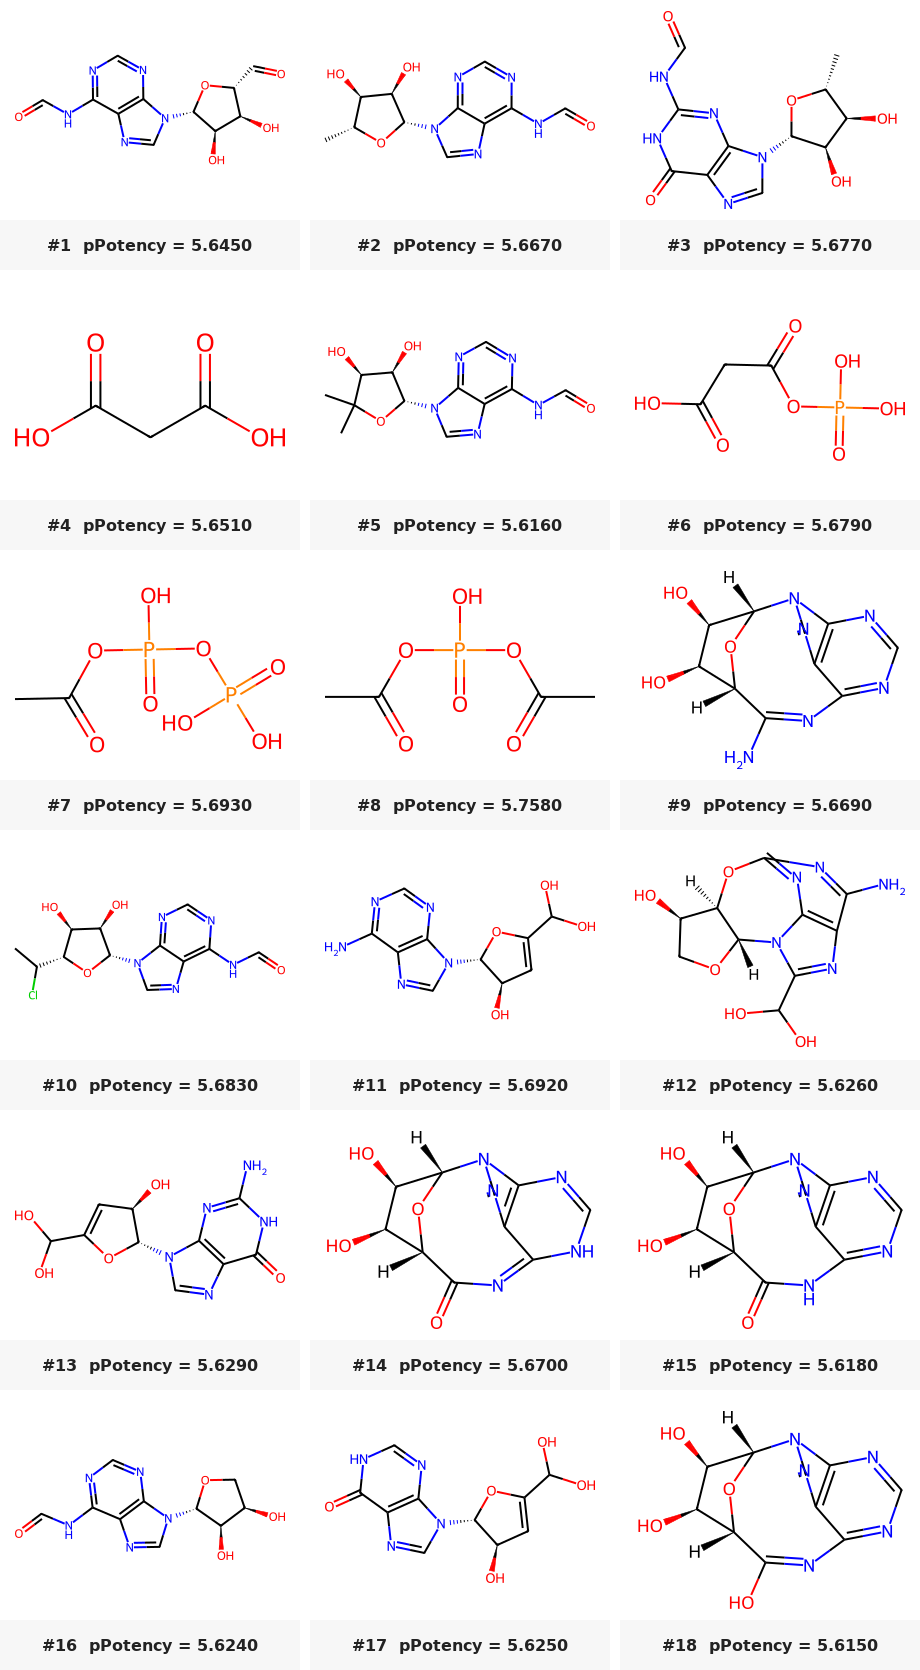

In [40]:
# CONFIG
molsPerRow  = 3
subImgSize  = (300, 220)
labelHeight = 50

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

labelFont = loadFont(16)

def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)

def makeMolPanel(smiles, pPotency, rank, subImageSize=(300, 220), labelHeight=50):
    canon = canonicalizeSmiles(str(smiles))
    mol   = Chem.MolFromSmiles(canon)
    if mol is None:
        return None
    molImg = Draw.MolToImage(mol, size=subImageSize).convert("RGB")
    pLabel = f"pPotency = {pPotency:.4f}" if pPotency is not None and not pd.isna(pPotency) else "pPotency = N/A"
    label  = f"#{rank}  {pLabel}"
    banner = Image.new("RGB", (molImg.width, labelHeight), "#f7f7f7")
    centeredText(ImageDraw.Draw(banner), label, molImg.width, (labelHeight - 18) // 2, labelFont, "#222222")
    combined = Image.new("RGB", (molImg.width, molImg.height + banner.height), "white")
    combined.paste(molImg,  (0, 0))
    combined.paste(banner,  (0, molImg.height))
    return combined

def renderGridWithLabels(df, smileCol, labelCol, molsPerRow=3, subImageSize=(300, 220), labelHeight=50):
    panels = []
    for rank, (_, row) in enumerate(df.iterrows(), start=1):
        panel = makeMolPanel(row[smileCol], row[labelCol], rank, subImageSize, labelHeight)
        if panel is not None:
            panels.append(panel)

    if not panels:
        print("No valid structures to display.")
        return

    panelW  = panels[0].width
    panelH  = panels[0].height
    gap     = 10
    nRows   = (len(panels) + molsPerRow - 1) // molsPerRow
    canvasW = molsPerRow * panelW + (molsPerRow - 1) * gap
    canvasH = nRows * panelH + (nRows - 1) * gap
    canvas  = Image.new("RGB", (canvasW, canvasH), "white")

    for idx, panel in enumerate(panels):
        r = idx // molsPerRow
        c = idx  % molsPerRow
        canvas.paste(panel, (c * (panelW + gap), r * (panelH + gap)))

    display(canvas)

renderGridWithLabels(
    df           = stepCountsDF,
    smileCol     = "targetSMILES",
    labelCol     = "pPotency_prediction",
    molsPerRow   = molsPerRow,
    subImageSize = subImgSize,
    labelHeight  = labelHeight,
)

# Select a compund from `stepCountsDF` which has maximum number of pathways for downstream `DNA designs`

In [78]:
stepCountsDF_selectedCompound = 4   # 0-indexed: 0 = most routes, 1 = second, 2 = third

In [79]:
bestSmiles = stepCountsDF.loc[stepCountsDF_selectedCompound, "targetSMILES"]
bestStarterSmiles = stepCountsDF.loc[stepCountsDF_selectedCompound, "starter_Canonical_SMILES"]

reconstructedPathwaysDF_OneCompound = (
    reconstructedPathwaysDF[reconstructedPathwaysDF["targetSMILES"] == bestSmiles]
    .reset_index(drop=True)
)
reconstructedPathwaysDF_OneCompound["starter_Canonical_SMILES"] = bestStarterSmiles

print(f"Selected target (rank {stepCountsDF_selectedCompound + 1}) : {bestSmiles}")
print(f"  starter_Canonical_SMILES : {bestStarterSmiles}")
print(f"  pPotency_prediction      : {stepCountsDF.loc[stepCountsDF_selectedCompound, 'pPotency_prediction']:.4f}")
print(f"  Routes                   : {reconstructedPathwaysDF_OneCompound['routeId'].nunique():,}")
print(f"  Step rows                : {len(reconstructedPathwaysDF_OneCompound):,}")
reconstructedPathwaysDF_OneCompound

Selected target (rank 5) : CC1(C)O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@H]1O
  starter_Canonical_SMILES : Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
  pPotency_prediction      : 5.6160
  Routes                   : 3
  Step rows                : 9


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,rawNetworkReactionString,networkMatchStatus,numReactantMolecules,numProductMolecules,starterInReactants,targetInProducts,isReconstructedPathwayStep,routeStepId,fullReconstructedPathwayString,starter_Canonical_SMILES
0,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,19,high_pPotency_molecule_pathway19_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_route_0...,1,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,matched_by_reaction_and_rule,1,1,False,False,True,high_pPotency_molecule_pathway19_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
1,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,19,high_pPotency_molecule_pathway19_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_route_0...,1,...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,True,False,True,high_pPotency_molecule_pathway19_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
2,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,19,high_pPotency_molecule_pathway19_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_route_0...,1,...,C[C@@]1(CO)O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O...,matched_by_reaction_and_rule,3,3,False,True,True,high_pPotency_molecule_pathway19_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
3,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,19,high_pPotency_molecule_pathway19_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_route_0...,2,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C)[C@@H](O)[...,matched_by_reaction_and_rule,1,1,False,True,True,high_pPotency_molecule_pathway19_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C)[C@@H](O)[...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
4,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,19,high_pPotency_molecule_pathway19_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_route_0...,2,...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,False,False,True,high_pPotency_molecule_pathway19_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C)[C@@H](O)[...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
5,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,19,high_pPotency_molecule_pathway19_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_route_0...,2,...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,matched_by_reaction_and_rule,3,3,True,False,True,high_pPotency_molecule_pathwa

In [80]:
completeRouteLevelDF = (
    reconstructedPathwaysDF_OneCompound
    .sort_values(["dirName", "routeId", "step"])
    .groupby("routeId", as_index=False)
    .agg(
        dirName=("dirName", "first"),
        jobName=("jobName", "first"),
        sourceFolderNum=("sourceFolderNum", "first"),
        generationRun=("generationRun", "first"),
        numSteps=("numSteps", "first"),
        searchDepthUsed=("searchDepthUsed", "first"),
        starter_Canonical_SMILES=("starter_Canonical_SMILES", "first"),
        targetSMILES=("targetSMILES", "first"),
        reconstructedPathwayString=("reconstructedPathwayString", "first"),
    )
)
starterTargetPathwayCountsDF = (
    completeRouteLevelDF
    .pivot_table(
        index=["dirName", "jobName", "generationRun", "starter_Canonical_SMILES", "targetSMILES"],
        columns="numSteps",
        values="routeId",
        aggfunc="nunique",
        fill_value=0,
    )
    .rename(columns={
        1: "numOneStepPathways",
        2: "numTwoStepPathways",
        3: "numThreeStepPathways",
    })
    .reset_index()
)
for c in ["numOneStepPathways", "numTwoStepPathways", "numThreeStepPathways"]:
    if c not in starterTargetPathwayCountsDF.columns:
        starterTargetPathwayCountsDF[c] = 0
starterTargetPathwayCountsDF["totalStarterToTargetPathways"] = (
    starterTargetPathwayCountsDF["numOneStepPathways"]
    + starterTargetPathwayCountsDF["numTwoStepPathways"]
    + starterTargetPathwayCountsDF["numThreeStepPathways"]
)
starterTargetPathwayCountsDF = (
    starterTargetPathwayCountsDF
    .sort_values("totalStarterToTargetPathways", ascending=False)
    .reset_index(drop=True)
)
print(f"Total reaction-step rows             : {len(reconstructedPathwaysDF_OneCompound):,}")
print(f"Complete starter --> target pathways: {len(completeRouteLevelDF):,}")
print(f"Job folders reached starter --> target: {starterTargetPathwayCountsDF['dirName'].nunique():,}")
starterTargetPathwayCountsDF

Total reaction-step rows             : 9
Complete starter --> target pathways: 3
Job folders reached starter --> target: 1


numSteps,dirName,jobName,generationRun,starter_Canonical_SMILES,targetSMILES,numThreeStepPathways,numOneStepPathways,numTwoStepPathways,totalStarterToTargetPathways
0,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC1(C)O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@...,3,0,0,3


### Show `starter` and `target` compound

[Starter] Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
[Target] CC1(C)O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@H]1O


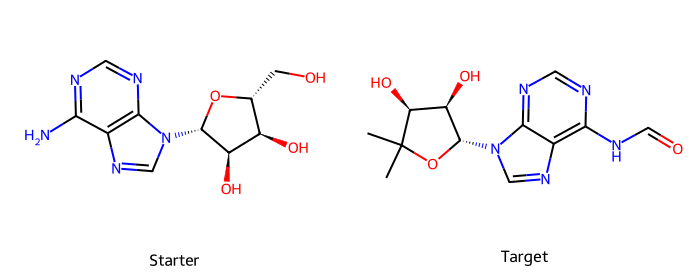

In [81]:
# Extract unique starter and target SMILES from the selected compound's pathways
starterSmilesList = [
    s.strip()
    for raw in reconstructedPathwaysDF_OneCompound["starter_Canonical_SMILES"].dropna().unique()
    for s in raw.split(";") if s.strip()
]
targetSmilesList = [bestSmiles]

for i, s in enumerate(starterSmilesList):
    print(f"[Starter] {s}")

for i, s in enumerate(targetSmilesList):
    print(f"[Target] {s}")

# Use short index labels in the image, full strings printed above
starterMols = [(Chem.MolFromSmiles(s), f"Starter") for i, s in enumerate(starterSmilesList)]
targetMols  = [(Chem.MolFromSmiles(s), f"Target")  for i, s in enumerate(targetSmilesList)]

allMols   = [m for m, _ in starterMols + targetMols if m is not None]
allLabels = [l for m, l in starterMols + targetMols if m is not None]

img = Draw.MolsToGridImage(
    allMols,
    molsPerRow=len(allMols),
    subImgSize=(350, 280),
    legends=allLabels,
)
display(img)

### Show some example `reaction pathways`


3-step pathways: 3 available, displaying 3
  [1/3] Route: high_pPotency_molecule_pathway19_wGen3_route_000001


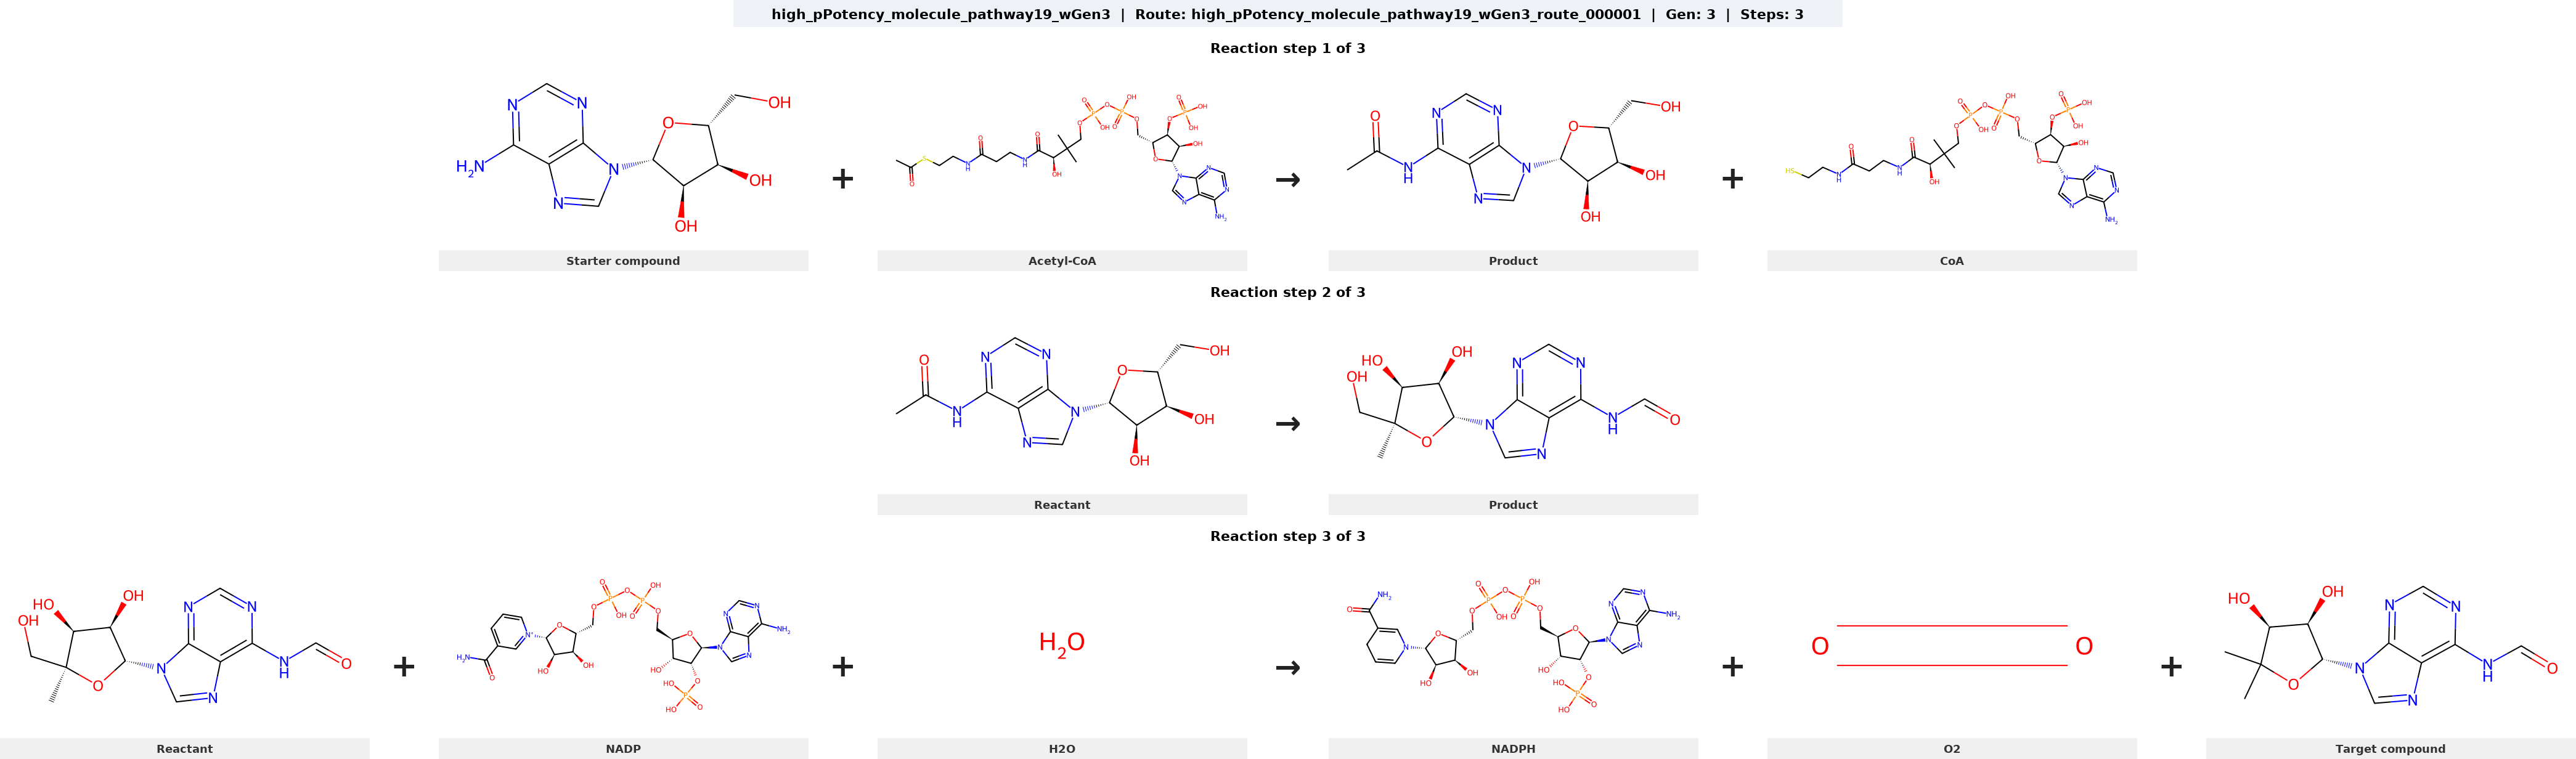

      saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathway_high_pPotency_molecule_pathway19_wGen3_route_000001_3step.png
      saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathway_high_pPotency_molecule_pathway19_wGen3_route_000001_3step.pdf
  [2/3] Route: high_pPotency_molecule_pathway19_wGen3_route_000002


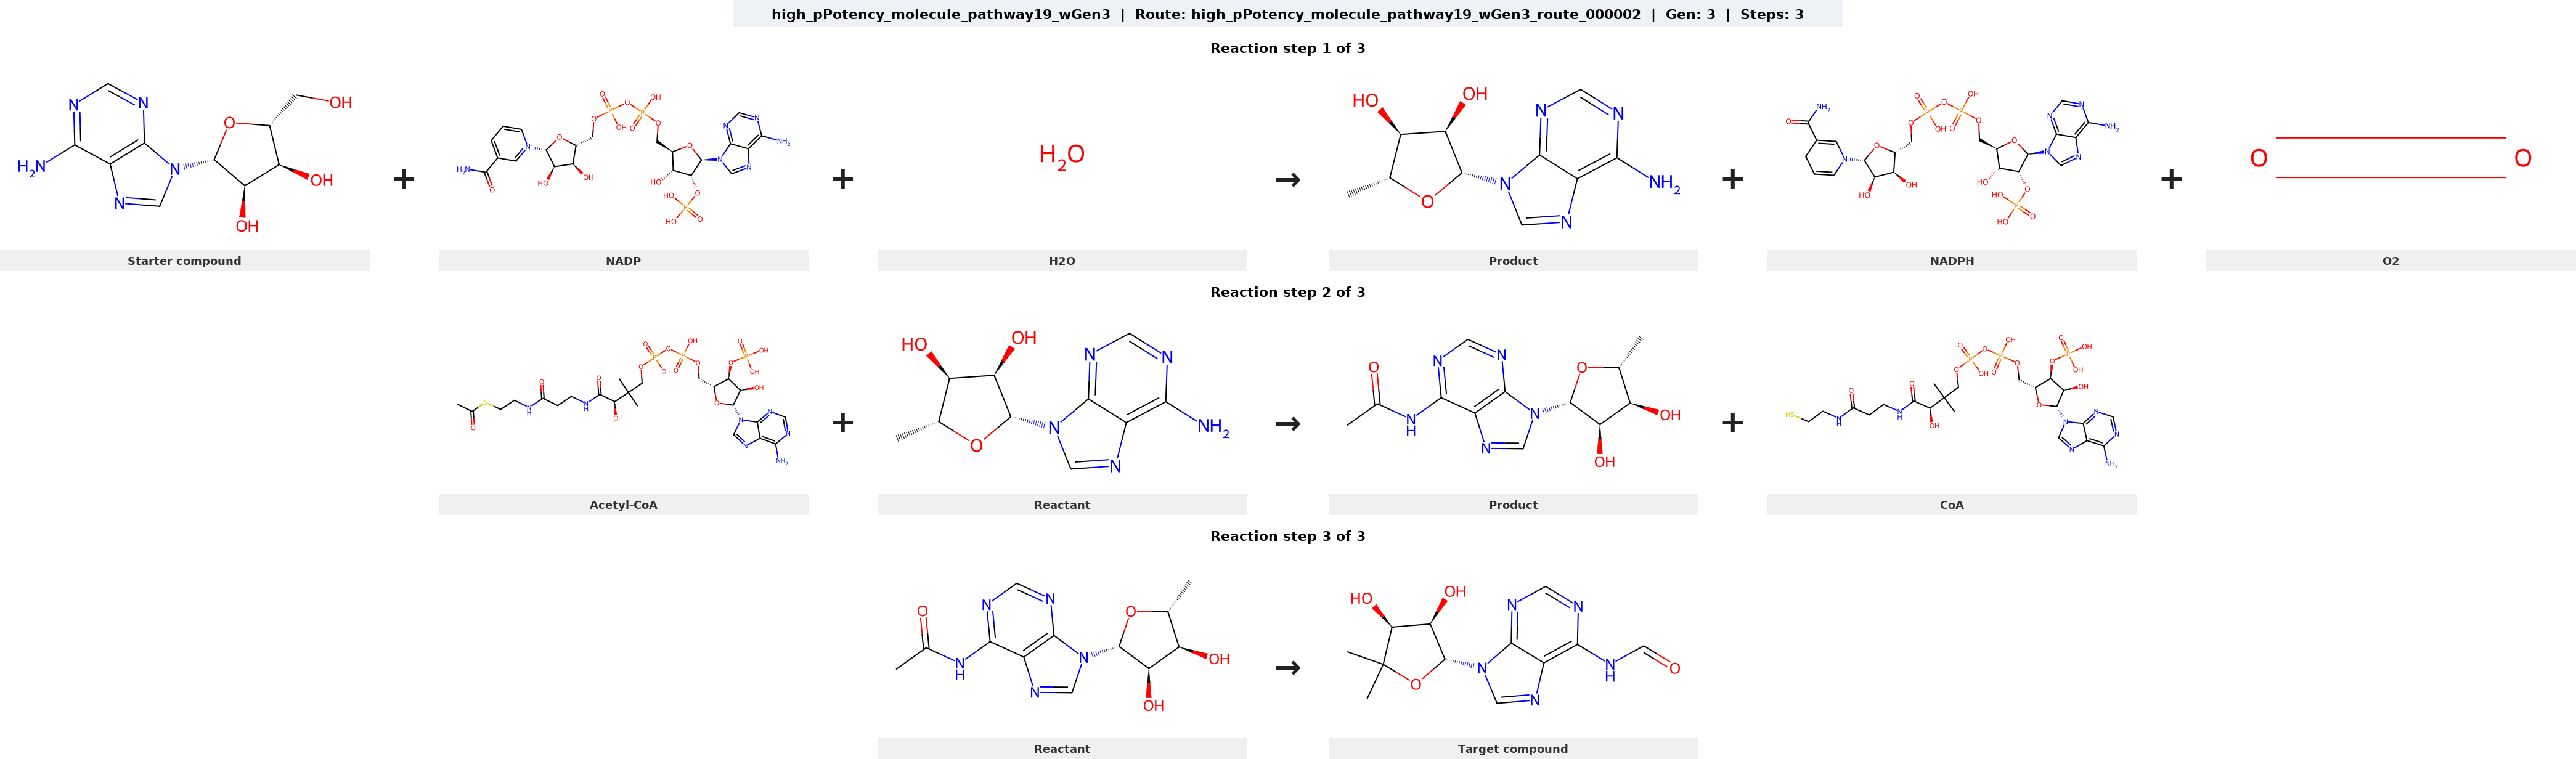

      saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathway_high_pPotency_molecule_pathway19_wGen3_route_000002_3step.png
      saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathway_high_pPotency_molecule_pathway19_wGen3_route_000002_3step.pdf
  [3/3] Route: high_pPotency_molecule_pathway19_wGen3_route_000003


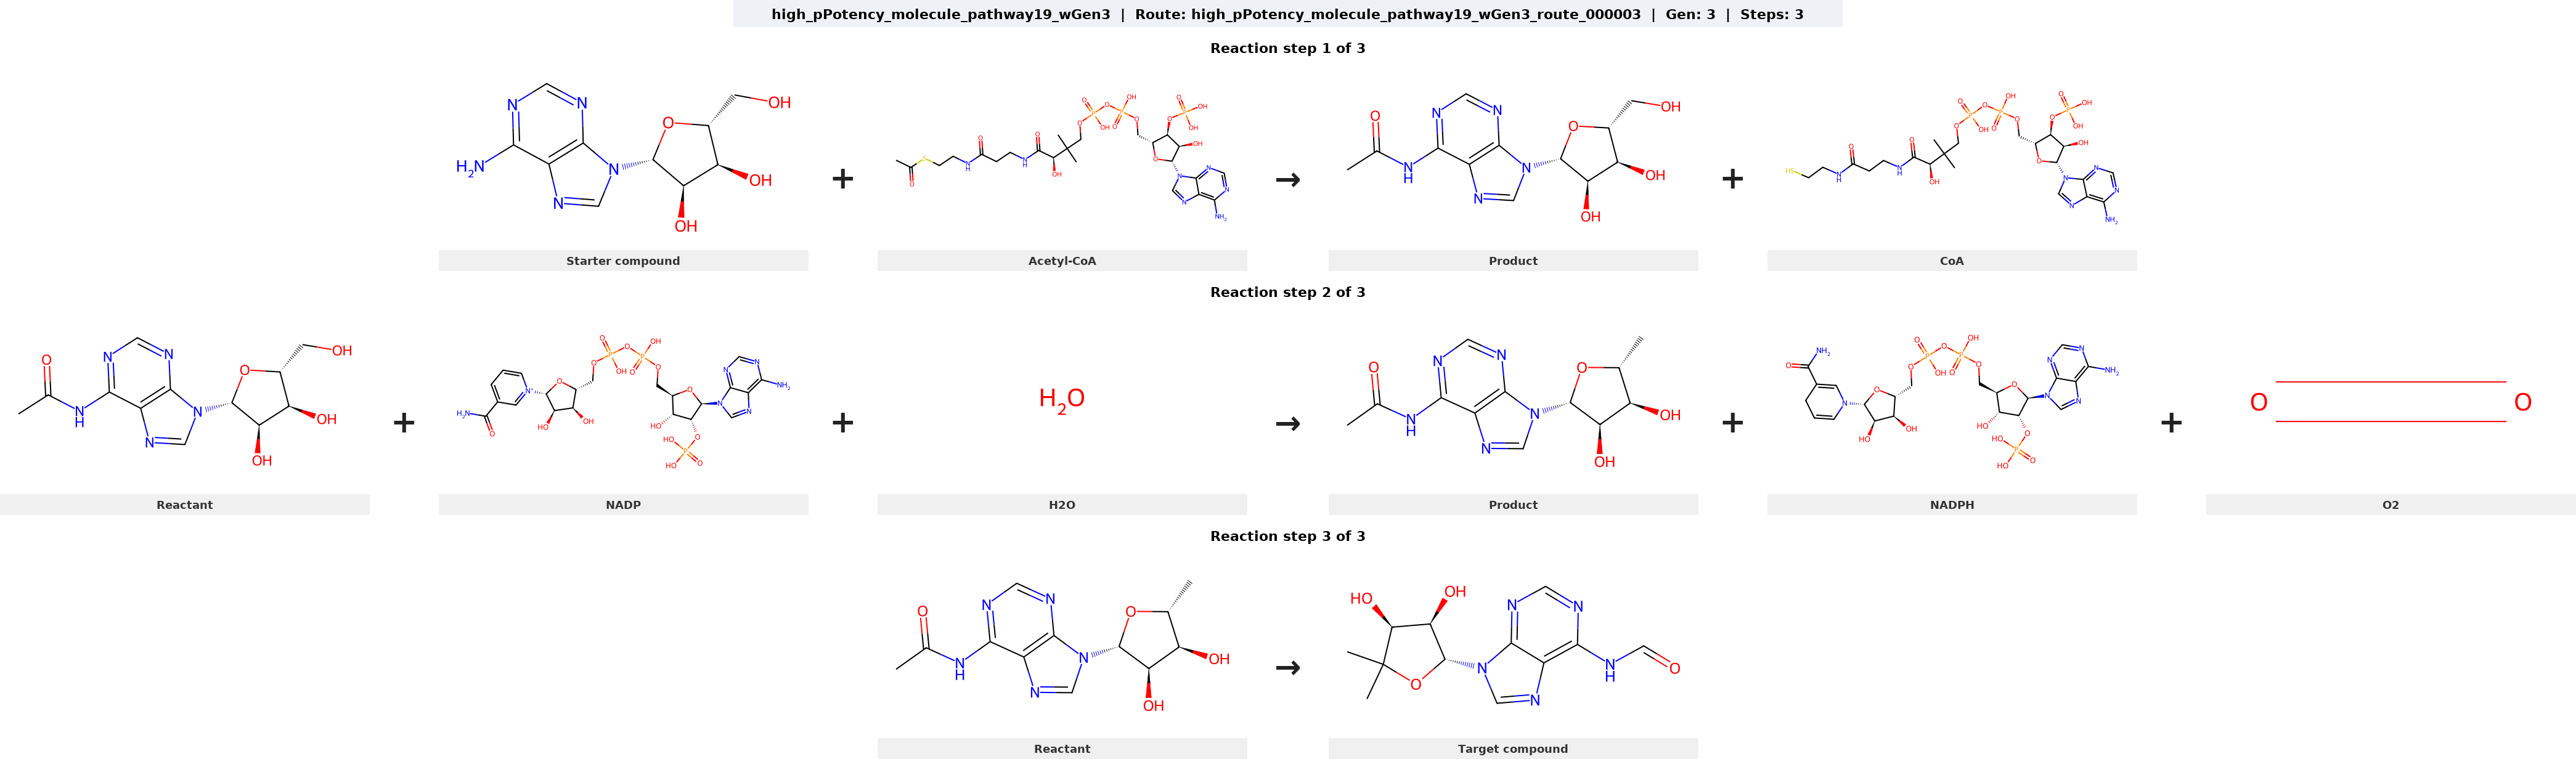

      saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathway_high_pPotency_molecule_pathway19_wGen3_route_000003_3step.png
      saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathway_high_pPotency_molecule_pathway19_wGen3_route_000003_3step.pdf

Done.


In [82]:
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
import os

# CONFIG
numToDisplay      = 4
selectedRoutes    = {}
subImgSize        = (600, 300)
cofactorTablePath = dataDir + "/DORAnet/all_cofactors.tsv"
outputDpi         = 1200
saveFigures       = True
DNADesignResultsDir = DNADesignResultsDir

# Optional display-name overrides, keyed by the Name in all_cofactors.tsv.
# Empty this out to show the table names verbatim (CO-A, OXYGEN-MOLECULE, ...).
cofactorDisplayOverride = {
    "CO-A": "CoA",
    "ACETYL-COA": "Acetyl-CoA",
    "OXYGEN-MOLECULE": "O2",
    "WATER": "H2O",
    "HYDROGEN-PEROXIDE": "H2O2",
    "CARBON-DIOXIDE": "CO2",
    "AMMONIA": "NH3",
    "S-ADENOSYLMETHIONINE": "SAM",
    "ADENOSYL-HOMO-CYS": "SAH",
    "2-KETOGLUTARATE": "2-Ketoglutarate",
    "GLT": "Glutamate",
    "PROTON": "H+",
}

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

separatorFont = loadFont(52)
labelFont     = loadFont(18)
headerFont    = loadFont(22)

def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

def cofactorKey(smi):
    """
    Canonical, stereo- and charge-insensitive key. Tolerates '*' wildcard atoms
    in the cofactor table (FAD, F420, quinones, formyl-THF).
    """
    mol = Chem.MolFromSmiles(str(smi), sanitize=False)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        pass
    try:
        return Chem.MolToSmiles(mol, isomericSmiles=False)
    except Exception:
        return None

def loadCofactorNames(path):
    """Map canonical SMILES key -> display name, sourced from all_cofactors.tsv."""
    nameByKey = {}
    if not os.path.exists(path):
        print(f"Cofactor table not found at {path}; cofactor names will not be applied.")
        return nameByKey
    table = pd.read_csv(path, sep="\t")
    for _, row in table.iterrows():
        key = cofactorKey(row["SMILES"])
        if key is None:
            continue
        rawName = str(row["Name"]).strip()
        nameByKey.setdefault(key, cofactorDisplayOverride.get(rawName, rawName))
    return nameByKey

cofactorNameByKey = loadCofactorNames(cofactorTablePath)

def cofactorNameFor(smi):
    return cofactorNameByKey.get(cofactorKey(smi))

def splitPathway(pathwayStr):
    return [] if pd.isna(pathwayStr) else [x.strip() for x in str(pathwayStr).split("||") if x.strip()]

def splitStarters(starterStr):
    return [] if pd.isna(starterStr) else [x.strip() for x in str(starterStr).split(";") if x.strip()]

def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")

def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)

def makeTextBanner(text, bannerWidth, bannerHeight=40, bgColor="white", font=None):
    img = Image.new("RGB", (bannerWidth, bannerHeight), bgColor)
    centeredText(ImageDraw.Draw(img), text, bannerWidth, (bannerHeight - 24) // 2, font or headerFont)
    return img

def stackPanelsVertically(panelList, gapSize=14, bgColor="white"):
    valid = [p for p in panelList if p is not None]
    if not valid:
        return None
    w = max(p.width for p in valid)
    h = sum(p.height for p in valid) + gapSize * (len(valid) - 1)
    canvas = Image.new("RGB", (w, h), bgColor)
    y = 0
    for p in valid:
        canvas.paste(p, ((w - p.width) // 2, y))
        y += p.height + gapSize
    return canvas

def saveImageHighRes(image, basePathNoExt, dpi):
    """Save one route image as PNG and PDF at the given dpi."""
    pngPath = basePathNoExt + ".png"
    pdfPath = basePathNoExt + ".pdf"
    image.save(pngPath, dpi=(dpi, dpi))
    image.save(pdfPath, "PDF", resolution=float(dpi))
    return pngPath, pdfPath

def reorderStepsForward(steps, canonStarterSet):
    if len(steps) <= 1:
        return steps
    parsed = []
    for smi in steps:
        if ">>" not in str(smi):
            continue
        rStr, pStr = str(smi).split(">>", 1)
        parsed.append({
            "smi"      : smi,
            "reactants": {canonicalizeSmiles(s.strip()) for s in rStr.split(".") if s.strip()},
            "products" : {canonicalizeSmiles(s.strip()) for s in pStr.split(".") if s.strip()},
        })
    if not parsed:
        return steps
    firstIdx = next((i for i, s in enumerate(parsed) if s["reactants"] & canonStarterSet), None)
    if firstIdx is None:
        return steps
    ordered   = [parsed[firstIdx]]
    remaining = [s for i, s in enumerate(parsed) if i != firstIdx]
    while remaining:
        prevProducts = ordered[-1]["products"]
        nextIdx = next((i for i, s in enumerate(remaining) if s["reactants"] & prevProducts), None)
        if nextIdx is None:
            ordered.extend(remaining)
            break
        ordered.append(remaining[nextIdx])
        remaining = [s for i, s in enumerate(remaining) if i != nextIdx]
    return [s["smi"] for s in ordered]

def getMolLabel(smi, canonStarterSet, canonTargetSmi, side="reactant"):
    canon = canonicalizeSmiles(smi)
    if canon in canonStarterSet:
        return "Starter compound"
    if canon == canonTargetSmi:
        return "Target compound"
    cofactorName = cofactorNameFor(smi)
    if cofactorName:
        return cofactorName
    return "Reactant" if side == "reactant" else "Product"

def makeLabeledMolImage(smi, label, subImageSize=(280, 210)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg      = rdkitImageToPil(Draw.MolToImage(mol, size=subImageSize))
    labelBanner = Image.new("RGB", (molImg.width, 34), "#f0f0f0")
    centeredText(ImageDraw.Draw(labelBanner), label, molImg.width, 7, labelFont, "#333333")
    combined = Image.new("RGB", (molImg.width, molImg.height + labelBanner.height), "white")
    combined.paste(molImg,      (0, 0))
    combined.paste(labelBanner, (0, molImg.height))
    return combined

def makeSeparatorImage(text, height, width=90):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bbox         = draw.textbbox((0, 0), text, font=separatorFont)
        textW, textH = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except Exception:
        textW, textH = 30, 50
    draw.text(((width - textW) // 2, (height - textH) // 2), text, fill="#222222", font=separatorFont)
    return img

def makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi,
                             panelTitle, subImageSize=(280, 210)):
    if ">>" not in str(rxnSmi):
        return None
    reactantStr, productStr = str(rxnSmi).split(">>", 1)
    reactantSmiles = (
        [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonicalizeSmiles(s) in canonStarterSet]
        + [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonicalizeSmiles(s) not in canonStarterSet]
    )
    productSmiles = (
        [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonicalizeSmiles(s) != canonTargetSmi]
        + [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonicalizeSmiles(s) == canonTargetSmi]
    )
    reactantImgs = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, side="reactant"), subImageSize)
        for s in reactantSmiles] if img is not None]
    productImgs  = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, side="product"), subImageSize)
        for s in productSmiles]  if img is not None]
    if not reactantImgs or not productImgs:
        return None
    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 16
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    canvas = Image.new("RGB", (totalW, maxH), "white")
    x = 0
    for part in parts:
        canvas.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap
    titleBanner = makeTextBanner(panelTitle, canvas.width, bannerHeight=38)
    final = Image.new("RGB", (canvas.width, canvas.height + titleBanner.height + 10), "white")
    final.paste(titleBanner, (0, 0))
    final.paste(canvas,      (0, titleBanner.height + 10))
    return final

def buildRouteImage(rowData, numSteps, subImageSize, bannerWidth):
    canonStarterSet = {canonicalizeSmiles(s) for s in splitStarters(rowData.get("starter_Canonical_SMILES", ""))}
    canonTargetSmi  = canonicalizeSmiles(rowData.get("targetSMILES", ""))
    forwardSteps    = reorderStepsForward(
        splitPathway(rowData.get("reconstructedPathwayString", np.nan)), canonStarterSet
    )
    panelBlocks = [makeTextBanner(
        f"{rowData['dirName']}  |  Route: {rowData['routeId']}  |  Gen: {rowData['generationRun']}  |  Steps: {numSteps}",
        bannerWidth=bannerWidth, bannerHeight=44, bgColor="#eef2f7",
    )]
    for stepIdx, rxnSmi in enumerate(forwardSteps, start=1):
        panel = makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi,
                                        panelTitle=f"Reaction step {stepIdx} of {numSteps}",
                                        subImageSize=subImageSize)
        if panel:
            panelBlocks.append(panel)
    return stackPanelsVertically(panelBlocks, gapSize=14, bgColor="white")

# Collapse step-level DF to route-level
routeLevelDF = (
    reconstructedPathwaysDF_OneCompound
    .groupby("routeId", as_index=False)
    .agg(
        dirName                    = ("dirName",                    "first"),
        jobName                    = ("jobName",                    "first"),
        generationRun              = ("generationRun",              "first"),
        numSteps                   = ("numSteps",                   "first"),
        starter_Canonical_SMILES   = ("starter_Canonical_SMILES",   "first"),
        targetSMILES               = ("targetSMILES",               "first"),
        reconstructedPathwayString = ("reconstructedPathwayString", "first"),
    )
    .sort_values(["numSteps", "routeId"])
    .reset_index(drop=True)
)

if saveFigures:
    os.makedirs(DNADesignResultsDir, exist_ok=True)

for numSteps, groupDF in routeLevelDF.groupby("numSteps"):
    availableRoutes = groupDF.reset_index(drop=True)
    indices         = selectedRoutes.get(numSteps, list(range(numToDisplay)))
    validIndices    = [i for i in indices if i < len(availableRoutes)]

    print(f"\n{numSteps}-step pathways: {len(availableRoutes):,} available, displaying {len(validIndices):,}")
    if not validIndices:
        print(f"  No valid indices for {numSteps}-step, check selectedRoutes config.")
        continue

    for rank, idx in enumerate(validIndices, start=1):
        rowData    = availableRoutes.loc[idx]
        routeImage = buildRouteImage(rowData, numSteps, subImgSize, bannerWidth=1800)
        if routeImage is not None:
            print(f"  [{rank}/{len(validIndices)}] Route: {rowData['routeId']}")
            display(routeImage)
            if saveFigures:
                basePath         = os.path.join(DNADesignResultsDir, f"pathway_{rowData['routeId']}_{numSteps}step")
                pngPath, pdfPath = saveImageHighRes(routeImage, basePath, outputDpi)
                print(f"      saved: {pngPath}")
                print(f"      saved: {pdfPath}")

print("\nDone.")

### Save reaction network


3-step pathways: 1 available, displaying 1
  [1/1] Route: high_pPotency_molecule_pathway7_wGen3_route_000001


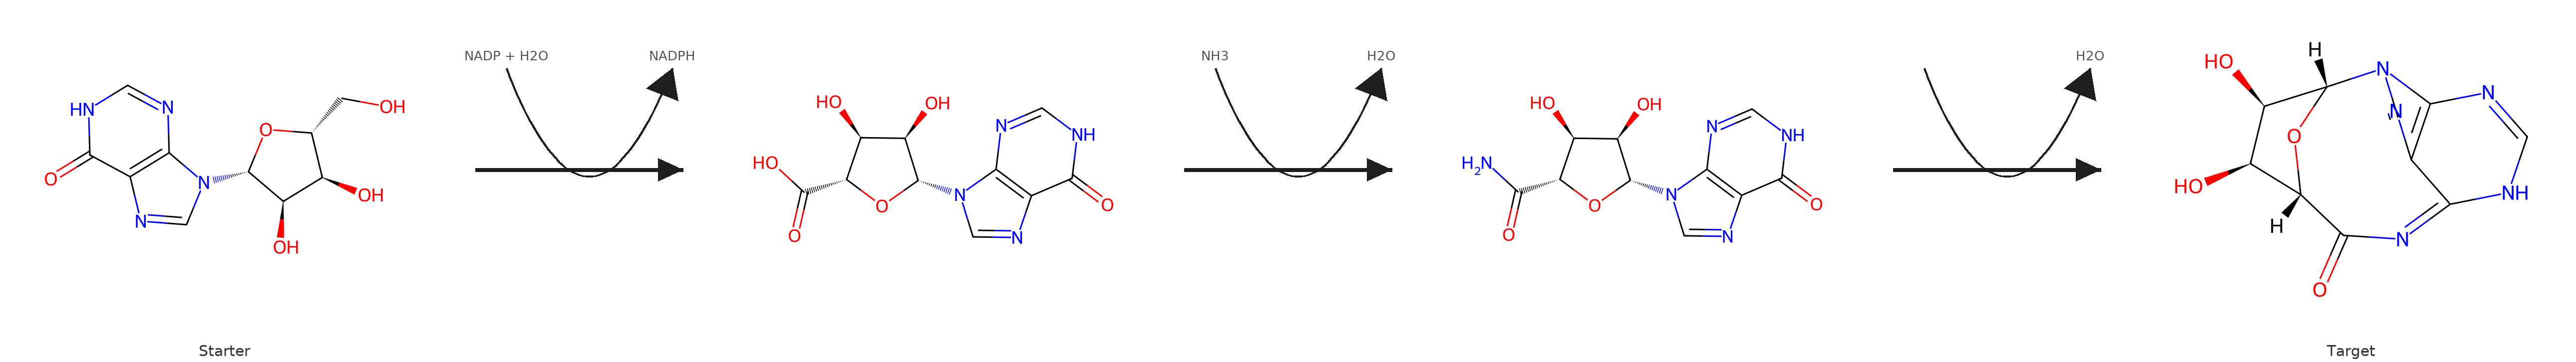

      saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathway_high_pPotency_molecule_pathway7_wGen3_route_000001_3step.png
      saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathway_high_pPotency_molecule_pathway7_wGen3_route_000001_3step.pdf

Done.


In [71]:
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdMolDescriptors
import os
import re
import math

# CONFIG
numToDisplay          = 4
selectedRoutes        = {}   # empty: every step-count group shows its first numToDisplay routes
layoutDirection       = "horizontal"
moleculeImageSizePx   = (900, 680)
arrowSpanPx           = 520
outputDpi             = 1200
showStarterTargetTags = True
showCofactorLabels    = True
saveFigures           = True
articleFiguresDir     = DNADesignResultsDir
rulesetPath           = dataDir + "/DORAnet/JN3604IMT_rules.tsv"
cofactorTablePath     = dataDir + "/DORAnet/all_cofactors.tsv"
maxCofactorHeavyAtoms = 12   # unknown species larger than this are treated as co-products, not cofactors

# Optional display-name overrides, keyed by the Name in all_cofactors.tsv.
# Leave empty to show the table names verbatim (CO-A, OXYGEN-MOLECULE, ...).
cofactorDisplayOverride = {
    "CO-A": "CoA",
    "ACETYL-COA": "Acetyl-CoA",
    "OXYGEN-MOLECULE": "O2",
    "WATER": "H2O",
    "HYDROGEN-PEROXIDE": "H2O2",
    "CARBON-DIOXIDE": "CO2",
    "AMMONIA": "NH3",
    "S-ADENOSYLMETHIONINE": "SAM",
    "ADENOSYL-HOMO-CYS": "SAH",
    "2-KETOGLUTARATE": "2-Ketoglutarate",
    "GLT": "Glutamate",
    "PROTON": "H+",
}

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSans.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

captionFont  = loadFont(30)
cofactorFont = loadFont(26)

def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

def cofactorKey(smi):
    """
    Canonical, stereo- and charge-insensitive key. Tolerates '*' wildcard atoms
    in the cofactor table (FAD, F420, quinones, formyl-THF).
    """
    mol = Chem.MolFromSmiles(str(smi), sanitize=False)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        pass
    try:
        return Chem.MolToSmiles(mol, isomericSmiles=False)
    except Exception:
        return None

def loadCofactorNames(path):
    """Map canonical SMILES key -> display name, sourced from all_cofactors.tsv."""
    nameByKey = {}
    if not os.path.exists(path):
        print(f"Cofactor table not found at {path}; cofactors will fall back to formulas.")
        return nameByKey
    table = pd.read_csv(path, sep="\t")
    for _, row in table.iterrows():
        key = cofactorKey(row["SMILES"])
        if key is None:
            continue
        rawName = str(row["Name"]).strip()
        nameByKey.setdefault(key, cofactorDisplayOverride.get(rawName, rawName))
    return nameByKey

cofactorNameByKey = loadCofactorNames(cofactorTablePath)

def isKnownCofactor(smi):
    return cofactorKey(smi) in cofactorNameByKey

def labelSpecies(smi):
    key = cofactorKey(smi)
    if key in cofactorNameByKey:
        return cofactorNameByKey[key]
    mol = Chem.MolFromSmiles(str(smi))
    return rdMolDescriptors.CalcMolFormula(mol) if mol else str(smi)

# Rule-level role tokens, used only when a reaction carries no explicit cofactor molecule.
cofactorTokenNameMap = {
    "WATER": "H2O", "HYDROGEN_PEROXIDE": "H2O2", "OXYGEN": "O2", "O2": "O2",
    "CARBON_DIOXIDE": "CO2", "AMMONIA": "NH3", "AMMONIUM": "NH4+",
    "NAD": "NAD+", "NAD_PLUS": "NAD+", "NADH": "NADH",
    "NADP": "NADP+", "NADP_PLUS": "NADP+", "NADPH": "NADPH",
    "L_GLUTAMATE": "Glutamate", "GLUTAMATE": "Glutamate",
    "2_KETOGLUTARATE": "2-Ketoglutarate", "2_OXOGLUTARATE": "2-Oxoglutarate",
    "METHYL_DONOR_COF": "SAM", "METHYL_ACCEPTOR_COF": "SAH",
    "ATP": "ATP", "ADP": "ADP", "AMP": "AMP",
    "PHOSPHATE": "Pi", "DIPHOSPHATE": "PPi", "COA": "CoA", "ACETYL_COA": "Acetyl-CoA",
}
primaryRoleTokens = {"ANY", "ANY_COF", ""}

def heavyAtomCount(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return mol.GetNumHeavyAtoms() if mol else 0

def splitStarters(starterStr):
    return [] if pd.isna(starterStr) else [x.strip() for x in str(starterStr).split(";") if x.strip()]

def dedupeByCanon(smilesList):
    seen, kept = set(), []
    for s in smilesList:
        if not s:
            continue
        c = canonicalizeSmiles(s)
        if c not in seen:
            seen.add(c)
            kept.append(s)
    return kept

def dedupePreserveOrder(items):
    seen, kept = set(), []
    for x in items:
        if x and x not in seen:
            seen.add(x)
            kept.append(x)
    return kept

def cleanRoleToken(token):
    key = token.strip().upper().replace("-", "_").replace(" ", "_")
    if key in cofactorTokenNameMap:
        return cofactorTokenNameMap[key]
    return token.strip().replace("_", " ").title()

def extractRuleCofactors(cellValue):
    tokens = [t.strip() for t in re.split(r"[;,]", str(cellValue)) if t.strip()]
    labels = [cleanRoleToken(t) for t in tokens if t.strip().upper() not in primaryRoleTokens]
    return dedupePreserveOrder(labels)

def buildRuleCofactorMap(path):
    ruleMap = {}
    if not os.path.exists(path):
        print(f"  ruleset not found at {path}, using reaction-level cofactors only.")
        return ruleMap
    ruleset = pd.read_csv(path, sep="\t")
    nameCol = "Name" if "Name" in ruleset.columns else ruleset.columns[0]
    hasReact, hasProd = "Reactants" in ruleset.columns, "Products" in ruleset.columns
    for _, row in ruleset.iterrows():
        name = str(row.get(nameCol, "")).strip()
        if not name:
            continue
        entry = {
            "consumed": extractRuleCofactors(row["Reactants"]) if hasReact else [],
            "produced": extractRuleCofactors(row["Products"]) if hasProd else [],
        }
        ruleMap.setdefault(name, entry)
        ruleMap.setdefault(name.split("_")[0], entry)
    return ruleMap

def ruleCofactorsForStep(ruleName, ruleCofactorMap):
    name = str(ruleName).strip()
    entry = ruleCofactorMap.get(name) or ruleCofactorMap.get(name.split("_")[0])
    return (entry["consumed"], entry["produced"]) if entry else ([], [])

def parseReactionSides(reactionSmiles):
    if ">>" not in str(reactionSmiles):
        return [], []
    rStr, pStr = str(reactionSmiles).split(">>", 1)
    return (
        [s.strip() for s in rStr.split(".") if s.strip()],
        [s.strip() for s in pStr.split(".") if s.strip()],
    )

def reorderStepDictsForward(stepDicts, canonStarterSet):
    if len(stepDicts) <= 1:
        return stepDicts
    enriched = []
    for sd in stepDicts:
        reactants, products = parseReactionSides(sd["reactionSmiles"])
        if not reactants and not products:
            continue
        enriched.append({
            **sd,
            "reactantSet": {canonicalizeSmiles(s) for s in reactants},
            "productSet" : {canonicalizeSmiles(s) for s in products},
        })
    if not enriched:
        return stepDicts
    firstIdx = next((i for i, s in enumerate(enriched) if s["reactantSet"] & canonStarterSet), None)
    if firstIdx is None:
        return stepDicts
    ordered   = [enriched[firstIdx]]
    remaining = [s for i, s in enumerate(enriched) if i != firstIdx]
    while remaining:
        prevProducts = ordered[-1]["productSet"]
        nextIdx = next((i for i, s in enumerate(remaining) if s["reactantSet"] & prevProducts), None)
        if nextIdx is None:
            ordered.extend(remaining)
            break
        ordered.append(remaining[nextIdx])
        remaining = [s for i, s in enumerate(remaining) if i != nextIdx]
    return ordered

def pickCarrier(products, prevCarrierCanon, canonTargetSmi, nextReactants):
    # never let a known cofactor become a backbone node
    pool = [p for p in products if canonicalizeSmiles(p) != prevCarrierCanon and not isKnownCofactor(p)]
    if not pool:
        pool = [p for p in products if canonicalizeSmiles(p) != prevCarrierCanon] or products
    carrier = next((p for p in pool if canonicalizeSmiles(p) == canonTargetSmi), None)
    if carrier is None and nextReactants is not None:
        nextCanon = {canonicalizeSmiles(s) for s in nextReactants}
        feeding = [p for p in pool if canonicalizeSmiles(p) in nextCanon]
        if feeding:
            carrier = max(feeding, key=heavyAtomCount)
    if carrier is None:
        carrier = max(pool, key=heavyAtomCount)
    return carrier

def resolveCofactorLabels(step, reactants, products, prevCarrierCanon, carrierCanon, ruleCofactorMap):
    def keepAsCofactor(smi):
        return isKnownCofactor(smi) or heavyAtomCount(smi) <= maxCofactorHeavyAtoms

    consumedSpecies = [s for s in dedupeByCanon([r for r in reactants if canonicalizeSmiles(r) != prevCarrierCanon]) if keepAsCofactor(s)]
    producedSpecies = [s for s in dedupeByCanon([p for p in products  if canonicalizeSmiles(p) != carrierCanon])   if keepAsCofactor(s)]
    consumedLabels = [labelSpecies(s) for s in consumedSpecies]
    producedLabels = [labelSpecies(s) for s in producedSpecies]

    ruleConsumed, ruleProduced = ruleCofactorsForStep(step.get("ruleName", ""), ruleCofactorMap)
    if not consumedLabels and not producedLabels and (ruleConsumed or ruleProduced):
        consumedLabels, producedLabels = ruleConsumed, ruleProduced

    return dedupePreserveOrder(consumedLabels), dedupePreserveOrder(producedLabels)

def buildBackbone(stepDicts, canonStarterSet, canonTargetSmi, ruleCofactorMap):
    steps = []
    for sd in stepDicts:
        reactants, products = parseReactionSides(sd["reactionSmiles"])
        if not reactants or not products:
            continue
        steps.append({**sd, "reactants": reactants, "products": products})
    if not steps:
        return [], []

    firstReactants = steps[0]["reactants"]
    startCarrier = next((s for s in firstReactants if canonicalizeSmiles(s) in canonStarterSet), None)
    if startCarrier is None:
        nonCofactorFirst = [s for s in firstReactants if not isKnownCofactor(s)] or firstReactants
        startCarrier = max(nonCofactorFirst, key=heavyAtomCount)
    nodes            = [startCarrier]
    edges            = []
    prevCarrierCanon = canonicalizeSmiles(startCarrier)

    for stepIdx, step in enumerate(steps):
        reactants, products = step["reactants"], step["products"]
        nextReactants = steps[stepIdx + 1]["reactants"] if stepIdx + 1 < len(steps) else None
        carrier      = pickCarrier(products, prevCarrierCanon, canonTargetSmi, nextReactants)
        carrierCanon = canonicalizeSmiles(carrier)
        consumedLabels, producedLabels = resolveCofactorLabels(
            step, reactants, products, prevCarrierCanon, carrierCanon, ruleCofactorMap
        )
        nodes.append(carrier)
        edges.append({"consumed": consumedLabels, "produced": producedLabels})
        prevCarrierCanon = carrierCanon
    return nodes, edges

def drawMoleculeCairo(smi, sizePx):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    AllChem.Compute2DCoords(mol)
    drawer = rdMolDraw2D.MolDraw2DCairo(sizePx[0], sizePx[1])
    opts = drawer.drawOptions()
    opts.bondLineWidth   = 3
    opts.padding         = 0.10
    opts.clearBackground = True
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return Image.open(BytesIO(drawer.GetDrawingText())).convert("RGB")

def textWidth(draw, text, font):
    try:
        bbox = draw.textbbox((0, 0), text, font=font)
        return bbox[2] - bbox[0]
    except Exception:
        return len(text) * 12

def centeredTextX(draw, text, boxWidth, y, font, color="#333333"):
    draw.text(((boxWidth - textWidth(draw, text, font)) // 2, y), text, fill=color, font=font)

def makeCaptionBanner(text, width, height=46):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    centeredTextX(draw, text, width, (height - 34) // 2, captionFont)
    return img

def makeMoleculePanel(smi, caption, imageSizePx):
    molImg = drawMoleculeCairo(smi, imageSizePx)
    if molImg is None:
        return None
    if not caption:
        return molImg
    banner = makeCaptionBanner(caption, molImg.width)
    panel  = Image.new("RGB", (molImg.width, molImg.height + banner.height), "white")
    panel.paste(molImg, (0, 0))
    panel.paste(banner, (0, molImg.height))
    return panel

def joinLabels(labelList):
    return " + ".join([l for l in labelList if l])

def putLabelCentered(draw, text, centerX, y, font, panelWidth, color="#555555"):
    tw = textWidth(draw, text, font)
    x  = int(centerX - tw / 2)
    x  = max(4, min(x, panelWidth - tw - 4))
    draw.text((x, y), text, fill=color, font=font)

def makeHorizontalArrow(width, height, consumedText, producedText, color=(30, 30, 30), lineWidth=8):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    cy    = height // 2
    left  = int(width * 0.10)
    right = int(width * 0.90)

    # main straight reaction arrow (left to right)
    draw.line([(left, cy), (right, cy)], fill=color, width=lineWidth)
    head = int(min(width, height) * 0.045)
    draw.polygon(
        [(right - int(head * 2.2), cy - head), (right - int(head * 2.2), cy + head), (right, cy)],
        fill=color,
    )

    if not showCofactorLabels or (not consumedText and not producedText):
        return img

    # curved feeder: reactant enters at the left (tail) end, curve dips down to the
    # main arrow, product leaves at the right (arrowhead) end. Drawn as a quadratic
    # bezier so the endpoints sit under the two labels and the head follows the tangent.
    span  = right - left
    xL    = int(left + 0.15 * span)     # tail end, under the consumed label
    xR    = int(right - 0.05 * span)    # head end, under the produced label
    yTop  = cy - int(0.30 * height)     # both ends sit above the main arrow
    p0    = (xL, yTop)
    ctrl  = ((xL + xR) / 2.0, cy + 0.34 * height)   # control below pulls the curve down to the arrow
    p1    = (xR, yTop)

    thin = max(3, lineWidth // 2)
    pts  = []
    steps = 48
    for i in range(steps + 1):
        t  = i / steps
        mt = 1.0 - t
        x  = mt * mt * p0[0] + 2 * mt * t * ctrl[0] + t * t * p1[0]
        y  = mt * mt * p0[1] + 2 * mt * t * ctrl[1] + t * t * p1[1]
        pts.append((x, y))
    draw.line(pts, fill=color, width=thin, joint="curve")

    # arrowhead at the product (right) end, oriented along the curve tangent ctrl -> p1
    dx, dy = p1[0] - ctrl[0], p1[1] - ctrl[1]
    norm   = math.hypot(dx, dy) or 1.0
    ux, uy = dx / norm, dy / norm
    px, py = -uy, ux
    ah     = int(height * 0.05)
    tip    = p1
    base   = (p1[0] - ux * ah * 1.7, p1[1] - uy * ah * 1.7)
    draw.polygon([
        tip,
        (base[0] + px * ah, base[1] + py * ah),
        (base[0] - px * ah, base[1] - py * ah),
    ], fill=color)

    # labels above each end: consumed at the tail (left), produced at the head (right)
    labelY = yTop - 40
    if consumedText:
        putLabelCentered(draw, consumedText, xL, labelY, cofactorFont, width)
    if producedText:
        putLabelCentered(draw, producedText, xR, labelY, cofactorFont, width)
    return img

def makeVerticalArrow(width, height, consumedText, producedText, color=(30, 30, 30), lineWidth=8):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    cx     = width // 2
    top    = int(height * 0.14)
    bottom = int(height * 0.86)
    draw.line([(cx, top), (cx, bottom)], fill=color, width=lineWidth)
    head = int(min(width, height) * 0.10)
    draw.polygon(
        [(cx - head, bottom - int(head * 1.6)), (cx + head, bottom - int(head * 1.6)), (cx, bottom)],
        fill=color,
    )
    midY = (top + bottom) // 2
    if showCofactorLabels and consumedText:
        draw.text((cx + 18, midY - 40), consumedText, fill="#555555", font=cofactorFont)
    if showCofactorLabels and producedText:
        draw.text((cx + 18, midY + 8), producedText, fill="#555555", font=cofactorFont)
    return img

def stackPanelsHorizontally(parts, bgColor="white"):
    valid = [p for p in parts if p is not None]
    if not valid:
        return None
    w = sum(p.width for p in valid)
    h = max(p.height for p in valid)
    canvas = Image.new("RGB", (w, h), bgColor)
    x = 0
    for p in valid:
        canvas.paste(p, (x, 0))
        x += p.width
    return canvas

def stackPanelsVertically(parts, bgColor="white"):
    valid = [p for p in parts if p is not None]
    if not valid:
        return None
    w = max(p.width for p in valid)
    h = sum(p.height for p in valid)
    canvas = Image.new("RGB", (w, h), bgColor)
    y = 0
    for p in valid:
        canvas.paste(p, ((w - p.width) // 2, y))
        y += p.height
    return canvas

def buildCascadeImage(rowData, imageSizePx, arrowSpanPx, direction, ruleCofactorMap):
    canonStarterSet = {canonicalizeSmiles(s) for s in splitStarters(rowData.get("starter_Canonical_SMILES", ""))}
    canonTargetSmi  = canonicalizeSmiles(rowData.get("targetSMILES", ""))
    orderedSteps    = reorderStepDictsForward(rowData["stepDicts"], canonStarterSet)
    nodes, edges    = buildBackbone(orderedSteps, canonStarterSet, canonTargetSmi, ruleCofactorMap)
    if len(nodes) < 2:
        return None

    parts   = []
    lastIdx = len(nodes) - 1
    for idx, smi in enumerate(nodes):
        caption = ""
        if showStarterTargetTags and idx == 0:
            caption = "Starter"
        elif showStarterTargetTags and idx == lastIdx:
            caption = "Target"
        parts.append(makeMoleculePanel(smi, caption, imageSizePx))
        if idx != lastIdx:
            edge         = edges[idx]
            consumedText = joinLabels(edge["consumed"])
            producedText = joinLabels(edge["produced"])
            if direction == "horizontal":
                parts.append(makeHorizontalArrow(arrowSpanPx, imageSizePx[1], consumedText, producedText))
            else:
                parts.append(makeVerticalArrow(imageSizePx[0], arrowSpanPx, consumedText, producedText))

    return stackPanelsHorizontally(parts) if direction == "horizontal" else stackPanelsVertically(parts)

def saveImageHighRes(image, basePathNoExt, dpi):
    pngPath = basePathNoExt + ".png"
    pdfPath = basePathNoExt + ".pdf"
    image.save(pngPath, dpi=(dpi, dpi))
    image.save(pdfPath, "PDF", resolution=float(dpi))
    return pngPath, pdfPath

ruleCofactorMap = buildRuleCofactorMap(rulesetPath)

if saveFigures:
    os.makedirs(articleFiguresDir, exist_ok=True)

routeRecords = []
for routeId, g in (
    reconstructedPathwaysDF_OneCompound
    .sort_values(["numSteps", "routeId", "step"])
    .groupby("routeId", sort=False)
):
    first     = g.iloc[0].to_dict()
    stepDicts = []
    for _, r in g.iterrows():
        rd = r.to_dict()
        stepDicts.append({
            "reactionSmiles": str(rd.get("simplifiedReactionSMILES") or rd.get("reactionSMILES") or ""),
            "ruleName"      : rd.get("ruleName", ""),
        })
    routeRecords.append({
        "routeId"                  : routeId,
        "dirName"                  : first.get("dirName", ""),
        "generationRun"            : first.get("generationRun", ""),
        "numSteps"                 : int(first.get("numSteps", len(stepDicts))),
        "starter_Canonical_SMILES" : first.get("starter_Canonical_SMILES", ""),
        "targetSMILES"             : first.get("targetSMILES", ""),
        "stepDicts"                : stepDicts,
    })

routeLevelDF = (
    pd.DataFrame(routeRecords)
    .sort_values(["numSteps", "routeId"])
    .reset_index(drop=True)
)

for numSteps, groupDF in routeLevelDF.groupby("numSteps"):
    availableRoutes = groupDF.reset_index(drop=True)
    indices         = selectedRoutes.get(numSteps, list(range(numToDisplay)))
    validIndices    = [i for i in indices if i < len(availableRoutes)]

    print(f"\n{numSteps}-step pathways: {len(availableRoutes):,} available, displaying {len(validIndices):,}")
    if not validIndices:
        print(f"  No valid indices for {numSteps}-step, check selectedRoutes config.")
        continue

    for rank, idx in enumerate(validIndices, start=1):
        rowData      = availableRoutes.loc[idx]
        cascadeImage = buildCascadeImage(rowData, moleculeImageSizePx, arrowSpanPx, layoutDirection, ruleCofactorMap)
        if cascadeImage is None:
            print(f"  [{rank}/{len(validIndices)}] Route: {rowData['routeId']} skipped, no drawable chain.")
            continue
        print(f"  [{rank}/{len(validIndices)}] Route: {rowData['routeId']}")
        display(cascadeImage)
        if saveFigures:
            basePath         = os.path.join(articleFiguresDir, f"pathway_{rowData['routeId']}_{numSteps}step")
            pngPath, pdfPath = saveImageHighRes(cascadeImage, basePath, outputDpi)
            print(f"      saved: {pngPath}")
            print(f"      saved: {pdfPath}")

print("\nDone.")

### `Thermodynamic` feasibility check

### Keep only `enzymatic` DORAnet reactions

In [111]:
enzymaticReactionDF = reconstructedPathwaysDF_OneCompound[
    reconstructedPathwaysDF_OneCompound["reactionType"].astype(str).str.lower().str.contains(
        "enzyme|enzymatic|bio|biological",
        na=False
    )
].copy()

print(f"Total reactions: {len(reconstructedPathwaysDF_OneCompound):,}")
print(f"Likely enzymatic reactions: {len(enzymaticReactionDF):,}")

enzymaticReactionDF.head()

Total reactions: 219
Likely enzymatic reactions: 219


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,rawNetworkReactionString,networkMatchStatus,numReactantMolecules,numProductMolecules,starterInReactants,targetInProducts,isReconstructedPathwayStep,routeStepId,fullReconstructedPathwayString,starter_Canonical_SMILES
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,1,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,matched_by_reaction_and_rule,1,2,False,True,True,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,1,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,matched_by_reaction_and_rule,3,3,False,False,True,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,1,...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,True,False,True,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,matched_by_reaction_and_rule,1,2,False,True,True,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,matched_by_reaction_and_rule,2,2,False,False,True,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O


## 2. Use `DORA-XGB` to get feasibility score

In [112]:
reactionDF_DORAXGB = enzymaticReactionDF.copy()
#reactionDF_DORAXGB = enzymaticReactionDF.head(50).copy()

# Clean reaction string for model input
reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

def getFeasibilityScoresAndLabels(rxnStr):
    return pd.Series({
        "feasibilityScore_rule1": by_desc_MW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule1": by_desc_MW_model.predict_label(rxnStr),

        "feasibilityScore_rule2": by_asc_MW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule2": by_asc_MW_model.predict_label(rxnStr),

        "feasibilityScore_rule3": add_concat_model.predict_proba(rxnStr),
        "feasibilityLabel_rule3": add_concat_model.predict_label(rxnStr),

        "feasibilityScore_rule4": add_subtract_model.predict_proba(rxnStr),
        "feasibilityLabel_rule4": add_subtract_model.predict_label(rxnStr),
    })


reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

reactionDF_DORAXGB[
    [
        "feasibilityScore_rule1",
        "feasibilityLabel_rule1",
        "feasibilityScore_rule2",
        "feasibilityLabel_rule2",
        "feasibilityScore_rule3",
        "feasibilityLabel_rule3",
        "feasibilityScore_rule4",
        "feasibilityLabel_rule4",
    ]
] = reactionDF_DORAXGB["rxn_str"].apply(getFeasibilityScoresAndLabels)

reactionDF_DORAXGB

,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,starter_Canonical_SMILES,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,1,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,0.006222,0.0,0.003048,0.0,0.000110,0.0,0.000184,0.0
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,1,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,0.284756,0.0,0.949984,1.0,0.257415,0.0,0.740460,1.0
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,1,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.984775,1.0,0.994126,1.0,0.478300,0.0,0.100229,0.0
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,0.006222,0.0,0.003048,0.0,0.000110,0.0,0.000184,0.0
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,0.754286,1.0,0.489343,0.0,0.739067,1.0,0.841001,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,72,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.984775,1.0,0.994126,1.0,0.478300,0.0,0.100229,0.0
215,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...

### Use a custom cutoff

### Keep only `high feasible` reactions

In [113]:
# Choose which feasibility label to use
feasibilityLabel = "feasibilityLabel_rule3"   # <- change to rule2/rule3/rule4 as needed (Yash's paper says rule3 is the best one)
targetValue = 1                               # <- change if you want a different label value

# Optional safety check
validLabels = [
    "feasibilityLabel_rule1",
    "feasibilityLabel_rule2",
    "feasibilityLabel_rule3",
    "feasibilityLabel_rule4",
]
if feasibilityLabel not in validLabels:
    raise ValueError(f"Invalid feasibilityLabel: {feasibilityLabel}. Choose from {validLabels}")

if feasibilityLabel not in reactionDF_DORAXGB.columns:
    raise KeyError(f"Column '{feasibilityLabel}' not found in reactionDF_DORAXGB")

reactionDF_DORAXGB_highFeasibility = (
    reactionDF_DORAXGB[
        (reactionDF_DORAXGB[feasibilityLabel] == targetValue)
        & (reactionDF_DORAXGB[feasibilityLabel].notna())
    ]
    .sort_values(by=feasibilityLabel, ascending=False)
    .reset_index(drop=True)
)

uniqueReactantStrings_high = set(reactionDF_DORAXGB_highFeasibility["reactants"])
uniqueProductStrings_high = set(reactionDF_DORAXGB_highFeasibility["products"])

uniqueReactantMolecules_high = {
    mol.strip()
    for reactants in reactionDF_DORAXGB_highFeasibility["reactants"]
    for mol in str(reactants).split(".")
    if mol.strip()
}

uniqueProductMolecules_high = {
    mol.strip()
    for products in reactionDF_DORAXGB_highFeasibility["products"]
    for mol in str(products).split(".")
    if mol.strip()
}

print(f"Feasibility label used: {feasibilityLabel} == {targetValue}")
print(f"Number of total reactions: {len(reactionDF_DORAXGB)}")
print(f"Number of high-feasibility reactions: {len(reactionDF_DORAXGB_highFeasibility)}")
print(f"Number of unique reactant strings: {len(uniqueReactantStrings_high)}")
print(f"Number of unique product strings: {len(uniqueProductStrings_high)}")
print(f"Number of unique individual reactant molecules: {len(uniqueReactantMolecules_high)}")
print(f"Number of unique individual product molecules: {len(uniqueProductMolecules_high)}")

reactionDF_DORAXGB_highFeasibility.to_csv(os.path.join(DNADesignResultsDir, f"DORAXGB_highFeasibility_{feasibilityLabel}.csv"),index=False)
reactionDF_DORAXGB_highFeasibility

Feasibility label used: feasibilityLabel_rule3 == 1
Number of total reactions: 219
Number of high-feasibility reactions: 48
Number of unique reactant strings: 4
Number of unique product strings: 4
Number of unique individual reactant molecules: 6
Number of unique individual product molecules: 5


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,starter_Canonical_SMILES,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,0.754286,1.0,0.489343,0.0,0.739067,1.0,0.841001,1.0
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1...,0.972314,1.0,0.961246,1.0,0.820338,1.0,0.919379,1.0
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0
5,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,16,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,0.754286,1.0,0.489343,0.0,0.739067,1.0,0.841001,1.0
6,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,17,...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(


Starter: Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/doraxgb_feasibility.png
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/doraxgb_feasibility.pdf


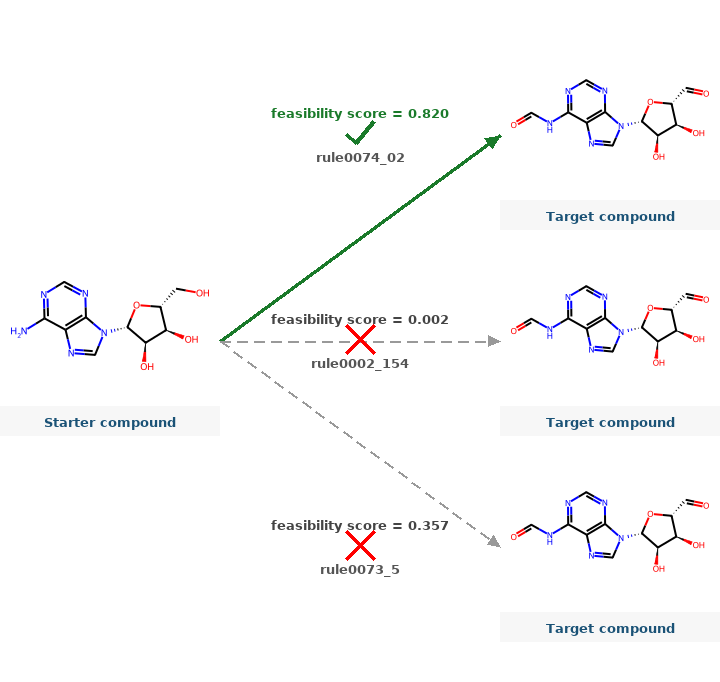

In [114]:
import math
from PIL import Image, ImageDraw, ImageFont
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# CONFIG
maxFeasible       = 2
maxNotFeasible    = 2
subImgSize        = (220, 160)
arrowZoneWidth    = 280
labelHeight       = 30
verticalGap       = 16
feasibleColor     = "#1a7a2a"
notFeasibleColor  = "#cc2222"

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

fontMedium = loadFont(15)
fontSmall  = loadFont(13)

def rdkitToPil(smi, size):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    return Draw.MolToImage(mol, size=size).convert("RGB")

def centeredText(draw, text, cx, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text((cx - textW // 2, y), text, fill=color, font=font)

def drawSolidArrow(draw, x1, y1, x2, y2, color="#1a7a2a", width=3, headSize=14):
    draw.line([(x1, y1), (x2, y2)], fill=color, width=width)
    dx, dy  = x2 - x1, y2 - y1
    dist    = math.sqrt(dx*dx + dy*dy)
    if dist == 0:
        return
    ux, uy  = dx/dist, dy/dist
    px, py  = -uy, ux
    draw.polygon([
        (x2, y2),
        (x2 - ux*headSize + px*headSize*0.45, y2 - uy*headSize + py*headSize*0.45),
        (x2 - ux*headSize - px*headSize*0.45, y2 - uy*headSize - py*headSize*0.45),
    ], fill=color)

def drawDashedArrow(draw, x1, y1, x2, y2, color="#888888", width=2, headSize=12, dashLen=10, gapLen=7):
    dx, dy   = x2 - x1, y2 - y1
    dist     = math.sqrt(dx*dx + dy*dy)
    if dist == 0:
        return
    ux, uy   = dx/dist, dy/dist
    pos, on  = 0, True
    while pos < dist - headSize:
        if on:
            xS = x1 + ux * pos
            yS = y1 + uy * pos
            xE = x1 + ux * min(pos + dashLen, dist - headSize)
            yE = y1 + uy * min(pos + dashLen, dist - headSize)
            draw.line([(xS, yS), (xE, yE)], fill=color, width=width)
            pos += dashLen
        else:
            pos += gapLen
        on = not on
    px, py = -uy, ux
    draw.polygon([
        (x2, y2),
        (x2 - ux*headSize + px*headSize*0.45, y2 - uy*headSize + py*headSize*0.45),
        (x2 - ux*headSize - px*headSize*0.45, y2 - uy*headSize - py*headSize*0.45),
    ], fill=color)

def drawGreenTick(draw, cx, cy, size=14, color="#1a7a2a"):
    draw.line([(cx - size, cy + size * 0.1), (cx - size * 0.25, cy + size * 0.75)], fill=color, width=4)
    draw.line([(cx - size * 0.25, cy + size * 0.75), (cx + size, cy - size * 0.8)], fill=color, width=4)

def drawRedX(draw, cx, cy, size=14):
    draw.line([(cx-size, cy-size), (cx+size, cy+size)], fill="red", width=3)
    draw.line([(cx+size, cy-size), (cx-size, cy+size)], fill="red", width=3)

def makeMolCard(smi, label, labelColor="#333333", size=(220, 160), lh=30):
    molImg = rdkitToPil(smi, size)
    if molImg is None:
        return None
    banner = Image.new("RGB", (molImg.width, lh), "#f7f7f7")
    centeredText(ImageDraw.Draw(banner), label, molImg.width // 2, (lh - 14) // 2, fontSmall, labelColor)
    combined = Image.new("RGB", (molImg.width, molImg.height + lh), "white")
    combined.paste(molImg, (0, 0))
    combined.paste(banner, (0, molImg.height))
    return combined


def plotFeasibilityComparison(starterSmi, targetSmi, allReactionDF,
                               feasibilityLabelCol="feasibilityLabel_rule3",
                               feasibilityScoreCol="feasibilityScore_rule3",
                               maxFeasible=2, maxNotFeasible=2,
                               subImageSize=(220, 160),
                               saveDir=None, saveName=None):

    canon = canonicalizeSmiles(starterSmi)

    allRxns = allReactionDF[
        allReactionDF["reactants"].apply(
            lambda r: canon in {canonicalizeSmiles(s) for s in splitMoleculeString(r)}
        )
    ].copy()

    if allRxns.empty:
        print(f"No reactions found for: {starterSmi[:60]}")
        return

    if feasibilityLabelCol not in allRxns.columns:
        raise KeyError(f"Column '{feasibilityLabelCol}' not found in the reaction dataframe")

    allRxns["_canonProduct"] = allRxns["products"].apply(canonicalizeSmiles)
    allRxns["_canonTarget"]  = allRxns["targetSMILES"].apply(canonicalizeSmiles) if "targetSMILES" in allRxns.columns else canonicalizeSmiles(targetSmi)
    allRxns["_feasible"]     = allRxns[feasibilityLabelCol] == 1
    allRxns["_score"]        = allRxns[feasibilityScoreCol] if feasibilityScoreCol in allRxns.columns else allRxns["_feasible"].astype(float)

    # One row per distinct starter reaction (keyed on reactants, product, and rule)
    ruleSeries = allRxns["ruleName"].astype(str) if "ruleName" in allRxns.columns else pd.Series([""] * len(allRxns), index=allRxns.index)
    allRxns["_reactionKey"] = allRxns["reactants"].apply(canonicalizeSmiles) + ">>" + allRxns["_canonProduct"].astype(str) + " | " + ruleSeries
    allRxns = allRxns.drop_duplicates(subset=["_reactionKey"])

    feasibleRxns    = (allRxns[allRxns["_feasible"]]
                       .sort_values("_score", ascending=False)
                       .head(maxFeasible)
                       .reset_index(drop=True))
    notFeasibleRxns = (allRxns[~allRxns["_feasible"]]
                       .sort_values("_score", ascending=True)
                       .head(maxNotFeasible)
                       .reset_index(drop=True))

    displayRxns = pd.concat([feasibleRxns, notFeasibleRxns], ignore_index=True)

    if displayRxns.empty:
        print(f"No reactions to display for: {starterSmi[:60]}")
        return

    lh         = labelHeight
    molW, molH = subImageSize
    cardH      = molH + lh
    nProducts  = len(displayRxns)
    totalH     = max(cardH, nProducts * cardH + (nProducts - 1) * verticalGap) + 80
    totalW     = molW + arrowZoneWidth + molW

    canvas = Image.new("RGB", (totalW, totalH), "white")
    draw   = ImageDraw.Draw(canvas)

    starterCard = makeMolCard(starterSmi, "Starter compound", "#1a5276", subImageSize, lh)
    if starterCard is None:
        return

    starterY = (totalH - starterCard.height) // 2
    canvas.paste(starterCard, (0, starterY))
    starterCy = starterY + starterCard.height // 2

    for idx, row in displayRxns.iterrows():
        productY  = 40 + idx * (cardH + verticalGap)
        productCy = productY + cardH // 2
        productX  = molW + arrowZoneWidth
        feasible  = bool(row["_feasible"])
        score     = row.get("_score", None)
        midX      = (molW + productX) // 2
        midY      = productCy

        # Draw the drug candidate (targetSMILES), not the intermediate reaction product
        rowTarget   = str(row.get("_canonTarget", canonicalizeSmiles(targetSmi)))
        productCard = makeMolCard(rowTarget, "Target compound", "#1a5276", subImageSize, lh)
        if productCard is not None:
            canvas.paste(productCard, (productX, productY))

        if feasible:
            drawSolidArrow(draw, molW, starterCy, productX, productCy, color=feasibleColor)
            if score is not None and not pd.isna(score):
                centeredText(draw, f"feasibility score = {score:.3f}", midX, midY - 30, fontSmall, feasibleColor)
            drawGreenTick(draw, midX, midY - 2)
        else:
            drawDashedArrow(draw, molW, starterCy, productX, productCy, color="#999999")
            if score is not None and not pd.isna(score):
                centeredText(draw, f"feasibility score = {score:.3f}", midX, midY - 30, fontSmall, "#444444")
            drawRedX(draw, midX, midY - 2)

        ruleLabel = str(row.get("ruleName", ""))[:30]
        centeredText(draw, ruleLabel, midX, midY + 14, fontSmall, "#555555")

    
    baseName = os.path.splitext(saveName)[0]
    pngPath = os.path.join(saveDir, f"{baseName}.png")
    pdfPath = os.path.join(saveDir, f"{baseName}.pdf")
    canvas.save(pngPath, dpi=(600, 600))
    canvas.save(pdfPath, "PDF", resolution=600.0)
    print(f"Saved: {pngPath}")
    print(f"Saved: {pdfPath}")
    display(canvas)
    return canvas


# Starter set from the reliable per-target starter column
canonStarterSet = {
    canonicalizeSmiles(s)
    for s in reconstructedPathwaysDF_OneCompound["starter_Canonical_SMILES"].dropna().astype(str).unique()
}
targetSmi = canonicalizeSmiles(reconstructedPathwaysDF_OneCompound["targetSMILES"].iloc[0])

# Run for top starters
topStarters = (
    reactionDF_DORAXGB["reactants"]
    .apply(lambda r: next(
        (s for s in splitMoleculeString(r) if canonicalizeSmiles(s) in canonStarterSet), None
    ))
    .dropna()
    .value_counts()
    .head(3)
    .index.tolist()
)

for idx, starterSmi in enumerate(topStarters, start=1):
    print(f"\nStarter: {starterSmi[:70]}")
    saveName = "doraxgb_feasibility" if len(topStarters) == 1 else f"doraxgb_feasibility_{idx}"
    plotFeasibilityComparison(
        starterSmi          = starterSmi,
        targetSmi           = targetSmi,
        allReactionDF       = reactionDF_DORAXGB,
        feasibilityLabelCol = "feasibilityLabel_rule3",
        feasibilityScoreCol = "feasibilityScore_rule3",
        maxFeasible         = maxFeasible,
        maxNotFeasible      = maxNotFeasible,
        subImageSize        = subImgSize,
        saveDir             = DNADesignResultsDir,
        saveName            = "doraxgb_feasibility",
    )

### Print pathway level details

In [115]:
if not reactionDF_DORAXGB_highFeasibility.empty:
    stepCountsDF_highFeasibility = (
        reactionDF_DORAXGB_highFeasibility
        .groupby(["targetSMILES", "numSteps"])["routeId"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(columns=[1, 2, 3], fill_value=0)
        .rename(columns={1: "1-step", 2: "2-step", 3: "3-step"})
    )
    stepCountsDF_highFeasibility["totalRoutes"] = stepCountsDF_highFeasibility.sum(axis=1)
    stepCountsDF_highFeasibility["pPotency_prediction"] = stepCountsDF_highFeasibility.index.map(
        targetCompound_DF.set_index("Canonical_SMILES")["pPotency_prediction"]
    )
    stepCountsDF_highFeasibility["starter_Canonical_SMILES"] = stepCountsDF_highFeasibility.index.map(
        targetCompound_DF.set_index("Canonical_SMILES")["starter_Canonical_SMILES"]
    )
    stepCountsDF_highFeasibility = (
        stepCountsDF_highFeasibility
        .sort_values("totalRoutes", ascending=False)
        .reset_index()
    )
    # Merge with original stepCountsDF to show retention rate after DORA-XGB filter
    stepCountsDF_highFeasibility = stepCountsDF_highFeasibility.merge(
        stepCountsDF[["targetSMILES", "totalRoutes"]].rename(
            columns={"totalRoutes": "totalRoutes_beforeFilter"}
        ),
        on="targetSMILES",
        how="left",
    )
    stepCountsDF_highFeasibility["retentionRate"] = (
        stepCountsDF_highFeasibility["totalRoutes"]
        / stepCountsDF_highFeasibility["totalRoutes_beforeFilter"]
    ).round(3)

    # Place starter_Canonical_SMILES immediately before targetSMILES
    firstCols = ["starter_Canonical_SMILES", "targetSMILES"]
    stepCountsDF_highFeasibility = stepCountsDF_highFeasibility[
        firstCols + [c for c in stepCountsDF_highFeasibility.columns if c not in firstCols]
    ]

print("\nHigh-feasibility routes by target (DORA-XGB rule3 filter):")
stepCountsDF_highFeasibility


High-feasibility routes by target (DORA-XGB rule3 filter):


numSteps,starter_Canonical_SMILES,targetSMILES,1-step,2-step,3-step,totalRoutes,pPotency_prediction,totalRoutes_beforeFilter,retentionRate
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,O=CNc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O)[C...,0,0,40,40,5.645,73,0.548


### Summarize unique DORAnet rules

Many reactions may use the same rule. We do not want to annotate millions of reactions one by one. First annotate the rules.

In [116]:
enzymaticReactionDF = reactionDF_DORAXGB_highFeasibility.copy()
ruleSummaryDF = (
    enzymaticReactionDF
    .groupby(["ruleName", "reactionType"], dropna=False)
    .agg(
        numReactions=("reactionString", "count"),
        #numStarterSources=("sourceFolderNum", "nunique"),
        exampleReaction=("reactionString", "first"),
        exampleReactants=("reactants", "first"),
        exampleProducts=("products", "first"),
    )
    .reset_index()
    .sort_values("numReactions", ascending=False)
)

print(f"unique DORAnet rules    : {enzymaticReactionDF['ruleName'].nunique():,}")
ruleSummaryDF

unique DORAnet rules    : 2


,ruleName,reactionType,numReactions,exampleReaction,exampleReactants,exampleProducts
0,rule0042_10,Enzymatic,24,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...
1,rule0074_02,Enzymatic,24,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...


## 3. Read DORAnet reaction ruleset file to extract `UniProt ID` for each `reaction rule`

In [117]:
doranetRulesetDF = pd.read_csv(dataDir + "/DORAnet/JN3604IMT_rules.tsv", sep="\t")

print(doranetRulesetDF.shape)
print(doranetRulesetDF.columns.tolist())
doranetRulesetDF.head()

(3604, 5)
['Name', 'Reactants', 'SMARTS', 'Products', 'Comments']


,Name,Reactants,SMARTS,Products,Comments
0,rule0001_01,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,P97259;P97402;Q08834;Q09328;Q16408;Q3V5L5;Q765...
1,rule0001_02,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,A0K8D0;A0KHH6;A0KZ10;A0L8R9;A0Q7X9;A1A7M6;A1K6...
2,rule0001_03,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,P0DMP6;P0DMP7;P16442;Q15951;Q1RLK6;Q3USF0;Q5HZ...
3,rule0001_04,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,A4IID1;O19071;O77836;P23336;P26572;P27115;P278...
4,rule0001_05,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,NaN


### Find the number of common reaction rules between `DORAnet` diversification and ruleset table from actual package

In [118]:
reactionRuleSet = set(reactionDF_DORAXGB_highFeasibility["ruleName"].dropna().astype(str).str.strip())
tsvRuleSet = set(doranetRulesetDF["Name"].dropna().astype(str).str.strip())

matchedRuleSet = reactionRuleSet.intersection(tsvRuleSet)
missingRuleSet = reactionRuleSet.difference(tsvRuleSet)

print(f"Rules present in DORAnet diversification run: {len(reactionRuleSet):,}")
print(f"Rules matched from DORAnet package: {len(matchedRuleSet):,}")
print(f"Rules missing from DORAnet package: {len(missingRuleSet):,}")

print("\nMatched rules:")
print(sorted(list(matchedRuleSet))[:20])

print("\nMissing rules:")
print(sorted(list(missingRuleSet))[:20])

Rules present in DORAnet diversification run: 2
Rules matched from DORAnet package: 2
Rules missing from DORAnet package: 0

Matched rules:
['rule0042_10', 'rule0074_02']

Missing rules:
[]


### Extract `UniProt IDs` from `DORAnet` reaction rules

In [119]:
def splitUniProtIds(idString):
    if pd.isna(idString):
        return []
    return [x.strip() for x in str(idString).split(";") if x.strip()]


ruleInfoDF = doranetRulesetDF.copy()

ruleInfoDF = ruleInfoDF.rename(columns={
    "Name": "ruleName",
    "Reactants": "ruleReactants",
    "SMARTS": "ruleSMARTS",
    "Products": "ruleProducts",
    "Comments": "candidateUniProtRaw",
})

ruleInfoDF["ruleName"] = ruleInfoDF["ruleName"].astype(str).str.strip()
ruleInfoDF["candidateUniProtList"] = ruleInfoDF["candidateUniProtRaw"].apply(splitUniProtIds)
ruleInfoDF["numCandidateUniProt"] = ruleInfoDF["candidateUniProtList"].apply(len)

ruleInfoDF = ruleInfoDF[
    [
        "ruleName",
        "ruleReactants",
        "ruleProducts",
        "ruleSMARTS",
        "candidateUniProtRaw",
        "numCandidateUniProt",
    ]
].copy()



print(f"ruleInfoDF rows: {len(ruleInfoDF):,}")
ruleInfoDF

ruleInfoDF rows: 3,604


,ruleName,ruleReactants,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt
0,rule0001_01,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,P97259;P97402;Q08834;Q09328;Q16408;Q3V5L5;Q765...,10
1,rule0001_02,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,A0K8D0;A0KHH6;A0KZ10;A0L8R9;A0Q7X9;A1A7M6;A1K6...,263
2,rule0001_03,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,P0DMP6;P0DMP7;P16442;Q15951;Q1RLK6;Q3USF0;Q5HZ...,29
3,rule0001_04,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,A4IID1;O19071;O77836;P23336;P26572;P27115;P278...,42
4,rule0001_05,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,NaN,0
...,...,...,...,...,...,...
3599,rule1152_1,Any;Any,Any;Any,[#6;$([#6&R]1-&@[#8&R]-&@[#6&R]-&@[#6&R](-&@[#...,Q8ZUN8,1
3600,rule1152_2,Any;Any,Any;Any,[#6;!$([#6&R]1-&@[#8&R]-&@[#6&R]-&@[#6&R](-&@[...,B9TTF1,1
3601,rule1164_1,Any;WATER,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1:&@[#6&R]:&@[#6&R]:&@[...,Q972I2,1
3602,rule1165_1,Any;H2O2,Any;WATER,[#6;$([#6&!R]-[#6&R]1:&@[#6&R]:&@[#6&R]:&@[#6&...,Q972I2,1


## 4. Merge rule information into `reactionDF`

This connects DORAnet reactions with the rule SMARTS and UniProt candidate list.

In [120]:
reactionDF_wUniprotID = reactionDF_DORAXGB_highFeasibility.merge(ruleInfoDF,on="ruleName",how="left")

reactionDF_wUniprotID["hasRuleLookup"] = reactionDF_wUniprotID["ruleSMARTS"].notna()

print(reactionDF_wUniprotID["hasRuleLookup"].value_counts(dropna=False))
reactionDF_wUniprotID

hasRuleLookup
True    48
Name: count, dtype: int64


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4,ruleReactants,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt,hasRuleLookup
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,0.739067,1.0,0.841001,1.0,Any;O2,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,0.832501,1.0,0.471383,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,0.832501,1.0,0.471383,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,0.820338,1.0,0.919379,1.0,Any;O2,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,0.832501,1.0,0.471383,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True
5,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,16,...,0.739067,1.0,0.841001,1.0,Any;O2,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True
6,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,17,...,0.832501,1.0,0.471383,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True
7,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,

### Check how many `UniProt ID` is associated with each DORAnet reaction

In [121]:
uniprotPerRuleDF = (
    reactionDF_wUniprotID[["ruleName", "candidateUniProtRaw"]]
    .drop_duplicates(subset=["ruleName"])
    .assign(
        uniprotList=lambda df: df["candidateUniProtRaw"]
        .fillna("")
        .str.split(";")
        .apply(lambda ids: [u.strip() for u in ids if u.strip()])
    )
    .assign(numUniqueUniProt=lambda df: df["uniprotList"].apply(len))
    .sort_values("numUniqueUniProt", ascending=False)
    .reset_index(drop=True)
)

# ── Global counts before dropping uniprotList ──────────────────────────────────
allUniprotIDs    = [uid for ids in uniprotPerRuleDF["uniprotList"] for uid in ids]
totalUniprotIDs  = len(allUniprotIDs)
uniqueUniprotIDs = len(set(allUniprotIDs))

uniprotPerRuleDF = uniprotPerRuleDF.drop(columns=["uniprotList", "candidateUniProtRaw"])

print(f"Total unique reaction rules : {len(uniprotPerRuleDF):,}")
print(f"Rules with UniProt coverage : {(uniprotPerRuleDF['numUniqueUniProt'] > 0).sum():,}")
print(f"Rules with no UniProt hits  : {(uniprotPerRuleDF['numUniqueUniProt'] == 0).sum():,}")
print(f"Max UniProt IDs per rule    : {uniprotPerRuleDF['numUniqueUniProt'].max():,}")
print(f"Median UniProt IDs per rule : {uniprotPerRuleDF['numUniqueUniProt'].median():.0f}")
print(f"Total UniProt IDs (all rules, with repeats) : {totalUniprotIDs:,}")
print(f"Unique UniProt IDs (across all rules)       : {uniqueUniprotIDs:,}")

uniprotPerRuleDF

Total unique reaction rules : 2
Rules with UniProt coverage : 1
Rules with no UniProt hits  : 1
Max UniProt IDs per rule    : 45
Median UniProt IDs per rule : 22
Total UniProt IDs (all rules, with repeats) : 45
Unique UniProt IDs (across all rules)       : 45


,ruleName,numUniqueUniProt
0,rule0042_10,45
1,rule0074_02,0


## 4. Find best `UniProt ID` per rule by `Reaction Center Morgan Fingerprint (RCMFP)` enzyme retrieval similarity search 

Implements workflow from the DORAnet/DORA-XGB → atom mapping → RCMFP → known enzyme retrieval. It uses `ruleBase` as the practical bridge between expanded DORAnet rule names such as `rule0003_170` and known reference coarse operator IDs such as `rule0003`, then ranks candidate natural enzyme precedents by RCMFP Tanimoto similarity.

Use this tool: https://github.com/stefanpate/ergochemics/tree/main#

### Patch `RDKit/ergochemics` compatibility

This preserves atom-map labels. Do not use a patch that clears atom-map numbers, because RCMFP needs atom maps to infer reaction centers.

In [122]:
# User paths
ERGOCHEMICS_SRC = "/users/sghosh6/DTRA_project/MACAW/ergochemics/src"
if ERGOCHEMICS_SRC not in sys.path: sys.path.insert(0, ERGOCHEMICS_SRC)

import ergochemics.mapping as egmap
import ergochemics.similarity as egsim
print("RDKit version:", rdBase.rdkitVersion); print("ergochemics mapping file:", egmap.__file__)

_RDKit_MolToSmiles_original = rdmolfiles.MolToSmiles

def MolToSmiles_compat(mol, *args, **kwargs):
    kwargs.pop("ignoreAtomMapNumbers", None)
    return _RDKit_MolToSmiles_original(mol, *args, **kwargs)

Chem.MolToSmiles = MolToSmiles_compat; egmap.Chem.MolToSmiles = MolToSmiles_compat; egsim.Chem.MolToSmiles = MolToSmiles_compat
operator_map_reaction, get_reaction_center = egmap.operator_map_reaction, egmap.get_reaction_center
ReactionFingerprinter, MolFeaturizer = egsim.ReactionFingerprinter, egsim.MolFeaturizer
print("Patch test:", Chem.MolToSmiles(Chem.MolFromSmiles("[CH3:1][OH:2]"), ignoreAtomMapNumbers=True))

RDKit version: 2023.09.5
ergochemics mapping file: /users/sghosh6/DTRA_project/MACAW/ergochemics/src/ergochemics/mapping.py
Patch test: [CH3:1][OH:2]


### Normalize DORAnet reaction strings and `atom-map` all reactions

In [123]:
def normalize_reaction_string(rxn):
    if pd.isna(rxn): return None
    rxn = str(rxn).strip().replace(" ", "")
    if rxn.count(">") == 2 and ">>" in rxn: return rxn
    parts = rxn.split(">")
    return f"{parts[0]}>>{parts[2]}" if len(parts) == 3 else None

def map_query_reaction_with_rule(row):
    rxn, ruleSMARTS = row.get("queryReaction"), row.get("ruleSMARTS")
    if pd.isna(rxn) or str(rxn).strip() == "": return None, "missing_queryReaction"
    if pd.isna(ruleSMARTS) or str(ruleSMARTS).strip() == "": return None, "missing_ruleSMARTS"
    rxn, ruleSMARTS, lastError = str(rxn).replace(" ", ""), str(ruleSMARTS).strip(), None
    if ">>" not in rxn: return None, "invalid_queryReaction_no_double_arrow"
    if ">>" not in ruleSMARTS: return None, "invalid_ruleSMARTS_no_double_arrow"
    for explicitHsFlag, statusLabel in [(False, "mapped"), (True, "mapped_explicit_h")]:
        try:
            result = operator_map_reaction(rxn=rxn, operator=ruleSMARTS, explicit_hs=explicitHsFlag, quiet=True)
            if result.did_map and result.atom_mapped_smarts is not None: return result.atom_mapped_smarts, statusLabel
            lastError = f"{statusLabel}_failed"
        except Exception as exc: lastError = f"mapping_error:{type(exc).__name__}:{exc}"
    return None, lastError

AtomMapDF = reactionDF_wUniprotID.copy()
AtomMapDF["queryReaction"] = AtomMapDF["reactionString"].apply(normalize_reaction_string)
AtomMapDF = AtomMapDF[AtomMapDF["queryReaction"].notna() & AtomMapDF["ruleSMARTS"].notna()].drop(columns=["queryMappedReaction", "rcmfpMappingStatus"], errors="ignore").copy()

mappedPairs = AtomMapDF.progress_apply(map_query_reaction_with_rule, axis=1)
AtomMapDF[["queryMappedReaction", "rcmfpMappingStatus"]] = pd.DataFrame(mappedPairs.tolist(), index=AtomMapDF.index)
sucessAtomMapDF = AtomMapDF[AtomMapDF["queryMappedReaction"].notna()].copy() 
failedAtomMapDF = AtomMapDF[AtomMapDF["queryMappedReaction"].isna()].copy()
print(AtomMapDF["rcmfpMappingStatus"].value_counts(dropna=False))
print("Successful atom mapping:", len(sucessAtomMapDF), "| Failed:", len(failedAtomMapDF))
sucessAtomMapDF.shape

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 556.91it/s]

rcmfpMappingStatus
mapped    48
Name: count, dtype: int64
Successful atom mapping: 48 | Failed: 0


(48, 59)

### Compute `RCMFP fingerprints`

In [124]:
TOP_K, MIN_SIMILARITY, FP_SIDE_LENGTH, FP_RADIUS = 20, 0.0, 2048, 2

In [125]:
reactionFingerprinter = ReactionFingerprinter(radius=FP_RADIUS, length=FP_SIDE_LENGTH, mol_featurizer=MolFeaturizer())

def compute_rcmfp_with_status(mappedRxn):
    try:
        if pd.isna(mappedRxn) or str(mappedRxn).strip() == "": return None, "missing_mapped_reaction"
        mappedRxn = str(mappedRxn).replace(" ", "")
        if ">>" not in mappedRxn: return None, "invalid_mapped_reaction_no_double_arrow"
        if not pd.Series([mappedRxn]).str.contains(r":\d+\]", regex=True).iloc[0]: return None, "no_atom_map_labels"
        lrc, rrc = get_reaction_center(mappedRxn, mode="combined")
        if len(lrc) == 0 or len(rrc) == 0: return None, f"empty_reaction_center:lrc={len(lrc)}:rrc={len(rrc)}"
        fp = reactionFingerprinter.fingerprint(mappedRxn, output_type="bit", use_rc=True, rc_dist_ub=None)
        return fp.astype(bool), "rcmfp_success"
    except Exception as exc: return None, f"rcmfp_error:{type(exc).__name__}:{exc}"


rcmfpPairs = sucessAtomMapDF["queryMappedReaction"].progress_apply(compute_rcmfp_with_status)
sucessAtomMapDF[["queryRCMFP", "rcmfpStatus"]] = pd.DataFrame(rcmfpPairs.tolist(), index=sucessAtomMapDF.index)
queryRcmfpFailureDF = sucessAtomMapDF[sucessAtomMapDF["queryRCMFP"].isna()].copy()
sucessAtomMapDF = sucessAtomMapDF[sucessAtomMapDF["queryRCMFP"].notna()].copy().reset_index(drop=True)
sucessAtomMapDF

  0%|                                                                                                               | 0/48 [00:00<?, ?it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 22, 18: 8, 19: 10, 20: 5, 21: 7, 22: 23, 23: 24}
[0, 1, 2, 3, 20, 4, 21, 18, 5, 19, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 17, 22, 23]
[1, 2, 23, 24]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 22, 18: 8, 19: 10, 20: 5, 21: 7, 22: 23, 23: 24}
[0, 1, 2, 3, 20, 4, 21, 18, 5, 19, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 17, 22, 23]
[1, 2, 23, 24]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58

  8%|████████▌                                                                                              | 4/48 [00:00<00:01, 36.87it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 8, 16: 10, 17: 5, 18: 7, 19: 20, 20: 21}
[0, 1, 2, 3, 17, 4, 18, 15, 5, 16, 6, 9, 7, 10, 8, 11, 13, 12, 14, 19, 20]
[1, 2, 20, 21]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 8, 16: 10, 17: 5, 18: 7, 19: 20, 20: 21}
[0, 1, 2, 3, 17, 4, 18, 15, 5, 16, 6, 9, 7, 10, 8, 11, 13, 12, 14, 19, 20]
[1, 2, 20, 21]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67

 17%|█████████████████▏                                                                                     | 8/48 [00:00<00:01, 34.65it/s]

...

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 22, 18: 8, 19: 10, 20: 5, 21: 7, 22: 23, 23: 24}
[0, 1, 2, 3, 20, 4, 21, 18, 5, 19, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 17, 22, 23]
[1, 2, 23, 24]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 22, 18: 8, 19: 10, 20: 5, 21: 7, 22: 23, 23: 24}
[0, 1, 2, 3, 20, 4, 21, 18, 5, 19, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 17, 22, 23]
[1, 2, 23, 24]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:01<00:00, 32.44it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 8, 16: 10, 17: 5, 18: 7, 19: 20, 20: 21}
[0, 1, 2, 3, 17, 4, 18, 15, 5, 16, 6, 9, 7, 10, 8, 11, 13, 12, 14, 19, 20]
[1, 2, 20, 21]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 8, 16: 10, 17: 5, 18: 7, 19: 20, 20: 21}
[0, 1, 2, 3, 17, 4, 18, 15, 5, 16, 6, 9, 7, 10, 8, 11, 13, 12, 14, 19, 20]
[1, 2, 20, 21]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:01<00:00, 32.29it/s]


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt,hasRuleLookup,queryReaction,queryMappedReaction,rcmfpMappingStatus,queryRCMFP,rcmfpStatus
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,[CH2:1]([OH:2])[CH:3]1[O:4][CH:6]([n:9]2[cH:11...,mapped,"[True, False, False, False, False, False, Fals...",rcmfp_success
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[True, False, False, False, False, False, Fals...",rcmfp_success
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[True, False, False, False, False, False, Fals...",rcmfp_success
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1...,[CH2:1]([OH:2])[CH:3]1[O:4][CH:6]([n:9]2[cH:11...,mapped,"[False, False, False, False, False, False, Fal...",rcmfp_success
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[S:1]([CH2:2][CH2:3][NH:4][C:5](=[O:6])[CH2:7]...,mapped,"[True, False, False, False, False, False, Fals...",rcmfp_success
5,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,16,...,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True,CC(

In [126]:
print("RCMFP status counts:")
print(sucessAtomMapDF["rcmfpStatus"].value_counts(dropna=False))
print("Valid RCMFP reactions:", len(sucessAtomMapDF))
print("Failed RCMFP reactions:", len(queryRcmfpFailureDF))

RCMFP status counts:
rcmfpStatus
rcmfp_success    48
Name: count, dtype: int64
Valid RCMFP reactions: 48
Failed RCMFP reactions: 0


### Load and align known enzyme reference metadata and RCMFP cache

- loaded from: https://github.com/JBEI/TridentSynthWeb/tree/b17e61040b182ce68b2931f8dbbaf65f370f8c03/data/processed

In [127]:
naturalEnzymeFilePath = os.path.join(dataDir + "/DORAnet/known_enzyme_reactions_union.parquet")
naturalEnzyme_FP_FilePath = os.path.join(dataDir + "/DORAnet/known_rxn_rcmfp_cache.npz")

naturalEnzymeDF = pd.read_parquet(naturalEnzymeFilePath)
naturalEnzymeDF_wFingerprints = np.load(naturalEnzyme_FP_FilePath, allow_pickle=True)
naturalEnzyme_fingerprint_matrix = naturalEnzymeDF_wFingerprints["fingerprints"].astype(bool)
naturalEnzyme_RC_PatternLHS, naturalEnzyme_RC_PatternRHS, knownValidIndices = naturalEnzymeDF_wFingerprints["rc_patterns_lhs"], naturalEnzymeDF_wFingerprints["rc_patterns_rhs"], naturalEnzymeDF_wFingerprints["valid_indices"]
naturalEnzymeReferenceDF = naturalEnzymeDF.iloc[knownValidIndices].reset_index(drop=True).copy()
naturalEnzymeReferenceDF["naturalEnzyme_RC_PatternLHS"], naturalEnzymeReferenceDF["naturalEnzyme_RC_PatternRHS"], naturalEnzymeReferenceDF["knownOriginalIndex"] = naturalEnzyme_RC_PatternLHS, naturalEnzyme_RC_PatternRHS, knownValidIndices
assert len(naturalEnzymeReferenceDF) == naturalEnzyme_fingerprint_matrix.shape[0]
print("Known enzyme reference shape:", naturalEnzymeReferenceDF.shape); print("Known enzyme molecular fingerprint matrix shape:", naturalEnzyme_fingerprint_matrix.shape)

Known enzyme reference shape: (54063, 25)
Known enzyme molecular fingerprint matrix shape: (54063, 4096)


### Compute RCMFP fingerprint matrices for `DORAnet` reactions

In [128]:
def make_reverse_fingerprint_matrix(fpMatrix, sideLength=FP_SIDE_LENGTH): return np.hstack([fpMatrix[:, sideLength:], fpMatrix[:, :sideLength]]).astype(bool)
def make_fingerprint_matrix_from_column(df, fpCol):
    validMask = df[fpCol].notna(); metaDF = df.loc[validMask].drop(columns=[fpCol], errors="ignore").reset_index(drop=True)
    fpMatrix = np.vstack(df.loc[validMask, fpCol].to_numpy()).astype(bool); fpReverseMatrix = make_reverse_fingerprint_matrix(fpMatrix)
    return metaDF, fpMatrix, fpReverseMatrix, fpMatrix.sum(axis=1), fpReverseMatrix.sum(axis=1)

queryMetaDF, query_FP_Matrix, query_FP_MatrixReverse, queryPopcounts, queryReversePopcounts = make_fingerprint_matrix_from_column(sucessAtomMapDF, "queryRCMFP")
naturalEnzyme_fingerprint_matrixReverse = make_reverse_fingerprint_matrix(naturalEnzyme_fingerprint_matrix)
knownPopcounts, knownReversePopcounts = naturalEnzyme_fingerprint_matrix.sum(axis=1), naturalEnzyme_fingerprint_matrixReverse.sum(axis=1)

queryKeepCols = ["reactants", "products", "reactionString", "ruleName", "reactionType", "rxn_str", "ruleSMARTS", "candidateUniProtRaw", "numCandidateUniProt", "hasRuleLookup", "queryReaction", "queryMappedReaction", "rcmfpMappingStatus", "rcmfpStatus", "feasibilityScore_rule1", "feasibilityLabel_rule1", "feasibilityScore_rule2", "feasibilityLabel_rule2", "feasibilityScore_rule3", "feasibilityLabel_rule3", "feasibilityScore_rule4", "feasibilityLabel_rule4"]
queryMetaDF = queryMetaDF[[c for c in queryKeepCols if c in queryMetaDF.columns]].copy()
print("Query metadata shape:", queryMetaDF.shape); print("Query molecular fingerprint matrix shape:", query_FP_Matrix.shape); print("Known enzyme molecular fingerprint matrix shape:", naturalEnzyme_fingerprint_matrix.shape)
queryMetaDF

Query metadata shape: (48, 22)
Query molecular fingerprint matrix shape: (48, 4096)
Known enzyme molecular fingerprint matrix shape: (54063, 4096)


,reactants,products,reactionString,ruleName,reactionType,rxn_str,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt,hasRuleLookup,...,rcmfpMappingStatus,rcmfpStatus,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,rule0074_02,Enzymatic,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True,...,mapped,rcmfp_success,0.754286,1.0,0.489343,0.0,0.739067,1.0,0.841001,1.0
1,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0042_10,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True,...,mapped,rcmfp_success,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0
2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0042_10,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True,...,mapped,rcmfp_success,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0
3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O)[C@H]...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1...,rule0074_02,Enzymatic,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1...,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True,...,mapped,rcmfp_success,0.972314,1.0,0.961246,1.0,0.820338,1.0,0.919379,1.0
4,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0042_10,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True,...,mapped,rcmfp_success,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0
5,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,rule0074_02,Enzymatic,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True,...,mapped,rcmfp_success,0.754286,1.0,0.489343,0.0,0.739067,1.0,0.841001,1.0
6,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0042_10,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True,...,mapped,rcmfp_success,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0
7,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0042_10,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True,...,mapped,rcmfp_success,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0
8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O)[C@H]...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1...,rule0074_02,Enzymatic,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1...,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True,...,mapped,rcmfp_success,0.972314,1.0,0.961246,1.0,0.820338,1.0,0.919379,1.0
9,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule00

### Add `ruleBase` column to known enzyme reference and query metadata from DORAnet reactions

This avoids forcing known reference rules into expanded DORAnet rule names. It uses coarse operator family IDs such as `rule0003` and then lets RCMFP decide the closest natural reaction within that family.

In [129]:
def get_rule_base(x): return None if pd.isna(x) else str(x).strip().split("_")[0]
def parse_operator_list(x):
    if isinstance(x, np.ndarray): return [str(v).strip() for v in x.tolist() if v is not None and str(v).strip()]
    if isinstance(x, (list, tuple, set)): return [str(v).strip() for v in list(x) if v is not None and str(v).strip()]
    if x is None or pd.isna(x): return []
    s = str(x).strip()
    if s in ["", "nan", "None", "[]"]: return []
    try:
        parsed = ast.literal_eval(s)
        return [str(v).strip() for v in list(parsed)] if isinstance(parsed, (list, tuple, set, np.ndarray)) else [str(parsed).strip()]
    except Exception:
        for sep in ["|", ";", ","]:
            if sep in s: return [v.strip().strip("'\"") for v in s.split(sep) if v.strip()]
        return [s]

def choose_known_rule_base(row):
    top = row.get("top_mapped_operator")
    if top is not None and not pd.isna(top) and str(top).strip().startswith("rule"): return str(top).strip(), "top_mapped_operator"
    for op in parse_operator_list(row.get("all_mapped_operators")):
        if str(op).startswith("rule"): return str(op), "all_mapped_operators"
    return None, "no_ruleBase"



# Build ruleBase in naturalEnzymeReferenceDF
naturalEnzymeReferenceDF = naturalEnzymeReferenceDF.copy()

naturalEnzymeReferenceDF[["ruleBase", "ruleBaseSource"]] = naturalEnzymeReferenceDF.apply(
    lambda row: pd.Series(choose_known_rule_base(row)),
    axis=1
)

# If you want only base (e.g., rule0001 from rule0001_22), normalize:
naturalEnzymeReferenceDF["ruleBase"] = naturalEnzymeReferenceDF["ruleBase"].apply(get_rule_base)

# Rebuild metadata
queryMetaDF = queryMetaDF.reset_index(drop=True).copy()
knownMetaDF = naturalEnzymeReferenceDF.reset_index(drop=True).copy()

queryMetaDF["queryRowId"] = np.arange(len(queryMetaDF))
knownMetaDF["knownRowId"] = np.arange(len(knownMetaDF))

queryMetaDF["ruleBase"] = queryMetaDF["ruleName"].apply(get_rule_base)

queryMetaDF["_ruleKey"] = queryMetaDF["ruleBase"].astype("object")
knownMetaDF["_ruleKey"] = knownMetaDF["ruleBase"].astype("object")

# Create ruleBase first, then use it
queryMetaDF["ruleBase"] = queryMetaDF["ruleName"].apply(get_rule_base)

if "ruleBase" not in knownMetaDF.columns:
    raise KeyError("knownMetaDF does not contain ruleBase after merge. Check knownOriginalIndex alignment.")

queryMetaDF["_ruleKey"] = queryMetaDF["ruleBase"].astype("object")
knownMetaDF["_ruleKey"] = knownMetaDF["ruleBase"].astype("object")

knownIndicesByRuleBase = {
    ruleBase: idx.to_numpy()
    for ruleBase, idx in knownMetaDF.dropna(subset=["_ruleKey"]).groupby("_ruleKey").groups.items()
}

queryRuleBases = set(queryMetaDF["ruleBase"].dropna().astype(str))
knownRuleBases = set(knownMetaDF["ruleBase"].dropna().astype(str))

print("Source of known enzymetic data base:")
print(knownMetaDF["ruleBaseSource"].value_counts(dropna=False))
print("Reaction rules present in DORAnet reaction mechanism:", len(queryRuleBases))
print("Reaction rules present in known enzymetic data base:", len(knownRuleBases))
print("Overlapping base reaction rules:", len(queryRuleBases.intersection(knownRuleBases)))
print("Example overlaps:", sorted(queryRuleBases.intersection(knownRuleBases))[:20])

Source of known enzymetic data base:
ruleBaseSource
top_mapped_operator     45763
all_mapped_operators     6882
no_ruleBase              1418
Name: count, dtype: int64
Reaction rules present in DORAnet reaction mechanism: 2
Reaction rules present in known enzymetic data base: 687
Overlapping base reaction rules: 2
Example overlaps: ['rule0042', 'rule0074']


### Run `ruleBase` constrained RCMFP enzyme retrieval

For each query reaction (present in DORAnet reaction network) it searches the known natural enzyme reaction database, computes RCMFP Tanimoto similarity, keeps the best matches and stores the results in `matchedRCMFP_DF`. Final returned matches are ranked from highest to lowest RCMFP similarity.

In [130]:
# this function calculates Tanimoto similarity between one query fingerprint and many known enzyme reference fingerprints
def compute_tanimoto_similarity(queryPackedRow, queryPop, refPackedMatrix, refPopcounts, popcount8):
    inter = popcount8[np.bitwise_and(refPackedMatrix, queryPackedRow)].sum(axis=1).astype(np.float32); union = refPopcounts + queryPop - inter
    scores = np.zeros(len(refPopcounts), dtype=np.float32); valid = union > 0; scores[valid] = inter[valid] / union[valid]
    return scores

# this function retrieves the top enzyme reference matches for one query reaction
def retrieve_similar_reactions(queryIdx, topK=TOP_K, minSimilarity=MIN_SIMILARITY):
    queryRuleBase = queryMetaDF.loc[queryIdx, "_ruleKey"]
    candidateIdx, searchMode = (knownIndicesByRuleBase[queryRuleBase], "same_ruleBase") if pd.notna(queryRuleBase) and queryRuleBase in knownIndicesByRuleBase else (np.arange(len(knownMetaDF)), "full_database_fallback")
    qPacked, qPop = queryPacked[queryIdx], queryPopcounts[queryIdx]
    scores = np.maximum(compute_tanimoto_similarity(qPacked, qPop, knownPacked[candidateIdx], knownPopcounts[candidateIdx], popcount8), compute_tanimoto_similarity(qPacked, qPop, knownPackedReverse[candidateIdx], knownReversePopcounts[candidateIdx], popcount8))
    validLocal = np.where(scores > minSimilarity)[0]
    if len(validLocal) == 0: return []
    topLocal = validLocal[np.argpartition(-scores[validLocal], topK - 1)[:topK]] if len(validLocal) > topK else validLocal
    topLocal = topLocal[np.argsort(-scores[topLocal])]
    return [{"queryRowId": int(queryIdx), "rank": rank, "knownRowId": int(candidateIdx[localIdx]), "rcmfpSimilarity": float(scores[localIdx]), "searchMode": searchMode, "numCandidatesSearched": int(len(candidateIdx))} for rank, localIdx in enumerate(topLocal, start=1)]

query_FP_Matrix, naturalEnzyme_fingerprint_matrix, naturalEnzyme_fingerprint_matrixReverse = query_FP_Matrix.astype(bool), naturalEnzyme_fingerprint_matrix.astype(bool), naturalEnzyme_fingerprint_matrixReverse.astype(bool)
queryPacked, knownPacked, knownPackedReverse = np.packbits(query_FP_Matrix.astype(np.uint8), axis=1), np.packbits(naturalEnzyme_fingerprint_matrix.astype(np.uint8), axis=1), np.packbits(naturalEnzyme_fingerprint_matrixReverse.astype(np.uint8), axis=1)
queryPopcounts, knownPopcounts, knownReversePopcounts = query_FP_Matrix.sum(axis=1).astype(np.int32), naturalEnzyme_fingerprint_matrix.sum(axis=1).astype(np.int32), naturalEnzyme_fingerprint_matrixReverse.sum(axis=1).astype(np.int32)
popcount8 = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)

allHitRecords = []
for queryIdx in tqdm(range(len(queryMetaDF)), desc="RCMFP enzyme retrieval"): allHitRecords.extend(retrieve_similar_reactions(queryIdx))
matchedRCMFP_DF = pd.DataFrame(allHitRecords)
print("Total hits:", len(matchedRCMFP_DF)); print(matchedRCMFP_DF["searchMode"].value_counts(dropna=False))
matchedRCMFP_DF.head()

RCMFP enzyme retrieval: 100%|████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 1108.23it/s]

Total hits: 960
searchMode
same_ruleBase    960
Name: count, dtype: int64


,queryRowId,rank,knownRowId,rcmfpSimilarity,searchMode,numCandidatesSearched
0,0,1,42889,0.258065,same_ruleBase,137
1,0,2,50538,0.218750,same_ruleBase,137
2,0,3,42899,0.218750,same_ruleBase,137
3,0,4,42898,0.218750,same_ruleBase,137
4,0,5,42916,0.218750,same_ruleBase,137


### Build full summary, filter Moderate/Strong, deduplicate and save outputs

In [131]:
def print_section(title):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)

def print_saved_file(label, path):
    print(f"{label}: {path}")

def classify_precedent(sim):
    if pd.isna(sim): return "No natural precedent retrieved"
    if sim >= 0.60: return "Strong natural enzyme precedent"
    if sim >= 0.35: return "Moderate natural enzyme precedent"
    if sim > 0: return "Weak precedent; likely enzyme-engineering risk"
    return "No useful RCMFP precedent"

queryDisplayCols = [c for c in ["queryRowId", "reactionString", "ruleName", "ruleBase", "reactionType", "queryReaction", "queryMappedReaction", "candidateUniProtRaw", "numCandidateUniProt", "rcmfpMappingStatus", "rcmfpStatus", "feasibilityScore_rule1", "feasibilityLabel_rule1", "feasibilityScore_rule2", "feasibilityLabel_rule2", "feasibilityScore_rule3", "feasibilityLabel_rule3", "feasibilityScore_rule4", "feasibilityLabel_rule4"] if c in queryMetaDF.columns]
knownDisplayCols = [c for c in ["knownRowId", "knownOriginalIndex", "ruleBase", "ruleBaseSource", "rxn_idx", "mapped", "unmapped", "orig_rxn_text", "rule", "source", "quality", "natural", "organism", "protein_refs", "protein_db", "ec_num", "top_mapped_operator", "all_mapped_operators"] if c in knownMetaDF.columns]

matchedRCMFP_DF = matchedRCMFP_DF.merge(queryMetaDF[queryDisplayCols], on="queryRowId", how="left", suffixes=("", "_query")).merge(knownMetaDF[knownDisplayCols], on="knownRowId", how="left", suffixes=("", "_known")).sort_values(["queryRowId", "rank"]).reset_index(drop=True)
matchedRCMFP_DF.head()

,queryRowId,rank,knownRowId,rcmfpSimilarity,searchMode,numCandidatesSearched,reactionString,ruleName,ruleBase,reactionType,...,rule,source,quality,natural,organism,protein_refs,protein_db,ec_num,top_mapped_operator,all_mapped_operators
0,0,1,42889,0.258065,same_ruleBase,137,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,rule0074_02,rule0074,Enzymatic,...,[#6:1]-[#8:2].[#8:3]=[#8:4]>>[#6:1]=[#8:2].[#8...,direct,0.500000,NaN,None,[],None,1.1.3.39,rule0074,[rule0074]
1,0,2,50538,0.218750,same_ruleBase,137,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,rule0074_02,rule0074,Enzymatic,...,[#6:1]-[#8:2].[#8:3]=[#8:4]>>[#6:1]=[#8:2].[#8...,direct,1.000000,NaN,None,[],None,1.1.3.44,rule0074,[rule0074]
2,0,3,42899,0.218750,same_ruleBase,137,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,rule0074_02,rule0074,Enzymatic,...,[#6:1]-[#8:2].[#8:3]=[#8:4]>>[#6:1]=[#8:2].[#8...,direct,1.000000,NaN,None,[],None,1.1.3.44,rule0074,[rule0074]
3,0,4,42898,0.218750,same_ruleBase,137,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,rule0074_02,rule0074,Enzymatic,...,[#6:1]-[#8:2].[#8:3]=[#8:4]>>[#6:1]=[#8:2].[#8...,direct,1.000000,NaN,None,[],None,1.1.3.43,rule0074,[rule0074]
4,0,5,42916,0.218750,same_ruleBase,137,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,rule0074_02,rule0074,Enzymatic,...,[#6:1]-[#8:2].[#8:3]=[#8:4]>>[#6:1]=[#8:2].[#8...,direct,0.666667,NaN,None,[],None,1.1.3.9,rule0074,[rule0074]


### Marge information of natural enzyme reference to `reactionDF_wUniprotID`

In [132]:
# User options
keyCol = "reactionString"
scoreCol = "rcmfpSimilarity"
keepMode = "best"   # "best" or "all"
bestAscending = False  # False => highest score is best, True => lowest is best

sourceDF = matchedRCMFP_DF.copy()

if keepMode == "best":
    sourceToMerge = (
        sourceDF
        .sort_values(scoreCol, ascending=bestAscending, na_position="last")
        .drop_duplicates(subset=[keyCol], keep="first")
    )
elif keepMode == "all":
    sourceToMerge = sourceDF
else:
    raise ValueError("keepMode must be 'best' or 'all'")

# only add columns that don't already exist in target
newCols = [c for c in sourceToMerge.columns if c not in reactionDF_wUniprotID.columns and c != keyCol]

reactionDF_wUniprotID = reactionDF_wUniprotID.merge(
    sourceToMerge[[keyCol] + newCols],
    on=keyCol,
    how="inner"   # keep only rows present in source
)

print(f"Mode: {keepMode}")
print(f"Rows after merge: {len(reactionDF_wUniprotID):,}")
print(f"Added columns: {len(newCols)}")
reactionDF_wUniprotID

Mode: best
Rows after merge: 48
Added columns: 28


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,rule,source,quality,natural,organism,protein_refs,protein_db,ec_num,top_mapped_operator,all_mapped_operators
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,[#6:1]-[#8:2].[#8:3]=[#8:4]>>[#6:1]=[#8:2].[#8...,direct,0.500000,NaN,None,[],None,1.1.3.39,rule0074,[rule0074]
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,[#6:1]-[#16:2].[#7:3]>>[#16:2].[#6:1]-[#7:3],direct,0.907576,0.0,Homo sapiens,['P11245'],swissprot,2.3.1.5,rule0042,"[rule0042, rule0076, rule0283]"
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,[#6:1]-[#16:2].[#7:3]>>[#16:2].[#6:1]-[#7:3],direct,0.907576,0.0,Homo sapiens,['P11245'],swissprot,2.3.1.5,rule0042,"[rule0042, rule0076, rule0283]"
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,[#6:1]-[#8:2].[#8:3]=[#8:4]>>[#6:1]=[#8:2].[#8...,direct,0.500000,NaN,None,[],None,1.1.3.39,rule0074,[rule0074]
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,[#6:1]-[#16:2].[#7:3]>>[#16:2].[#6:1]-[#7:3],direct,0.907576,0.0,Homo sapiens,['P11245'],swissprot,2.3.1.5,rule0042,"[rule0042, rule0076, rule0283]"
5,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,16,...,[#6:1]-[#8:2].[#8:3]=[#8:4]>>[#6:1]=[#8:2].[#8...,direct,0.500000,NaN,None,[],None,1.1.3.39,rule0074,[rule0074]
6,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,17,...,[#6:1]-[#16:2].[#7:3]>>[#16:2].[#6:1]-[#7:3],direct,0.907576,0.0,Homo sapiens,['P11245'],swissprot,2.3.1.5,rule0042,"[rule0042, rule0076, rule0283]"
7,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_p

### Find best `UniProt ID` per DORANet reaction rule

In [133]:
uniprotPattern = re.compile(
    r"([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9](?:[A-Z0-9]{3}[0-9]){1,2})"
)

def extractUniProtID(x):
    if pd.isna(x):
        return []
    ids = uniprotPattern.findall(str(x))
    seen, out = set(), []
    for uid in ids:
        if uid not in seen:
            out.append(uid)
            seen.add(uid)
    return out


tmp = matchedRCMFP_DF.copy()

tmp["knownProteinRefList"] = tmp["protein_refs"].apply(extractUniProtID)

tmp = tmp[
    tmp["knownProteinRefList"].apply(len) > 0
].copy()

tmp = tmp.explode("knownProteinRefList").rename(
    columns={"knownProteinRefList": "rcmfpSupportedUniProt"}
)

tmp["rcmfpSimilarity"] = pd.to_numeric(
    tmp["rcmfpSimilarity"],
    errors="coerce"
)

tmp["rank"] = pd.to_numeric(
    tmp["rank"],
    errors="coerce"
)

ruleRcmfpUniProtScoreDF = (
    tmp
    .groupby(["ruleName", "ruleBase", "rcmfpSupportedUniProt"])
    .agg(
        numSupportingHits=("knownRowId", "nunique"),
        bestRCMFPSimilarity=("rcmfpSimilarity", "max"),
        meanRCMFPSimilarity=("rcmfpSimilarity", "mean"),
        bestRank=("rank", "min"),
        exampleKnownRowId=("knownRowId", "first"),
        exampleKnownReaction=("orig_rxn_text", "first"),
        exampleKnownOrganism=("organism", "first"),
        exampleKnownEcNumber=("ec_num", "first"),
        exampleProteinRefs=("protein_refs", "first"),
    )
    .reset_index()
)

ruleRcmfpUniProtScoreDF["rcmfpProteinRefScore"] = (
    ruleRcmfpUniProtScoreDF["bestRCMFPSimilarity"] * 100
    + np.log1p(ruleRcmfpUniProtScoreDF["numSupportingHits"]) * 10
    - ruleRcmfpUniProtScoreDF["bestRank"] * 0.1
)

ruleRcmfpUniProtScoreDF = ruleRcmfpUniProtScoreDF.sort_values(
    [
        "ruleName",
        "rcmfpProteinRefScore",
        "bestRCMFPSimilarity",
        "numSupportingHits",
        "bestRank",
    ],
    ascending=[True, False, False, False, True]
)

bestRCMFPUniProtByRuleDF = (
    ruleRcmfpUniProtScoreDF
    .groupby("ruleName")
    .head(1)
    .reset_index(drop=True)
)

bestRCMFPUniProtByRuleDF[
    [
        "ruleName",
        "rcmfpSupportedUniProt",
        "rcmfpProteinRefScore",
        "bestRCMFPSimilarity",
        "meanRCMFPSimilarity",
        "numSupportingHits",
        "bestRank",
        "exampleKnownOrganism",
        "exampleKnownEcNumber",
        "exampleKnownReaction",
    ]
].head()

,ruleName,rcmfpSupportedUniProt,rcmfpProteinRefScore,bestRCMFPSimilarity,meanRCMFPSimilarity,numSupportingHits,bestRank,exampleKnownOrganism,exampleKnownEcNumber,exampleKnownReaction
0,rule0042_10,P11245,21.095547,0.102094,0.097714,2,1,Homo sapiens,2.3.1.5,acetyl-CoA + sulfamethazine = CoA + N-acetylsu...
1,rule0074_02,Q7ZA32,16.621082,0.103896,0.103896,1,7,Trametes ochracea,1.1.3.10,2-deoxy-2-fluoro-D-glucose + O2 = 2-deoxy-3-de...


### Merge back `RCMFP-supported UniProt ID` with `reactionDF_wUniprotID`

In [134]:
# Columns to keep + rename map
rename_map = {
    "rcmfpSupportedUniProt": "bestRCMFP_UniProtID",
    "rcmfpProteinRefScore": "bestRCMFP_UniProtScore",
    "bestRCMFPSimilarity": "bestRCMFP_SimilarityScore",
    "meanRCMFPSimilarity": "meanRCMFP_Similarity_byRule",
    "numSupportingHits": "numRCMFP_SupportingHits_byRule",
    "bestRank": "bestRCMFPRank_byRule",
    "exampleKnownRowId": "bestRCMFP_RowId",
    "exampleKnownReaction": "bestRCMFP_Reaction",
    "exampleKnownOrganism": "bestRCMFP_Organism",
    "exampleKnownEcNumber": "bestRCMFP_ECnumber",
    "exampleProteinRefs": "bestRCMFP_ProteinRefs",
}

bestRCMFPForMergeDF = (
    bestRCMFPUniProtByRuleDF[["ruleName", *rename_map]]
    .rename(columns=rename_map)
)

reactionDF_wBestRCMFP_Similarity = (
    reactionDF_wUniprotID
    .merge(bestRCMFPForMergeDF, on="ruleName", how="left")
    .assign(
        hasbestRCMFP_UniProtID=lambda df: (
            df["bestRCMFP_UniProtID"].fillna("").astype(str).str.len().gt(0)
        )
    )
)

print("reactionDF_wBestRCMFP_Similarity created")
print(f"Rows in reactionDF_wUniprotID              : {len(reactionDF_wUniprotID):,}")
print(f"Rows in reactionDF_wBestRCMFP_Similarity   : {len(reactionDF_wBestRCMFP_Similarity):,}")
print(f"Rows with best RCMFP UniProt               : {reactionDF_wBestRCMFP_Similarity['hasbestRCMFP_UniProtID'].sum():,}")
print(f"Unique best RCMFP UniProt IDs              : {reactionDF_wBestRCMFP_Similarity['bestRCMFP_UniProtID'].nunique():,}")

reactionDF_wBestRCMFP_Similarity.head()

reactionDF_wBestRCMFP_Similarity created
Rows in reactionDF_wUniprotID              : 48
Rows in reactionDF_wBestRCMFP_Similarity   : 48
Rows with best RCMFP UniProt               : 48
Unique best RCMFP UniProt IDs              : 2


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,bestRCMFP_SimilarityScore,meanRCMFP_Similarity_byRule,numRCMFP_SupportingHits_byRule,bestRCMFPRank_byRule,bestRCMFP_RowId,bestRCMFP_Reaction,bestRCMFP_Organism,bestRCMFP_ECnumber,bestRCMFP_ProteinRefs,hasbestRCMFP_UniProtID
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,0.103896,0.103896,1,7,4926,2-deoxy-2-fluoro-D-glucose + O2 = 2-deoxy-3-de...,Trametes ochracea,1.1.3.10,['Q7ZA32'],True
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,0.102094,0.097714,2,1,12026,acetyl-CoA + sulfamethazine = CoA + N-acetylsu...,Homo sapiens,2.3.1.5,['P11245'],True
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,0.102094,0.097714,2,1,12026,acetyl-CoA + sulfamethazine = CoA + N-acetylsu...,Homo sapiens,2.3.1.5,['P11245'],True
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,0.103896,0.103896,1,7,4926,2-deoxy-2-fluoro-D-glucose + O2 = 2-deoxy-3-de...,Trametes ochracea,1.1.3.10,['Q7ZA32'],True
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,0.102094,0.097714,2,1,12026,acetyl-CoA + sulfamethazine = CoA + N-acetylsu...,Homo sapiens,2.3.1.5,['P11245'],True


In [135]:
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.drop(
    columns=[
        'reactantSetCanonical', 'productSetCanonical',
        'rxn_str', 'feasibilityScore_rule1', 'feasibilityLabel_rule1',
        'feasibilityLabel_rule2', 'feasibilityScore_rule3', 'feasibilityLabel_rule3',
        'feasibilityScore_rule4', 'feasibilityLabel_rule4', 'ruleReactants',
        'ruleProducts', 'ruleSMARTS', 'hasRuleLookup', 'queryRowId', 'rank',
        'knownRowId', 'rcmfpSimilarity', 'searchMode', 'numCandidatesSearched',
        'ruleBase', 'queryReaction', 'queryMappedReaction','rcmfpMappingStatus', 'rcmfpStatus', 'knownOriginalIndex',
        'ruleBase_known', 'ruleBaseSource', 'rxn_idx', 'mapped', 'unmapped','orig_rxn_text', 'rule', 'source', 'quality', 'natural', 
        'organism','protein_refs', 'protein_db', 'ec_num', 'top_mapped_operator',
        'all_mapped_operators','bestRCMFP_UniProtScore', 'meanRCMFP_Similarity_byRule','numRCMFP_SupportingHits_byRule',      
        'bestRCMFPRank_byRule','bestRCMFP_RowId', 'bestRCMFP_Reaction', 'bestRCMFP_ProteinRefs', 'hasbestRCMFP_UniProtID'               
    ],
    errors='ignore'  
)

reactionDF_wBestRCMFP_Similarity

,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,routeStepId,fullReconstructedPathwayString,starter_Canonical_SMILES,feasibilityScore_rule2,candidateUniProtRaw,numCandidateUniProt,bestRCMFP_UniProtID,bestRCMFP_SimilarityScore,bestRCMFP_Organism,bestRCMFP_ECnumber
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,0.489343,NaN,0,Q7ZA32,0.103896,Trametes ochracea,1.1.3.10
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,0.998596,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,P11245,0.102094,Homo sapiens,2.3.1.5
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,0.998596,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,P11245,0.102094,Homo sapiens,2.3.1.5
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,0.961246,NaN,0,Q7ZA32,0.103896,Trametes ochracea,1.1.3.10
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,0.998596,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,P11245,0.102094,Homo sapiens,2.3.1.5
5,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,16,...,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,0.489343,NaN,0,Q7ZA32,0.103896,Trametes ochracea,1.1.3.10
6,high

### Print best `UniProtID` per DORAnet reaction rule

In [136]:
bestUniprotPerRuleDF = (
    reactionDF_wBestRCMFP_Similarity[
        ["ruleName", "bestRCMFP_UniProtID", "bestRCMFP_SimilarityScore",
         "bestRCMFP_Organism", "bestRCMFP_ECnumber"]
    ]
    .dropna(subset=["bestRCMFP_UniProtID"])
    .sort_values("bestRCMFP_SimilarityScore", ascending=False)
    .drop_duplicates(subset=["ruleName"], keep="first")  # highest score row per rule
    .sort_values("bestRCMFP_SimilarityScore", ascending=False)
    .reset_index(drop=True)
)

print(f"Total unique rules              : {reactionDF_wBestRCMFP_Similarity['ruleName'].nunique():,}")
print(f"Rules with a best UniProt match : {len(bestUniprotPerRuleDF):,}")
print(f"Rules with no match             : {reactionDF_wBestRCMFP_Similarity['ruleName'].nunique() - len(bestUniprotPerRuleDF):,}")
print(f"Mean best similarity score      : {bestUniprotPerRuleDF['bestRCMFP_SimilarityScore'].mean():.3f}")
print(f"Median best similarity score    : {bestUniprotPerRuleDF['bestRCMFP_SimilarityScore'].median():.3f}")

bestUniprotPerRuleDF

Total unique rules              : 2
Rules with a best UniProt match : 2
Rules with no match             : 0
Mean best similarity score      : 0.103
Median best similarity score    : 0.103


,ruleName,bestRCMFP_UniProtID,bestRCMFP_SimilarityScore,bestRCMFP_Organism,bestRCMFP_ECnumber
0,rule0074_02,Q7ZA32,0.103896,Trametes ochracea,1.1.3.10
1,rule0042_10,P11245,0.102094,Homo sapiens,2.3.1.5


In [137]:
bestUniprotPerRuleDF_display = (
    bestUniprotPerRuleDF
    .merge(uniprotPerRuleDF, on="ruleName", how="inner")
    [["ruleName", "numUniqueUniProt", "bestRCMFP_UniProtID", "bestRCMFP_SimilarityScore", "bestRCMFP_ECnumber"]]
    .sort_values("numUniqueUniProt", ascending=False)
    .reset_index(drop=True)
)

print(f"Rules in uniprotPerRuleDF          : {len(uniprotPerRuleDF):,}")
print(f"Rules in bestUniprotPerRuleDF      : {len(bestUniprotPerRuleDF):,}")
print(f"Rules matched in display DF        : {len(bestUniprotPerRuleDF_display):,}")

bestUniprotPerRuleDF_display

Rules in uniprotPerRuleDF          : 2
Rules in bestUniprotPerRuleDF      : 2
Rules matched in display DF        : 2


,ruleName,numUniqueUniProt,bestRCMFP_UniProtID,bestRCMFP_SimilarityScore,bestRCMFP_ECnumber
0,rule0042_10,45,P11245,0.102094,2.3.1.5
1,rule0074_02,0,Q7ZA32,0.103896,1.1.3.10


## 5. Query UniProt for EC numbers, protein names, organisms and sequences

```text
DORAnet rule ID → UniProt accession → EC number/protein sequence
```

### Summarize unique DORAnet reaction rules with `UniProt ID`

In [138]:
tmp = reactionDF_wBestRCMFP_Similarity.copy()

tmp["prioritizedUniProt"] = (
    tmp["bestRCMFP_UniProtID"].fillna("").astype(str).str.strip()
)
fallback_mask = tmp["prioritizedUniProt"].eq("")
tmp.loc[fallback_mask, "prioritizedUniProt"] = (
    tmp.loc[fallback_mask, "candidateUniProtRaw"].fillna("").astype(str).str.strip()
)

usedRuleSummaryDF = (
    tmp
    .groupby(["ruleName", "reactionType", "prioritizedUniProt"], dropna=False)
    .agg(
        numReactions=("reactionString", "count"),
        exampleReaction=("reactionString", "first"),
    )
    .reset_index()
    .sort_values("numReactions", ascending=False)
)

usedRuleSummaryDF

,ruleName,reactionType,prioritizedUniProt,numReactions,exampleReaction
0,rule0042_10,Enzymatic,P11245,24,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...
1,rule0074_02,Enzymatic,Q7ZA32,24,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...


### Fetch `UniProt` metadata

In [139]:
def chunkList(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]


def cleanUniProtAccession(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    x = x.replace("UniProtKB:", "").replace("UniProt:", "").replace("uniprot:", "")
    x = x.replace("sp|", "").replace("tr|", "")

    # Handles strings like sp|P77791|NAME
    if "|" in x:
        parts = [p.strip() for p in x.split("|") if p.strip()]
        for p in parts:
            if isValidUniProtAccession(p):
                return p

    x = x.split()[0].split("-")[0].strip()
    return x if x else None


uniprotAccessionPattern = re.compile(
    r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z0-9]{3}[0-9]){1,2})$"
)


def isValidUniProtAccession(x):
    return False if pd.isna(x) else bool(
        uniprotAccessionPattern.match(str(x).strip())
    )


def fetchUniProtMetadata(accessionList, chunkSize=20, sleepSeconds=0.5):
    fields = [
        "accession",
        "reviewed",
        "id",
        "protein_name",
        "gene_names",
        "organism_name",
        "organism_id",
        "ec",
        "length",
        "sequence",
    ]

    allDf = []
    errors = 0

    for chunk in tqdm(list(chunkList(accessionList, chunkSize)), desc="Querying UniProt"):
        q = " OR ".join([f"(accession_id:{a})" for a in chunk])

        try:
            r = requests.get(
                "https://rest.uniprot.org/uniprotkb/search",
                params={
                    "query": q,
                    "format": "tsv",
                    "fields": ",".join(fields),
                    "size": chunkSize,
                },
                timeout=120,
            )

            if r.status_code != 200:
                errors += 1
            else:
                df = pd.read_csv(StringIO(r.text), sep="\t")

                if len(df) == 0:
                    errors += 1
                else:
                    allDf.append(df)

        except Exception:
            errors += 1

        time.sleep(sleepSeconds)

    out = (
        pd.concat(allDf, ignore_index=True).drop_duplicates()
        if allDf
        else pd.DataFrame()
    )

    return out, errors


# -----------------------------------------------
# Filter best RCMFP UniProt IDs
# -----------------------------------------------
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.copy()

reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID_clean"] = (
    reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID"]
    .apply(cleanUniProtAccession)
)

reactionDF_wBestRCMFP_Similarity["isValidBestRCMFP_UniProtID"] = (
    reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID_clean"]
    .apply(isValidUniProtAccession)
)

uniqueAccessionList = sorted(
    reactionDF_wBestRCMFP_Similarity.loc[
        reactionDF_wBestRCMFP_Similarity["isValidBestRCMFP_UniProtID"],
        "bestRCMFP_UniProtID_clean",
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

print(f"Unique valid best RCMFP UniProt IDs: {len(uniqueAccessionList):,}")

if not uniqueAccessionList:
    raise RuntimeError("No valid best RCMFP UniProt IDs found.")


# -----------------------------------------------
# Query UniProt
# -----------------------------------------------
uniprotMetadataRawDF, failedChunks = fetchUniProtMetadata(
    uniqueAccessionList,
    chunkSize=20,
    sleepSeconds=0.5,
)

totalChunks = int(np.ceil(len(uniqueAccessionList) / 20))
successChunks = totalChunks - failedChunks

print(f"Successful query chunks: {successChunks}")
print(f"Failed query chunks    : {failedChunks}")


# -----------------------------------------------
# Standardize UniProt columns
# -----------------------------------------------
renameMap = {
    "Entry": "uniprotAccession",
    "Reviewed": "uniprotReviewed",
    "Entry Name": "entryName",
    "Protein names": "proteinName",
    "Gene Names": "geneNames",
    "Organism": "organism",
    "Organism (ID)": "organismTaxId",
    "EC number": "ecNumber",
    "Length": "proteinLengthAa",
    "Sequence": "proteinSequence",
}

uniprotMetadataDF = uniprotMetadataRawDF.rename(columns=renameMap)

requiredCols = [
    "uniprotAccession",
    "uniprotReviewed",
    "entryName",
    "proteinName",
    "geneNames",
    "organism",
    "organismTaxId",
    "ecNumber",
    "proteinLengthAa",
    "proteinSequence",
]

for c in requiredCols:
    if c not in uniprotMetadataDF.columns:
        uniprotMetadataDF[c] = np.nan

uniprotMetadataDF = uniprotMetadataDF[requiredCols].copy()


# -----------------------------------------------
# Merge UniProt metadata back to reactionDF_wBestRCMFP_Similarity
# -----------------------------------------------
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.rename(
    columns={"bestRCMFP_UniProtID_clean": "uniprotAccession"}
)

reactionDF_wBestRCMFP_wUniProtMetadata = reactionDF_wBestRCMFP_Similarity.merge(
    uniprotMetadataDF,
    on="uniprotAccession",
    how="left",
    suffixes=("", "_uniprot"),
)

reactionDF_wBestRCMFP_wUniProtMetadata["hasUniProtMetadata"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["proteinName"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

reactionDF_wBestRCMFP_wUniProtMetadata["hasProteinSequence"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["proteinSequence"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("reactionDF_wBestRCMFP_wUniProtMetadata created")
print(f"Rows total             : {len(reactionDF_wBestRCMFP_wUniProtMetadata):,}")
print(f"Rows with metadata     : {reactionDF_wBestRCMFP_wUniProtMetadata['hasUniProtMetadata'].sum():,}")
print(f"Rows with protein seq  : {reactionDF_wBestRCMFP_wUniProtMetadata['hasProteinSequence'].sum():,}")

reactionDF_wBestRCMFP_wUniProtMetadata.head()

Unique valid best RCMFP UniProt IDs: 2


Querying UniProt: 100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.33s/it]

Successful query chunks: 1
Failed query chunks    : 0
reactionDF_wBestRCMFP_wUniProtMetadata created
Rows total             : 48
Rows with metadata     : 48
Rows with protein seq  : 48


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,entryName,proteinName,geneNames,organism,organismTaxId,ecNumber,proteinLengthAa,proteinSequence,hasUniProtMetadata,hasProteinSequence
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,Q7ZA32_TRAOC,Pyranose 2-oxidase (EC 1.1.3.10) (FAD-oxidored...,p2o,Trametes ochracea (White-rot fungus) (Trametes...,230624,1.1.3.10,623,MSTSSSDPFFNFAKSSFRSAAAQKASASSLPPLPGPDKKVPGMDIK...,True,True
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,ARY2_HUMAN,Arylamine N-acetyltransferase 2 (EC 2.3.1.5) (...,NAT2 AAC2,Homo sapiens (Human),9606,2.3.1.118; 2.3.1.5,290,MDIEAYFERIGYKNSRNKLDLETLTDILEHQIRAVPFENLNMHCGQ...,True,True
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,ARY2_HUMAN,Arylamine N-acetyltransferase 2 (EC 2.3.1.5) (...,NAT2 AAC2,Homo sapiens (Human),9606,2.3.1.118; 2.3.1.5,290,MDIEAYFERIGYKNSRNKLDLETLTDILEHQIRAVPFENLNMHCGQ...,True,True
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,Q7ZA32_TRAOC,Pyranose 2-oxidase (EC 1.1.3.10) (FAD-oxidored...,p2o,Trametes ochracea (White-rot fungus) (Trametes...,230624,1.1.3.10,623,MSTSSSDPFFNFAKSSFRSAAAQKASASSLPPLPGPDKKVPGMDIK...,True,True
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,ARY2_HUMAN,Arylamine N-acetyltransferase 2 (EC 2.3.1.5) (...,NAT2 AAC2,Homo sapiens (Human),9606,2.3.1.118; 2.3.1.5,290,MDIEAYFERIGYKNSRNKLDLETLTDILEHQIRAVPFENLNMHCGQ...,True,True


## 6. Fetch `DNA sequences` from `GenBank`

In [140]:
# -----------------------------------------------
# settings
# -----------------------------------------------

NCBI_EMAIL = "sghosh6@lbl.gov"
NCBI_API_KEY = None
NCBI_TOOL = "DORAnet_GenBank_CDS_Fetch"

ncbiSleepSeconds = 0.40 if NCBI_API_KEY is None else 0.12
uniprotSleepSeconds = 0.15

# For testing, set 20 or 50. For full run, keep None.
maxUniProtToFetch = None


# -----------------------------------------------
# UniProt column setup
# -----------------------------------------------
if "reactionDF_wBestRCMFP_wUniProtMetadata" not in globals():
    raise RuntimeError("reactionDF_wBestRCMFP_wUniProtMetadata is not defined.")

reactionDF_wBestRCMFP_wUniProtMetadata = reactionDF_wBestRCMFP_wUniProtMetadata.copy()

# Prefer existing uniprotAccession column.
# Otherwise use bestRCMFP_UniProtID.
if "uniprotAccession" not in reactionDF_wBestRCMFP_wUniProtMetadata.columns:
    if "bestRCMFP_UniProtID" in reactionDF_wBestRCMFP_wUniProtMetadata.columns:
        reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"] = (
            reactionDF_wBestRCMFP_wUniProtMetadata["bestRCMFP_UniProtID"]
        )
    else:
        raise ValueError("Need either 'uniprotAccession' or 'bestRCMFP_UniProtID' column.")


# -----------------------------------------------
# Helper functions
# -----------------------------------------------
def dedupeKeepOrder(valueList):
    seen = set()
    out = []

    for value in valueList:
        if value is None:
            continue

        value = str(value).strip()

        if value and value not in seen:
            out.append(value)
            seen.add(value)

    return out


def cleanUniProtAccession(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    x = (
        x.replace("UniProtKB:", "")
        .replace("UniProt:", "")
        .replace("uniprot:", "")
        .replace("sp|", "")
        .replace("tr|", "")
    )

    if "|" in x:
        parts = [p.strip() for p in x.split("|") if p.strip()]
        for p in parts:
            if isValidUniProtAccession(p):
                return p

    x = x.split()[0].split("-")[0].strip()

    return x if x else None


uniprotAccessionPattern = re.compile(
    r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z0-9]{3}[0-9]){1,2})$"
)


def isValidUniProtAccession(x):
    return False if pd.isna(x) else bool(
        uniprotAccessionPattern.match(str(x).strip())
    )


def parseFastaRecords(fastaText):
    records = []
    header = None
    seqLines = []

    for line in str(fastaText).splitlines():
        line = line.strip()

        if not line:
            continue

        if line.startswith(">"):
            if header is not None:
                records.append({
                    "header": header,
                    "sequence": "".join(seqLines),
                })

            header = line[1:]
            seqLines = []

        else:
            seqLines.append(line)

    if header is not None:
        records.append({
            "header": header,
            "sequence": "".join(seqLines),
        })

    return records


def cleanDnaSequence(seq):
    seq = str(seq).upper()
    seq = re.sub(r"[^ACGTN]", "", seq)
    return seq


def fetchUniProtCrossRefs(uniprotAccession, sleepSeconds=0.15):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprotAccession}.json"

    result = {
        "uniprotAccession": uniprotAccession,
        "refseqProteinIds": [],
        "emblProteinIds": [],
        "nucleotideIds": [],
        "rawCrossRefSummary": "",
        "uniprotCrossRefStatus": "not_queried",
        "uniprotCrossRefError": "",
    }

    try:
        response = requests.get(url, timeout=60)

        if response.status_code != 200:
            result["uniprotCrossRefStatus"] = "failed"
            result["uniprotCrossRefError"] = f"{response.status_code}: {response.text[:300]}"
            time.sleep(sleepSeconds)
            return result

        entryJson = response.json()
        crossRefs = entryJson.get("uniProtKBCrossReferences", [])

        refseqProteinIds = []
        emblProteinIds = []
        nucleotideIds = []
        rawSummaryParts = []

        for xref in crossRefs:
            databaseName = str(xref.get("database", "")).strip()
            xrefId = str(xref.get("id", "")).strip()
            properties = xref.get("properties", [])

            propertyDict = {}

            for prop in properties:
                key = str(prop.get("key", "")).strip()
                value = str(prop.get("value", "")).strip()

                if key and value:
                    propertyDict.setdefault(key, []).append(value)

            if databaseName in ["RefSeq", "EMBL", "GenBank", "DDBJ"]:
                rawSummaryParts.append(f"{databaseName}:{xrefId}")

            if databaseName == "RefSeq" and xrefId:
                refseqProteinIds.append(xrefId)

            if databaseName in ["EMBL", "GenBank", "DDBJ"]:
                if xrefId:
                    nucleotideIds.append(xrefId)

                for key, values in propertyDict.items():
                    normalizedKey = (
                        key.lower()
                        .replace(" ", "")
                        .replace("_", "")
                        .replace("-", "")
                    )

                    if "proteinid" in normalizedKey or normalizedKey == "protein":
                        emblProteinIds.extend(values)

                    if "nucleotidesequenceid" in normalizedKey or "nucleotide" in normalizedKey:
                        nucleotideIds.extend(values)

        result["refseqProteinIds"] = dedupeKeepOrder(refseqProteinIds)
        result["emblProteinIds"] = dedupeKeepOrder(emblProteinIds)
        result["nucleotideIds"] = dedupeKeepOrder(nucleotideIds)
        result["rawCrossRefSummary"] = ";".join(rawSummaryParts)
        result["uniprotCrossRefStatus"] = "success"

    except Exception as exc:
        result["uniprotCrossRefStatus"] = "failed"
        result["uniprotCrossRefError"] = str(exc)

    time.sleep(sleepSeconds)

    return result


def fetchNcbiCdsFromProteinAccession(proteinAccession, sleepSeconds=0.40):
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    params = {
        "db": "protein",
        "id": proteinAccession,
        "rettype": "fasta_cds_na",
        "retmode": "text",
        "tool": NCBI_TOOL,
        "email": NCBI_EMAIL,
    }

    if NCBI_API_KEY is not None:
        params["api_key"] = NCBI_API_KEY

    result = {
        "proteinAccessionQueried": proteinAccession,
        "ncbiFetchStatus": "not_queried",
        "ncbiFetchError": "",
        "genbankCdsFastaHeader": "",
        "genbankCdsSequence": "",
        "genbankCdsLengthBp": np.nan,
        "numFastaRecordsReturned": 0,
    }

    try:
        response = requests.get(url, params=params, timeout=120)

        if response.status_code != 200:
            result["ncbiFetchStatus"] = "failed"
            result["ncbiFetchError"] = f"{response.status_code}: {response.text[:300]}"
            time.sleep(sleepSeconds)
            return result

        fastaRecords = parseFastaRecords(response.text.strip())

        if len(fastaRecords) == 0:
            result["ncbiFetchStatus"] = "no_cds_returned"
            result["ncbiFetchError"] = response.text[:300]
            time.sleep(sleepSeconds)
            return result

        firstRecord = fastaRecords[0]
        cleanSeq = cleanDnaSequence(firstRecord["sequence"])

        if len(cleanSeq) == 0:
            result["ncbiFetchStatus"] = "empty_cds_sequence"
            result["ncbiFetchError"] = "No valid DNA sequence parsed."
            time.sleep(sleepSeconds)
            return result

        result["ncbiFetchStatus"] = "success"
        result["genbankCdsFastaHeader"] = firstRecord["header"]
        result["genbankCdsSequence"] = cleanSeq
        result["genbankCdsLengthBp"] = len(cleanSeq)
        result["numFastaRecordsReturned"] = len(fastaRecords)

    except Exception as exc:
        result["ncbiFetchStatus"] = "failed"
        result["ncbiFetchError"] = str(exc)

    time.sleep(sleepSeconds)

    return result


def fetchBestGenBankCdsForUniProt(uniprotAccession):
    crossRefResult = fetchUniProtCrossRefs(
        uniprotAccession,
        sleepSeconds=uniprotSleepSeconds,
    )

    candidateProteinIds = dedupeKeepOrder(
        crossRefResult["refseqProteinIds"] + crossRefResult["emblProteinIds"]
    )

    output = {
        "uniprotAccession": uniprotAccession,
        "genbankProteinIdsFromUniProt": ";".join(candidateProteinIds),
        "genbankNucleotideIdsFromUniProt": ";".join(crossRefResult["nucleotideIds"]),
        "rawCrossRefSummary": crossRefResult["rawCrossRefSummary"],
        "uniprotCrossRefStatus": crossRefResult["uniprotCrossRefStatus"],
        "uniprotCrossRefError": crossRefResult["uniprotCrossRefError"],
        "genbankProteinAccessionUsed": "",
        "genbankCdsFastaHeader": "",
        "genbankCdsSequence": "",
        "genbankCdsLengthBp": np.nan,
        "numFastaRecordsReturned": 0,
        "genbankCdsFetchStatus": "not_attempted",
        "genbankCdsFetchError": "",
    }

    if len(candidateProteinIds) == 0:
        output["genbankCdsFetchStatus"] = "no_protein_crossref"
        output["genbankCdsFetchError"] = (
            "No RefSeq/EMBL/GenBank protein cross-reference found in UniProt JSON."
        )
        return output

    fetchErrors = []

    for proteinAccession in candidateProteinIds:
        cdsResult = fetchNcbiCdsFromProteinAccession(
            proteinAccession,
            sleepSeconds=ncbiSleepSeconds,
        )

        if cdsResult["ncbiFetchStatus"] == "success":
            output["genbankProteinAccessionUsed"] = proteinAccession
            output["genbankCdsFastaHeader"] = cdsResult["genbankCdsFastaHeader"]
            output["genbankCdsSequence"] = cdsResult["genbankCdsSequence"]
            output["genbankCdsLengthBp"] = cdsResult["genbankCdsLengthBp"]
            output["numFastaRecordsReturned"] = cdsResult["numFastaRecordsReturned"]
            output["genbankCdsFetchStatus"] = "success"
            output["genbankCdsFetchError"] = ""
            return output

        fetchErrors.append(
            f"{proteinAccession}: {cdsResult['ncbiFetchStatus']} | {cdsResult['ncbiFetchError']}"
        )

    output["genbankCdsFetchStatus"] = "failed_all_protein_crossrefs"
    output["genbankCdsFetchError"] = " || ".join(fetchErrors[:5])

    return output


# -----------------------------------------------
# Choose UniProt IDs from reactionDF_wBestRCMFP_wUniProtMetadata
# -----------------------------------------------
reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"]
    .apply(cleanUniProtAccession)
)

reactionDF_wBestRCMFP_wUniProtMetadata["isValidUniProtAccession"] = (
    reactionDF_wBestRCMFP_wUniProtMetadata["uniprotAccession"]
    .apply(isValidUniProtAccession)
)

uniqueUniProtForGenBankList = sorted(
    reactionDF_wBestRCMFP_wUniProtMetadata.loc[
        reactionDF_wBestRCMFP_wUniProtMetadata["isValidUniProtAccession"],
        "uniprotAccession",
    ]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
)

if maxUniProtToFetch is not None:
    uniqueUniProtForGenBankList = uniqueUniProtForGenBankList[:maxUniProtToFetch]

print(f"Unique UniProt accessions selected for GenBank CDS fetch: {len(uniqueUniProtForGenBankList):,}")

if len(uniqueUniProtForGenBankList) == 0:
    raise RuntimeError("No valid UniProt accessions found for GenBank CDS fetch.")


# -----------------------------------------------
# Fetch GenBank CDS sequences
# -----------------------------------------------
genbankLookupRecords = []

for uniprotAccession in tqdm(
    uniqueUniProtForGenBankList,
    desc="Fetching GenBank CDS via UniProt crossrefs",
):
    record = fetchBestGenBankCdsForUniProt(uniprotAccession)
    genbankLookupRecords.append(record)

genbankLookupDF = pd.DataFrame(genbankLookupRecords)

print("\nGenBank CDS fetch status:")
print(genbankLookupDF["genbankCdsFetchStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Merge GenBank CDS back to reaction dataframe
# -----------------------------------------------
reactionDF_wBestRCMFP_wDNAseq = reactionDF_wBestRCMFP_wUniProtMetadata.merge(
    genbankLookupDF,
    on="uniprotAccession",
    how="left",
)

reactionDF_wBestRCMFP_wDNAseq["hasGenBankCdsSequence"] = (
    reactionDF_wBestRCMFP_wDNAseq["genbankCdsSequence"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("\nreactionDF_wBestRCMFP_wDNAseq created")
print(f"Rows total              : {len(reactionDF_wBestRCMFP_wDNAseq):,}")
print(f"Rows with GenBank CDS   : {reactionDF_wBestRCMFP_wDNAseq['hasGenBankCdsSequence'].sum():,}")

reactionDF_wBestRCMFP_wDNAseq.head()

Unique UniProt accessions selected for GenBank CDS fetch: 2


Fetching GenBank CDS via UniProt crossrefs: 100%|████████████████████████████████████████████████████████████| 2/2 [00:04<00:00,  2.21s/it]


GenBank CDS fetch status:
genbankCdsFetchStatus
success    2
Name: count, dtype: int64

reactionDF_wBestRCMFP_wDNAseq created
Rows total              : 48
Rows with GenBank CDS   : 48


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,uniprotCrossRefStatus,uniprotCrossRefError,genbankProteinAccessionUsed,genbankCdsFastaHeader,genbankCdsSequence,genbankCdsLengthBp,numFastaRecordsReturned,genbankCdsFetchStatus,genbankCdsFetchError,hasGenBankCdsSequence
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,success,,AAP40332.1,lcl|AY291124.1_cds_AAP40332.1_1 [gene=p2o] [pr...,ATGTCTACCAGCTCGAGCGACCCGTTCTTCAACTTCGCGAAGTCGA...,1872,1,success,,True
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,success,,NP_000006.2,lcl|NM_000015.3_cds_NP_000006.2_1 [gene=NAT2] ...,ATGGACATTGAAGCATATTTTGAAAGAATTGGCTATAAGAACTCTA...,873,1,success,,True
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,success,,NP_000006.2,lcl|NM_000015.3_cds_NP_000006.2_1 [gene=NAT2] ...,ATGGACATTGAAGCATATTTTGAAAGAATTGGCTATAAGAACTCTA...,873,1,success,,True
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,success,,AAP40332.1,lcl|AY291124.1_cds_AAP40332.1_1 [gene=p2o] [pr...,ATGTCTACCAGCTCGAGCGACCCGTTCTTCAACTTCGCGAAGTCGA...,1872,1,success,,True
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,success,,NP_000006.2,lcl|NM_000015.3_cds_NP_000006.2_1 [gene=NAT2] ...,ATGGACATTGAAGCATATTTTGAAAGAATTGGCTATAAGAACTCTA...,873,1,success,,True


### Remove those coumns if no DNA sequence found from `GenBank`

In [141]:
before_rows = len(reactionDF_wBestRCMFP_wDNAseq)

reactionDF_wBestRCMFP_wDNAseq = reactionDF_wBestRCMFP_wDNAseq[reactionDF_wBestRCMFP_wDNAseq["hasGenBankCdsSequence"] != False].copy()
after_rows = len(reactionDF_wBestRCMFP_wDNAseq)
dropped_rows = before_rows - after_rows

print(f"Total reaction : {before_rows:,}")
print(f"Reaction with GenBank CDS  : {after_rows:,}")
print(f"Reaction dropped : {dropped_rows:,}")

Total reaction : 48
Reaction with GenBank CDS  : 48
Reaction dropped : 0


In [142]:
reactionDF_wBestRCMFP_wDNAseq_display = (
    bestUniprotPerRuleDF_display[["ruleName"]]
    .merge(
        reactionDF_wBestRCMFP_wDNAseq[
            ["ruleName", "bestRCMFP_UniProtID", "bestRCMFP_ECnumber",
             "genbankCdsSequence", "genbankCdsLengthBp"]
        ].drop_duplicates(subset=["ruleName"]),
        on="ruleName",
        how="left",
    )
    .reset_index(drop=True)
)

reactionDF_wBestRCMFP_wDNAseq_display

,ruleName,bestRCMFP_UniProtID,bestRCMFP_ECnumber,genbankCdsSequence,genbankCdsLengthBp
0,rule0042_10,P11245,2.3.1.5,ATGGACATTGAAGCATATTTTGAAAGAATTGGCTATAAGAACTCTA...,873
1,rule0074_02,Q7ZA32,1.1.3.10,ATGTCTACCAGCTCGAGCGACCCGTTCTTCAACTTCGCGAAGTCGA...,1872


## 7. Codon-optimize selected enzymes for `target_species` using `DNA Chisel`

### Print Organisms details: `E.coli/Pseudomonas putida` etc

In [143]:
organismCountsDF = (
    reactionDF_wBestRCMFP_wDNAseq["organism"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .value_counts(dropna=False)
    .rename_axis("organism")
    .reset_index(name="count")
)

totalRows = len(reactionDF_wBestRCMFP_wDNAseq)
organismCountsDF["percentage"] = (organismCountsDF["count"] / totalRows * 100).round(2)

print(f"Unique organisms: {organismCountsDF['organism'].nunique()}\n")
organismCountsDF

Unique organisms: 2



,organism,count,percentage
0,Trametes ochracea (White-rot fungus) (Trametes...,24,50.0
1,Homo sapiens (Human),24,50.0


### Codon optimization settings

In [144]:
targetSpecies = "e_coli"
minGc = 0.30
maxGc = 0.70
gcWindow = 50
stopCodon = "TAA"

forbiddenPatternList = [
    "BsaI_site",
    "BsmBI_site",
    "EcoRI_site",
    "XbaI_site",
    "SpeI_site",
    "PstI_site",
    "NotI_site",
]

stopCodons = {"TAA", "TAG", "TGA"}

In [145]:
def cleanDna(seq):
    if pd.isna(seq):
        return ""
    return re.sub(r"[^ACGTN]", "", str(seq).upper())


def removeTerminalStop(cds):
    cds = cleanDna(cds)
    if len(cds) >= 3 and len(cds) % 3 == 0 and cds[-3:] in stopCodons:
        return cds[:-3]
    return cds


def hasInternalStop(cds):
    cds = cleanDna(cds)
    if len(cds) % 3 != 0:
        return True
    codons = [cds[i:i+3] for i in range(0, len(cds), 3)]
    return any(codon in stopCodons for codon in codons)


def classifyCdsForOptimization(cds):
    cds = cleanDna(cds)
    cdsNoStop = removeTerminalStop(cds)

    if len(cds) == 0:
        return "no_cds"
    if len(cdsNoStop) == 0:
        return "empty_after_stop_removal"
    if len(cdsNoStop) % 3 != 0:
        return "length_not_multiple_of_3"
    if "N" in cdsNoStop:
        return "contains_N"
    if hasInternalStop(cdsNoStop):
        return "contains_internal_stop"

    return "ready_for_optimization"


def safeText(x):
    if pd.isna(x):
        return ""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x))[:80]


def wrapFasta(seq, width=80):
    seq = str(seq)
    return "\n".join(seq[i:i+width] for i in range(0, len(seq), width))


def optimizeCdsForEcoli(initialCds):
    sequenceLength = len(initialCds)
    geneLocation = (0, sequenceLength)

    constraints = [
        EnforceTranslation(location=geneLocation),
        EnforceGCContent(mini=minGc, maxi=maxGc, window=gcWindow),
    ]

    for patternName in forbiddenPatternList:
        constraints.append(AvoidPattern(patternName))

    objectives = [
        MaximizeCAI(species=targetSpecies, location=geneLocation)
    ]

    optimizationProblem = DnaOptimizationProblem(
        sequence=initialCds,
        constraints=constraints,
        objectives=objectives,
    )

    optimizationProblem.resolve_constraints()
    optimizationProblem.optimize()

    return optimizationProblem.sequence, optimizationProblem


# -----------------------------------------------
# Prepare input from reactionDF_wBestRCMFP_wDNAseq
# -----------------------------------------------
reactionDF_wBestRCMFP_wDNAseq_forOpt = reactionDF_wBestRCMFP_wDNAseq.copy()

reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(cleanDna)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequenceForOptimization"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(removeTerminalStop)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequence"]
    .apply(classifyCdsForOptimization)
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["isReadyForCodonOptimization"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"]
    == "ready_for_optimization"
)

reactionDF_wBestRCMFP_wDNAseq_forOpt["optimizationInputKey"] = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt["uniprotAccession"].fillna("").astype(str)
    + "|"
    + reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankProteinAccessionUsed"].fillna("").astype(str)
    + "|"
    + reactionDF_wBestRCMFP_wDNAseq_forOpt["genbankCdsSequenceForOptimization"].fillna("").astype(str)
).apply(lambda x: hashlib.sha1(x.encode("utf-8")).hexdigest())

print("Input status:")
print(reactionDF_wBestRCMFP_wDNAseq_forOpt["codonOptimizationInputStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Optimize unique GenBank CDS records only
# -----------------------------------------------
geneInputDF = (
    reactionDF_wBestRCMFP_wDNAseq_forOpt[
        reactionDF_wBestRCMFP_wDNAseq_forOpt["isReadyForCodonOptimization"]
    ]
    .drop_duplicates("optimizationInputKey")
    .reset_index(drop=True)
)

optimizedGeneRecords = []

for idx, row in tqdm(
    geneInputDF.iterrows(),
    total=len(geneInputDF),
    desc="Optimizing RCMFP-supported GenBank CDS for E. coli"
):
    optimizationInputKey = row["optimizationInputKey"]
    initialCds = row["genbankCdsSequenceForOptimization"]

    try:
        optimizedCdsNoStop, optimizationProblem = optimizeCdsForEcoli(initialCds)
        optimizedCds = optimizedCdsNoStop + stopCodon

        optimizationStatus = "success"
        optimizationError = ""
        constraintsSummary = optimizationProblem.constraints_text_summary()
        objectivesSummary = optimizationProblem.objectives_text_summary()

    except Exception as exc:
        optimizedCds = ""
        optimizationStatus = "failed"
        optimizationError = str(exc)
        constraintsSummary = ""
        objectivesSummary = ""

    optimizedGeneRecords.append({
        "optimizationInputKey": optimizationInputKey,
        "optimizedGeneId": f"ecoli_rcmfp_opt_gene_{idx:06d}",
        "optimizedCds": optimizedCds,
        "optimizedCdsLengthBp": len(optimizedCds),
        "expressionHost": "Escherichia coli",
        "targetSpecies": targetSpecies,
        "minGc": minGc,
        "maxGc": maxGc,
        "gcWindow": gcWindow,
        "stopCodonUsed": stopCodon,
        "codonOptimizationStatus": optimizationStatus,
        "codonOptimizationError": optimizationError,
        "constraintsSummary": constraintsSummary,
        "objectivesSummary": objectivesSummary,
    })

optimizedGeneDF = pd.DataFrame(optimizedGeneRecords)

print("\nOptimization status:")
print(optimizedGeneDF["codonOptimizationStatus"].value_counts(dropna=False))


# -----------------------------------------------
# Merge optimized CDS back to reaction dataframe
# -----------------------------------------------
reactionDF_wOptimizedDNAseq = reactionDF_wBestRCMFP_wDNAseq_forOpt.merge(
    optimizedGeneDF,
    on="optimizationInputKey",
    how="left"
)

reactionDF_wOptimizedDNAseq["hasOptimizedCds"] = (
    reactionDF_wOptimizedDNAseq["optimizedCds"]
    .fillna("")
    .astype(str)
    .str.len() > 0
)

print("\nFinal reactionDF_wOptimizedDNAseq:")
print(f"Rows total           : {len(reactionDF_wOptimizedDNAseq):,}")
print(f"Rows optimized       : {reactionDF_wOptimizedDNAseq['hasOptimizedCds'].sum():,}")
print(f"Unique optimized CDS : {reactionDF_wOptimizedDNAseq.loc[reactionDF_wOptimizedDNAseq['hasOptimizedCds'], 'optimizationInputKey'].nunique():,}")
reactionDF_wOptimizedDNAseq.head()

Input status:
codonOptimizationInputStatus
ready_for_optimization    48
Name: count, dtype: int64


Optimizing RCMFP-supported GenBank CDS for E. coli:   0%|                                                            | 0/2 [00:00<?, ?it/s]
constraint:   0%|                                                                  | 0/8 [00:00<?, ?it/s, now=AvoidPattern[0-1869](patt...]

location:   0%|                                                                                            | 0/1 [00:00<?, ?it/s, now=None]

location:   0%|                                                                                    | 0/1 [00:00<?, ?it/s, now=1395-1401(+)]

                                                                                                                                           

location:   0%|                                                                                    | 0/7 [00:00<?, ?it/s, now=1395-1401(+)]

location:   0%|                                                                                          | 0/7 [00:00<?, ?it/s, now=43-114]

              


Optimization status:
codonOptimizationStatus
success    2
Name: count, dtype: int64

Final reactionDF_wOptimizedDNAseq:
Rows total           : 48
Rows optimized       : 48
Unique optimized CDS : 2


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,targetSpecies,minGc,maxGc,gcWindow,stopCodonUsed,codonOptimizationStatus,codonOptimizationError,constraintsSummary,objectivesSummary,hasOptimizedCds
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -17.44\n -1...,True
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -8.50\n -...,True
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -8.50\n -...,True
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -17.44\n -1...,True
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,e_coli,0.3,0.7,50,TAA,success,,===> SUCCESS - all constraints evaluations pas...,===> TOTAL OBJECTIVES SCORE: -8.50\n -...,True


In [146]:
reactionDF_wOptimizedDNAseq_display = (
    bestUniprotPerRuleDF_display[["ruleName"]]
    .merge(
        reactionDF_wOptimizedDNAseq[
            ["ruleName", "bestRCMFP_UniProtID",
             "optimizedCds", "optimizedCdsLengthBp",
             "expressionHost"]
        ].drop_duplicates(subset=["ruleName"]),
        on="ruleName",
        how="left",
    )
    .reset_index(drop=True)
)

reactionDF_wOptimizedDNAseq_display

,ruleName,bestRCMFP_UniProtID,optimizedCds,optimizedCdsLengthBp,expressionHost
0,rule0042_10,P11245,ATGGATATTGAAGCGTATTTTGAACGCATTGGCTATAAAAACAGCC...,873,Escherichia coli
1,rule0074_02,Q7ZA32,ATGAGCACCAGCAGCAGCGATCCGTTTTTTAACTTTGCGAAAAGCA...,1872,Escherichia coli


## 8. Export `DNA design` files for `Teselagen`

In [147]:
optimizedDNAFilePath = os.path.join(DNADesignResultsDir,"reactionDF_wBestRCMFP_optimized_Ecoli.fasta")

fastaDF = (reactionDF_wOptimizedDNAseq[reactionDF_wOptimizedDNAseq["hasOptimizedCds"]].drop_duplicates("optimizationInputKey").copy())

with open(optimizedDNAFilePath, "w", encoding="utf-8") as f:
    for _, row in fastaDF.iterrows():
        fastaHeader = (
            f">{row['optimizedGeneId']}|"
            f"rule={safeText(row.get('ruleName', ''))}|"
            f"UniProt={safeText(row.get('uniprotAccession', ''))}|"
            f"GenBankProtein={safeText(row.get('genbankProteinAccessionUsed', ''))}|"
            f"EC={safeText(row.get('ecNumber', ''))}|"
            f"host=Escherichia_coli"
        )

        f.write(fastaHeader + "\n")
        f.write(wrapFasta(row["optimizedCds"]) + "\n\n")

print(f"\nSaved FASTA at: {optimizedDNAFilePath}")


Saved FASTA at: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/reactionDF_wBestRCMFP_optimized_Ecoli.fasta


### Find unique `starter --> target` from codon optmized pathways

In [148]:
# -------------------------------------------------------------------
# Count complete starter --> target pathways per directory
# for reactionDF_wOptimizedDNAseq
# -------------------------------------------------------------------

df = reactionDF_wOptimizedDNAseq.copy()

# Make sure routeId is string
df["routeId"] = df["routeId"].astype(str)

# If generationRun is missing, infer it from searchDepthUsed
if "generationRun" not in df.columns and "searchDepthUsed" in df.columns:
    df["generationRun"] = df["searchDepthUsed"]

# If reconstructedPathwayString is missing but old column exists
if "reconstructedPathwayString" not in df.columns and "multiStepReactionSMILES" in df.columns:
    df = df.rename(columns={"multiStepReactionSMILES": "reconstructedPathwayString"})

# -------------------------------------------------------------------
# One row per unique reconstructed pathway route
# -------------------------------------------------------------------

aggDict = {
    "dirName": ("dirName", "first"),
    "jobName": ("jobName", "first"),
    "numSteps": ("numSteps", "first"),
    "searchDepthUsed": ("searchDepthUsed", "first"),
    "starterSMILES": ("starterSMILES", "first"),
    "targetSMILES": ("targetSMILES", "first"),
    "reconstructedPathwayString": ("reconstructedPathwayString", "first"),
}

if "sourceFolderNum" in df.columns:
    aggDict["sourceFolderNum"] = ("sourceFolderNum", "first")

if "generationRun" in df.columns:
    aggDict["generationRun"] = ("generationRun", "first")

completeRouteLevelDF = (
    df
    .sort_values(["dirName", "routeId", "step"])
    .groupby("routeId", as_index=False)
    .agg(**aggDict)
)

# -------------------------------------------------------------------
# Count 1-step, 2-step, and 3-step pathways per directory
# -------------------------------------------------------------------

indexCols = ["dirName", "jobName", "starterSMILES", "targetSMILES"]

if "generationRun" in completeRouteLevelDF.columns:
    indexCols.insert(2, "generationRun")

starterTargetPathwayCountsDF_wOptimizedDNAseq = (
    completeRouteLevelDF
    .pivot_table(
        index=indexCols,
        columns="numSteps",
        values="routeId",
        aggfunc="nunique",
        fill_value=0,
    )
    .rename(columns={
        1: "numOneStepPathways",
        2: "numTwoStepPathways",
        3: "numThreeStepPathways",
    })
    .reset_index()
)

for c in ["numOneStepPathways", "numTwoStepPathways", "numThreeStepPathways"]:
    if c not in starterTargetPathwayCountsDF_wOptimizedDNAseq.columns:
        starterTargetPathwayCountsDF_wOptimizedDNAseq[c] = 0

starterTargetPathwayCountsDF_wOptimizedDNAseq["totalStarterToTargetPathways"] = (
    starterTargetPathwayCountsDF_wOptimizedDNAseq["numOneStepPathways"]
    + starterTargetPathwayCountsDF_wOptimizedDNAseq["numTwoStepPathways"]
    + starterTargetPathwayCountsDF_wOptimizedDNAseq["numThreeStepPathways"]
)

starterTargetPathwayCountsDF_wOptimizedDNAseq = (
    starterTargetPathwayCountsDF_wOptimizedDNAseq
    .sort_values("totalStarterToTargetPathways", ascending=False)
    .reset_index(drop=True)
)

# -------------------------------------------------------------------
# Print summary
# -------------------------------------------------------------------

print(f"Total reaction-step rows              : {len(df):,}")
print(f"Unique starter --> target pathways   : {completeRouteLevelDF['routeId'].nunique():,}")
print(f"Directories with pathways            : {starterTargetPathwayCountsDF_wOptimizedDNAseq['dirName'].nunique():,}")

print("\nPathways by step count:")
print(completeRouteLevelDF["numSteps"].value_counts().sort_index())

starterTargetPathwayCountsDF_wOptimizedDNAseq

Total reaction-step rows              : 48
Unique starter --> target pathways   : 40
Directories with pathways            : 1

Pathways by step count:
numSteps
3    40
Name: count, dtype: int64


numSteps,dirName,jobName,generationRun,starterSMILES,targetSMILES,numThreeStepPathways,numOneStepPathways,numTwoStepPathways,totalStarterToTargetPathways
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,O=CNc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O)[C...,40,0,0,40


### Plot reaction pathways


3-step pathways: 40 available, saving 10


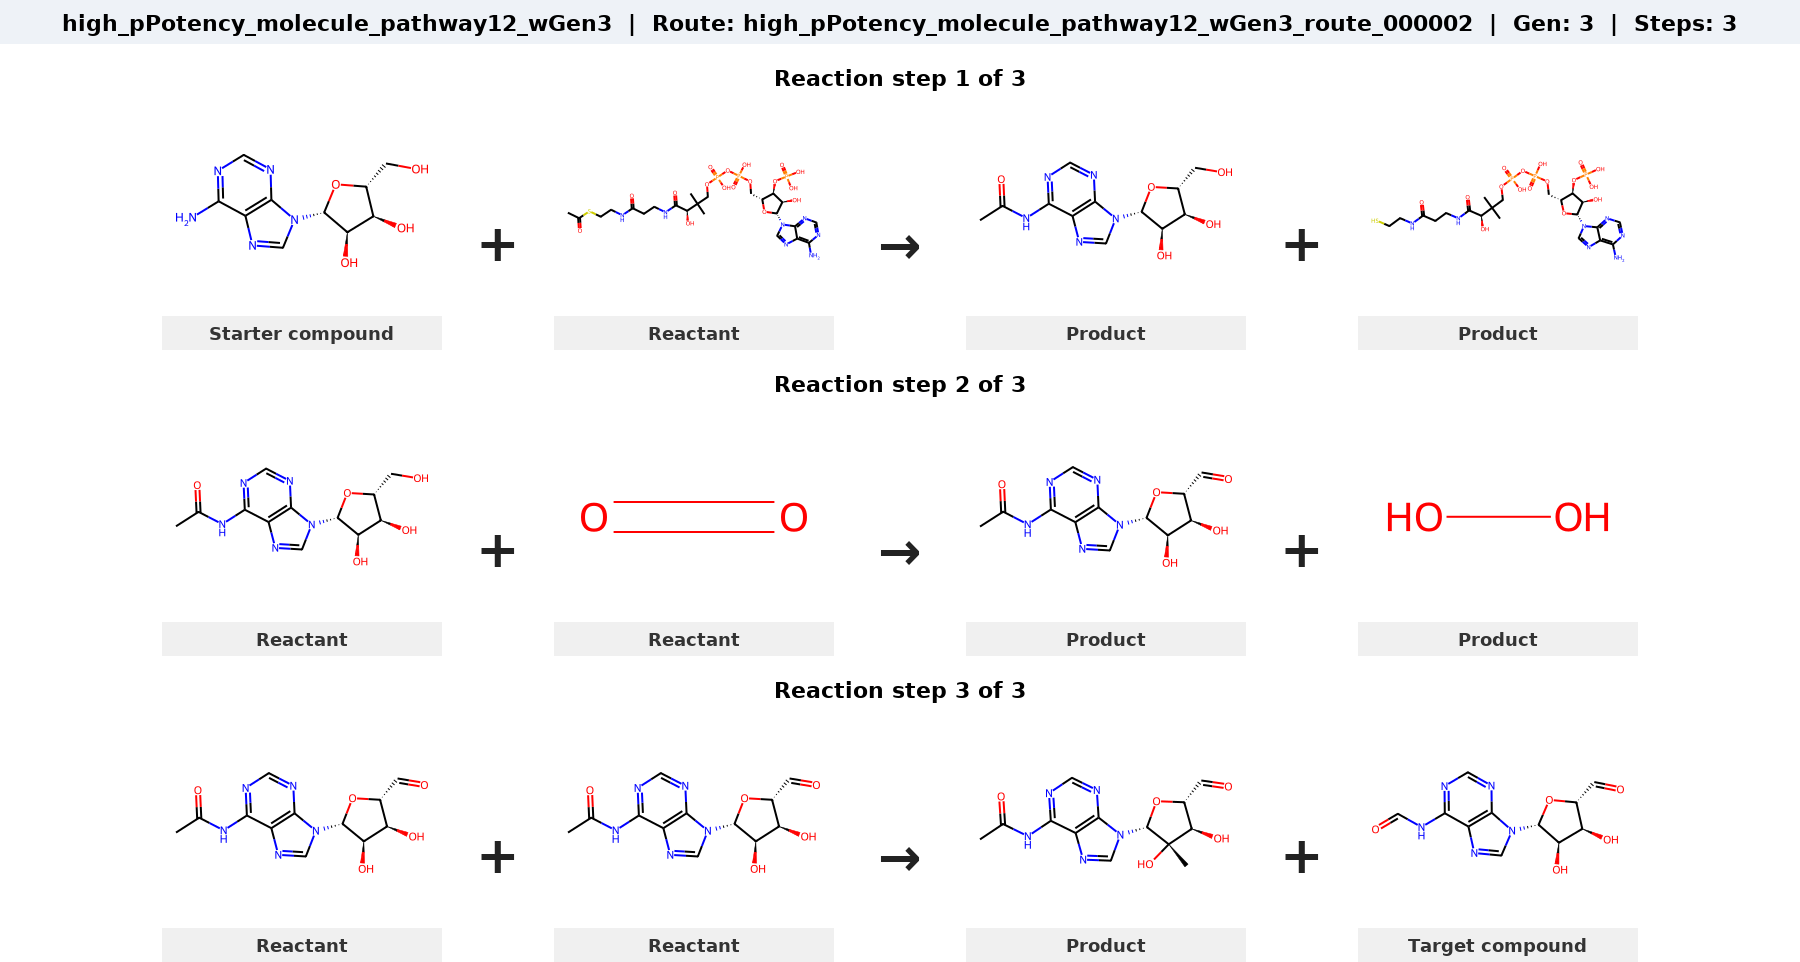

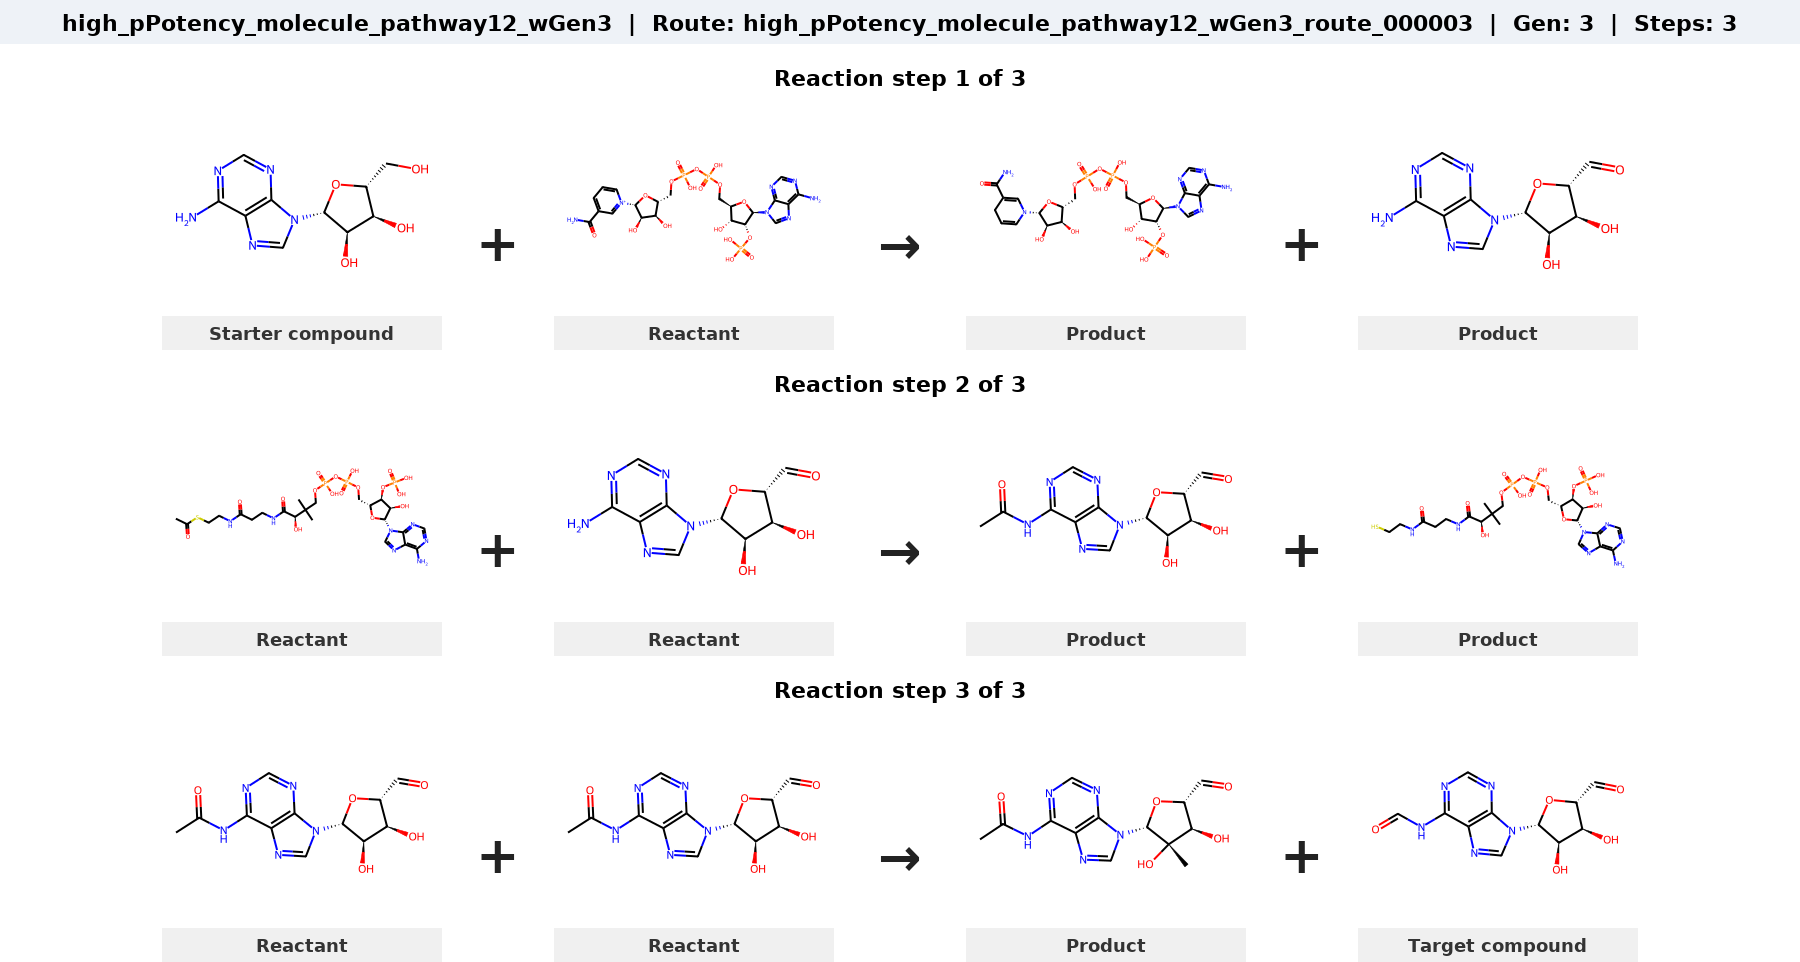

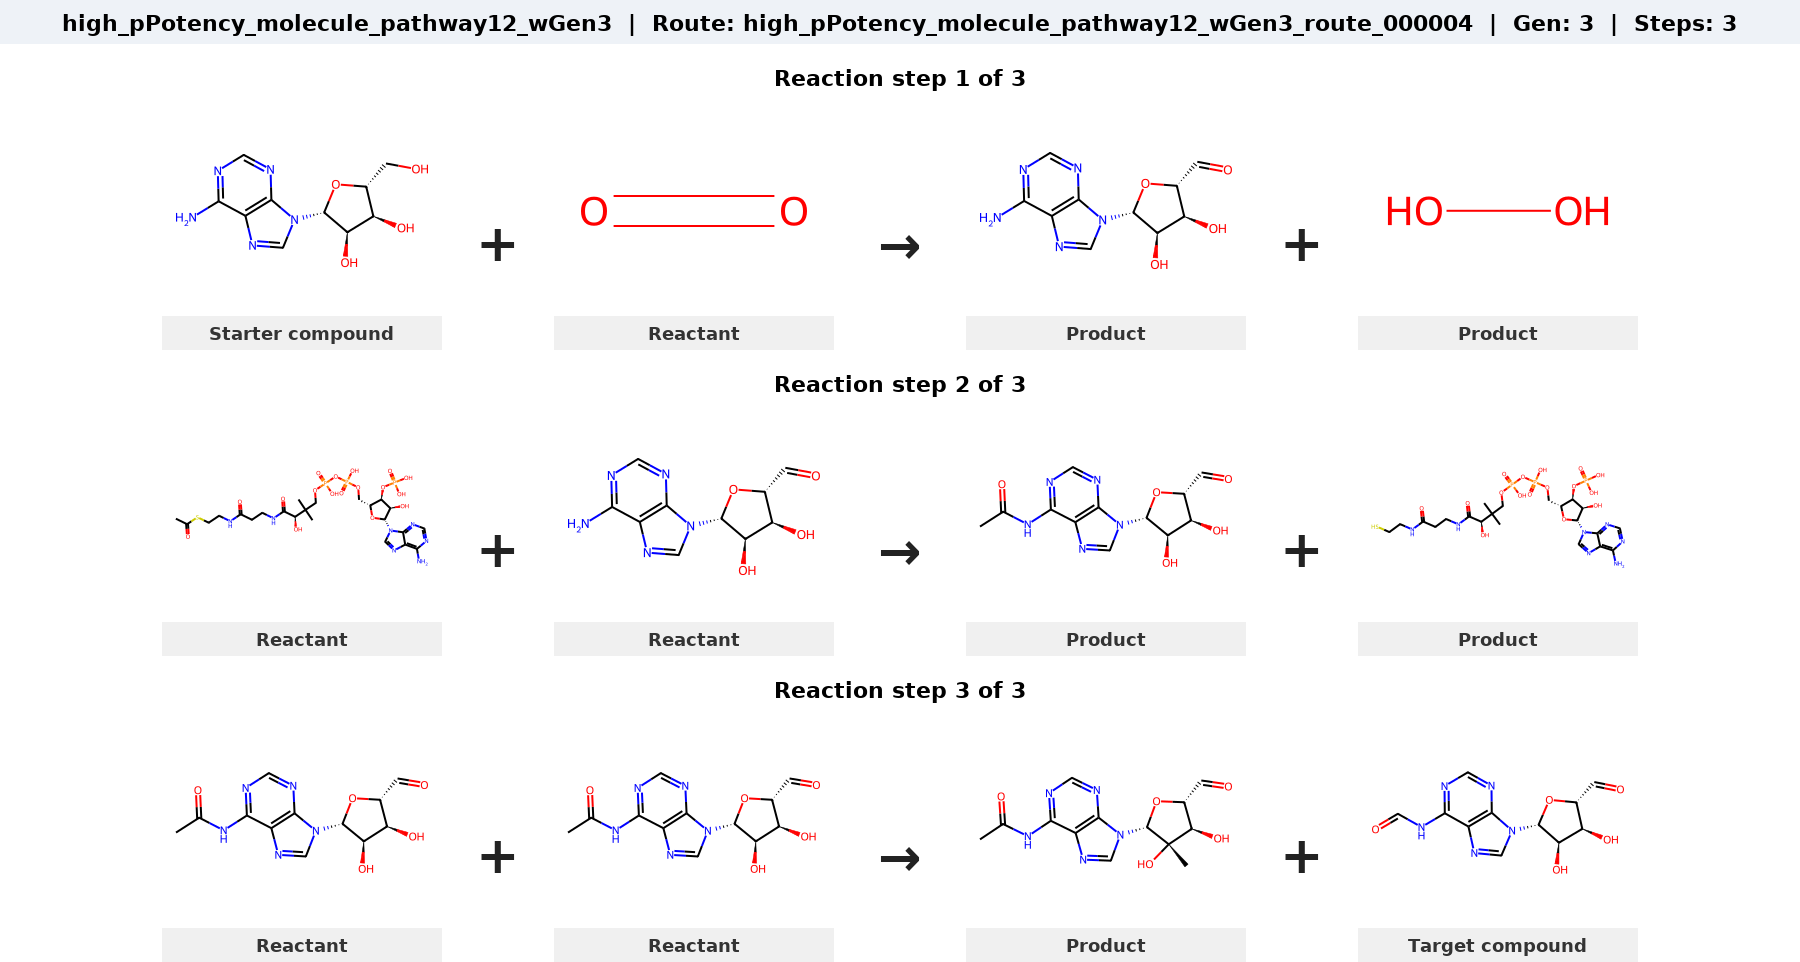

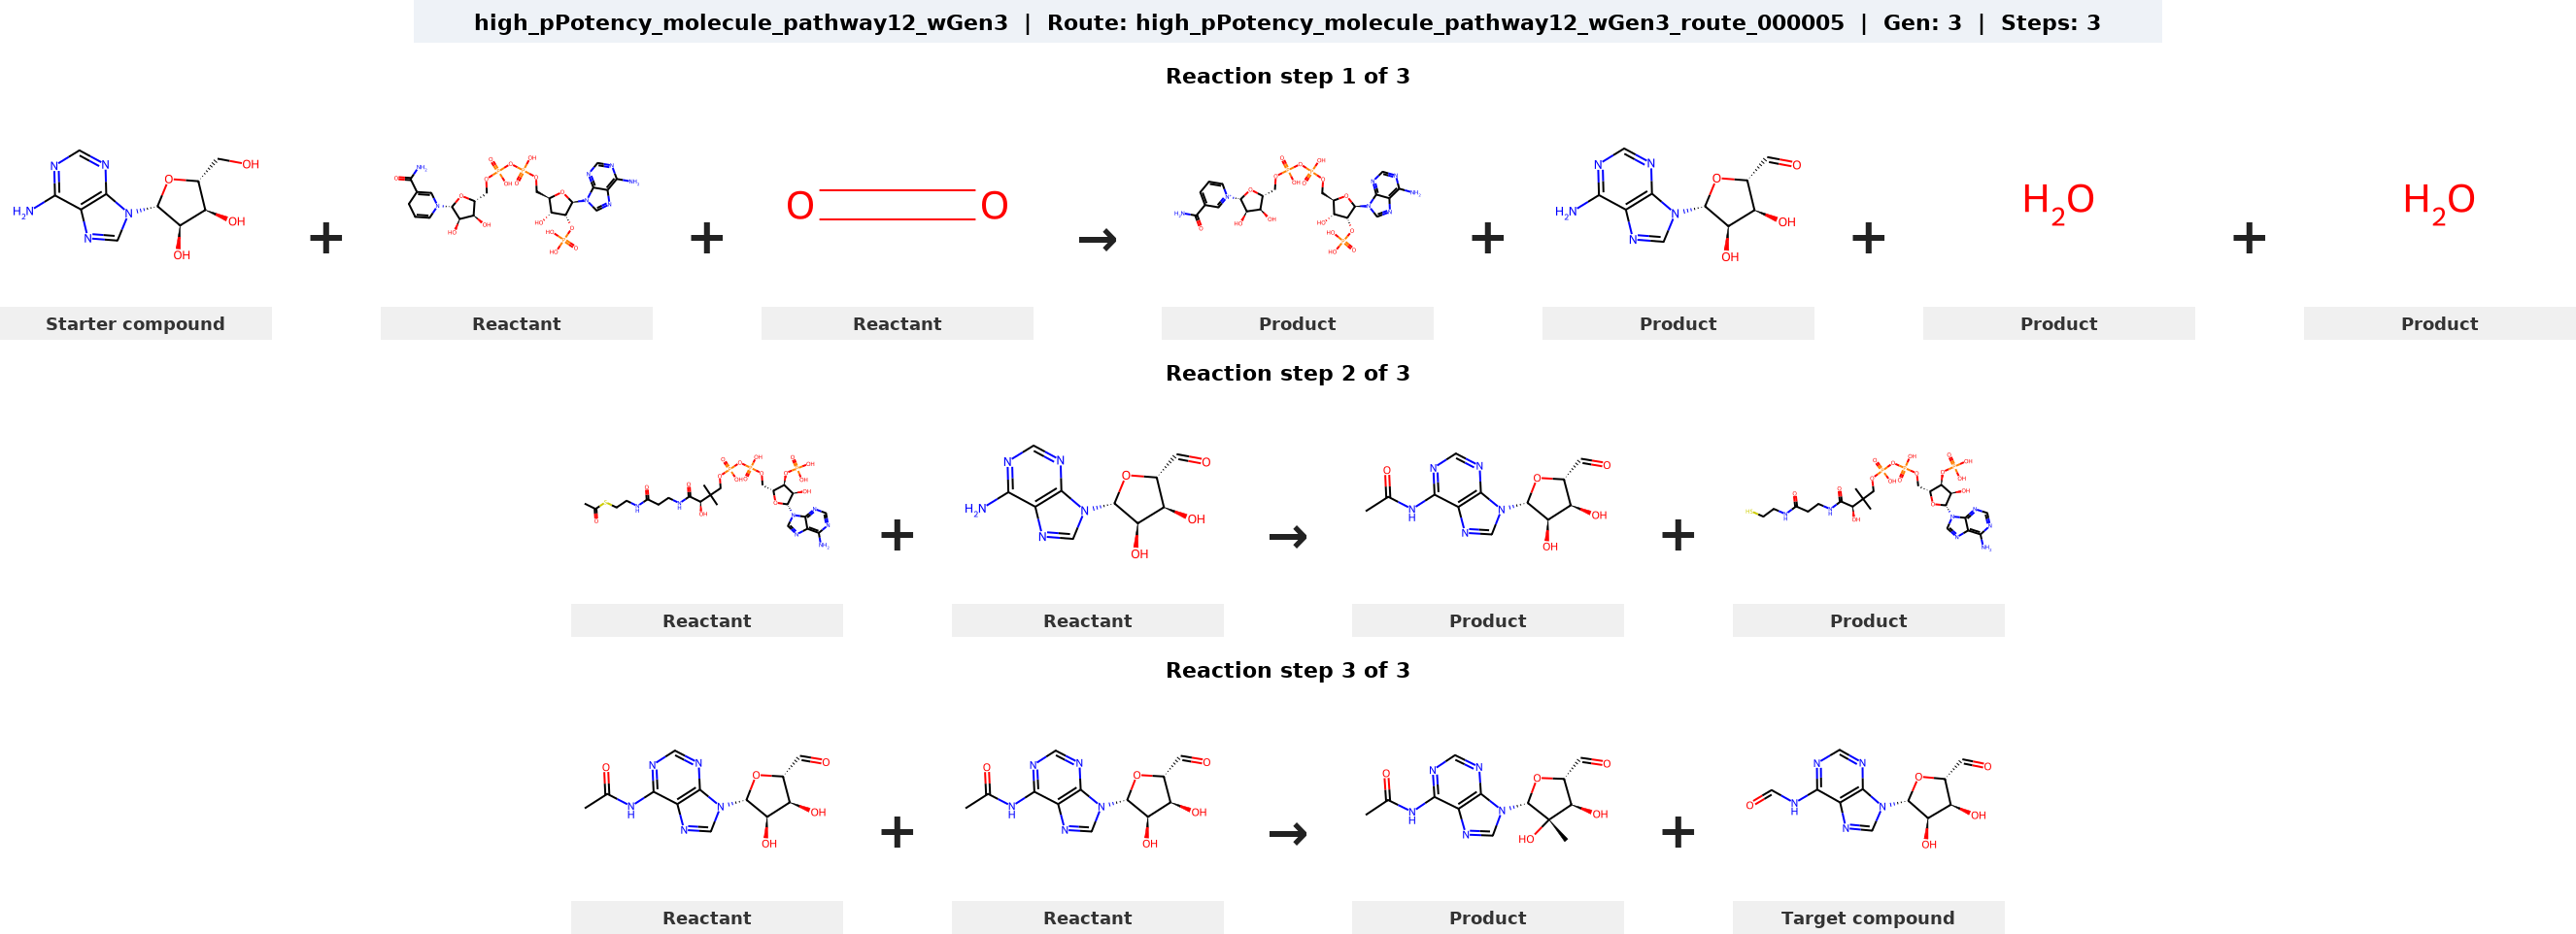

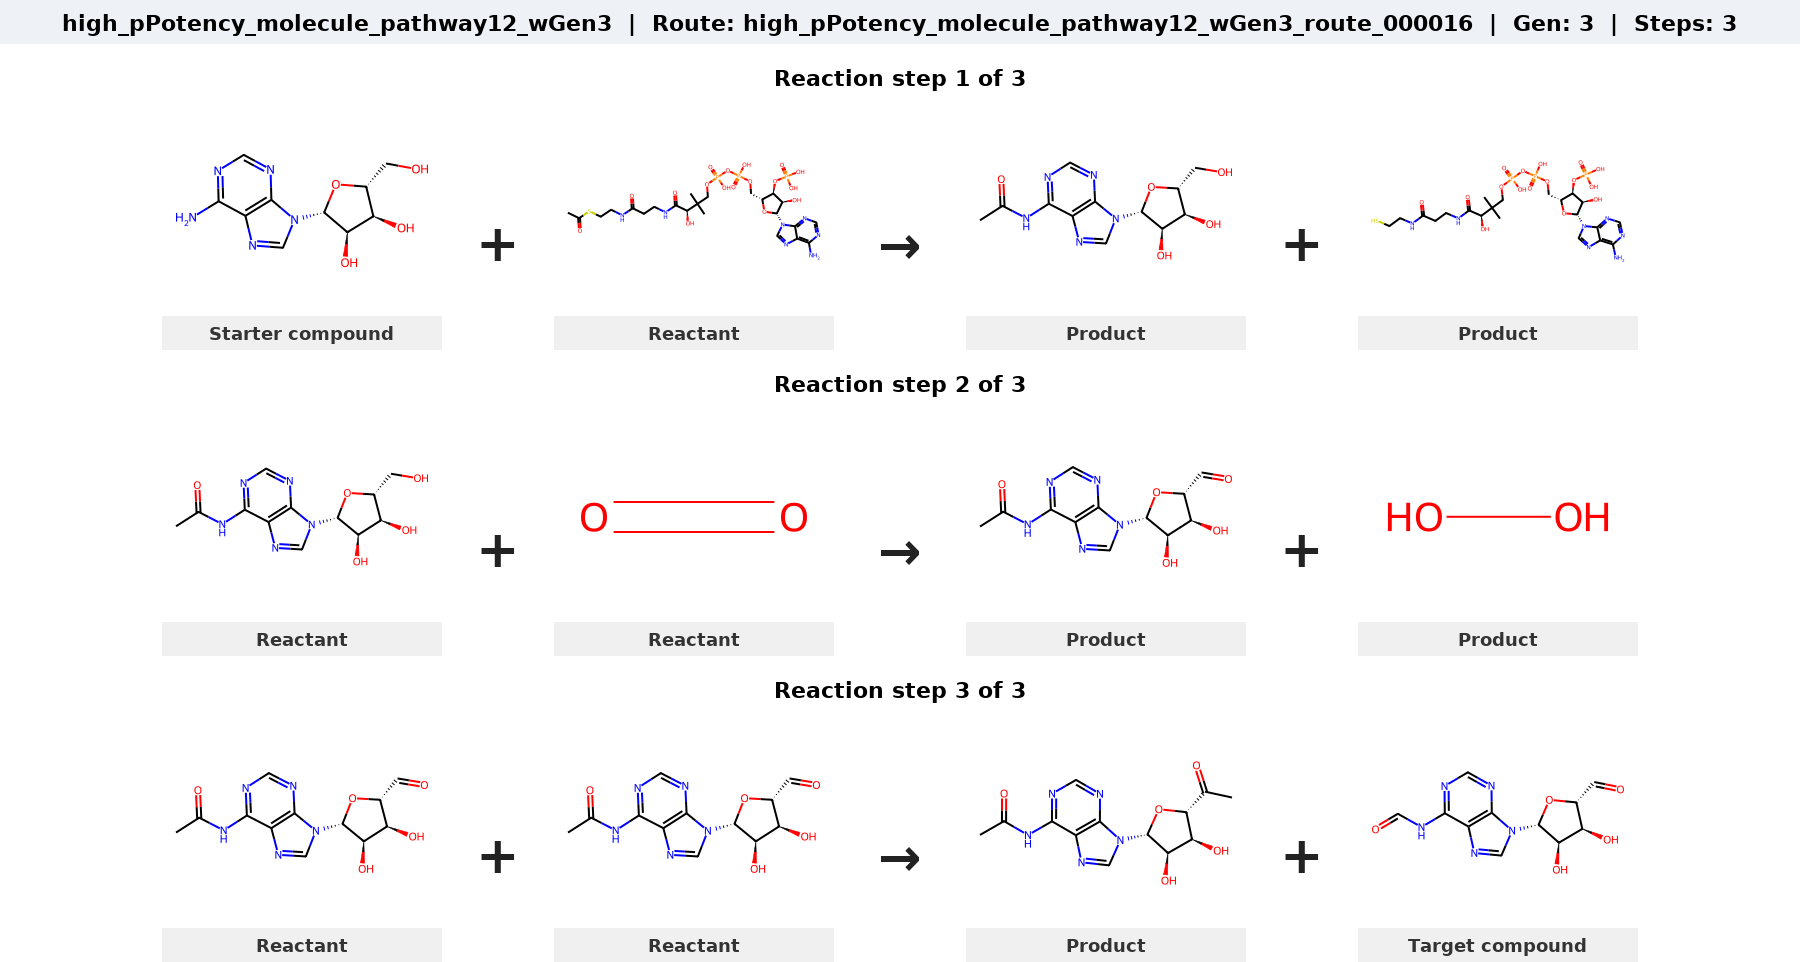

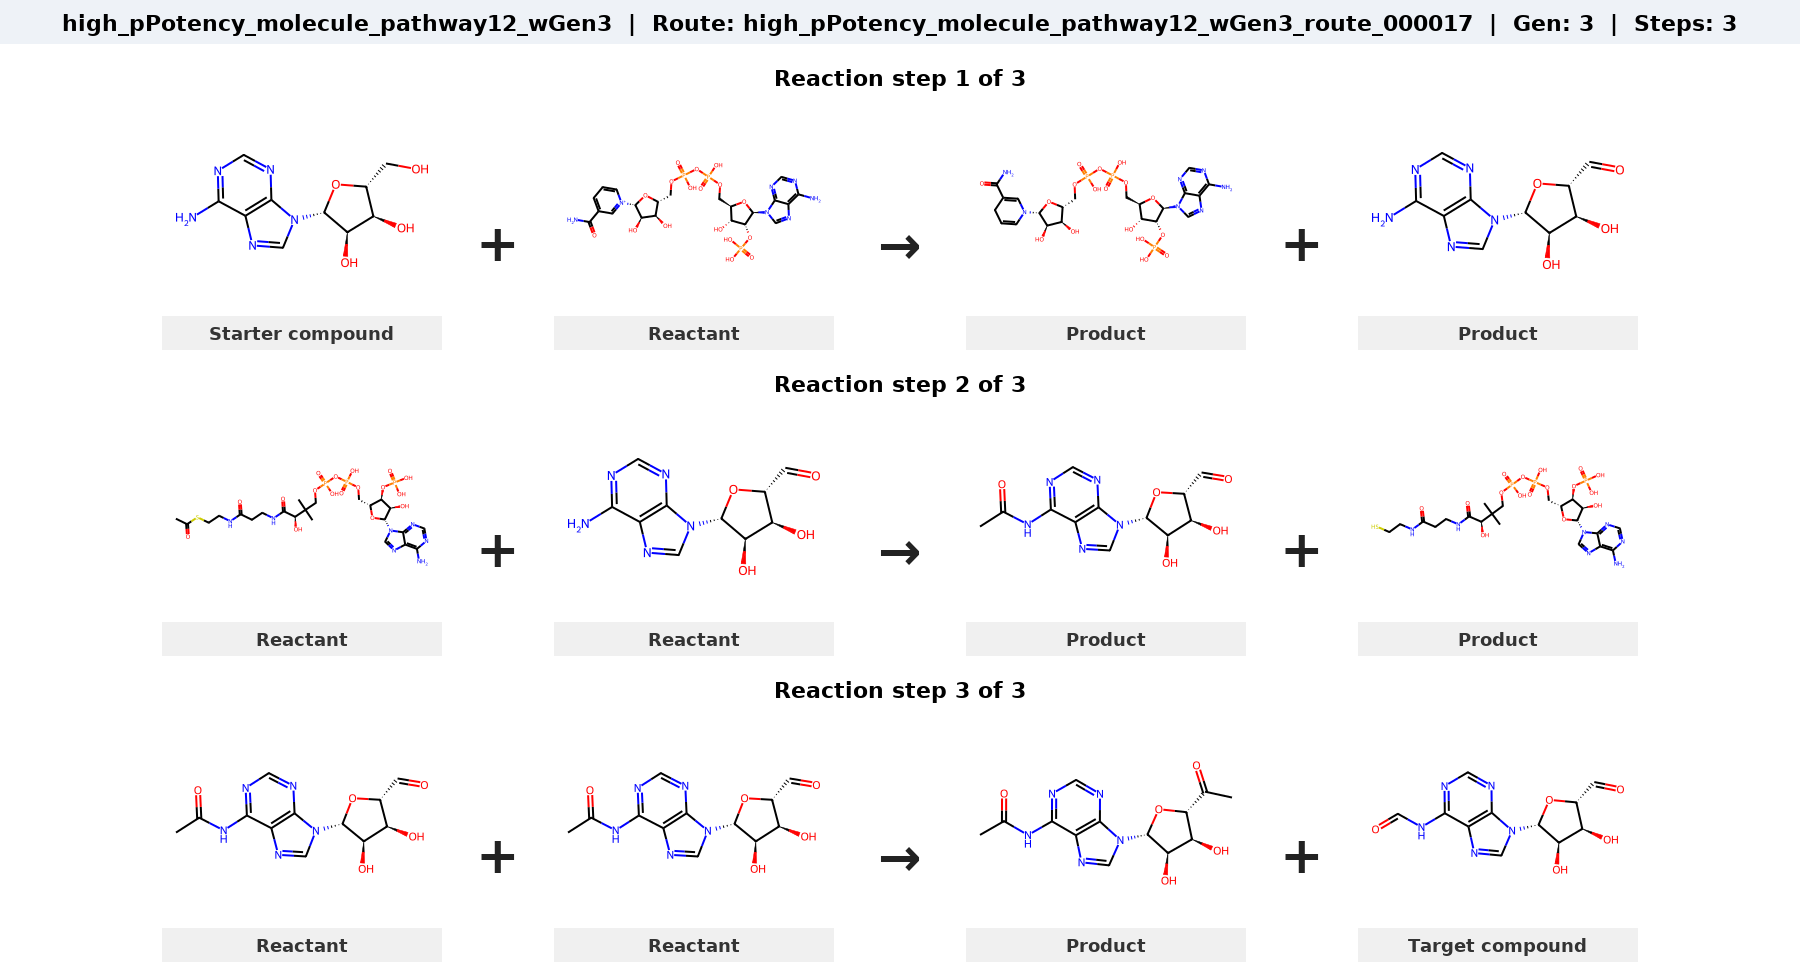

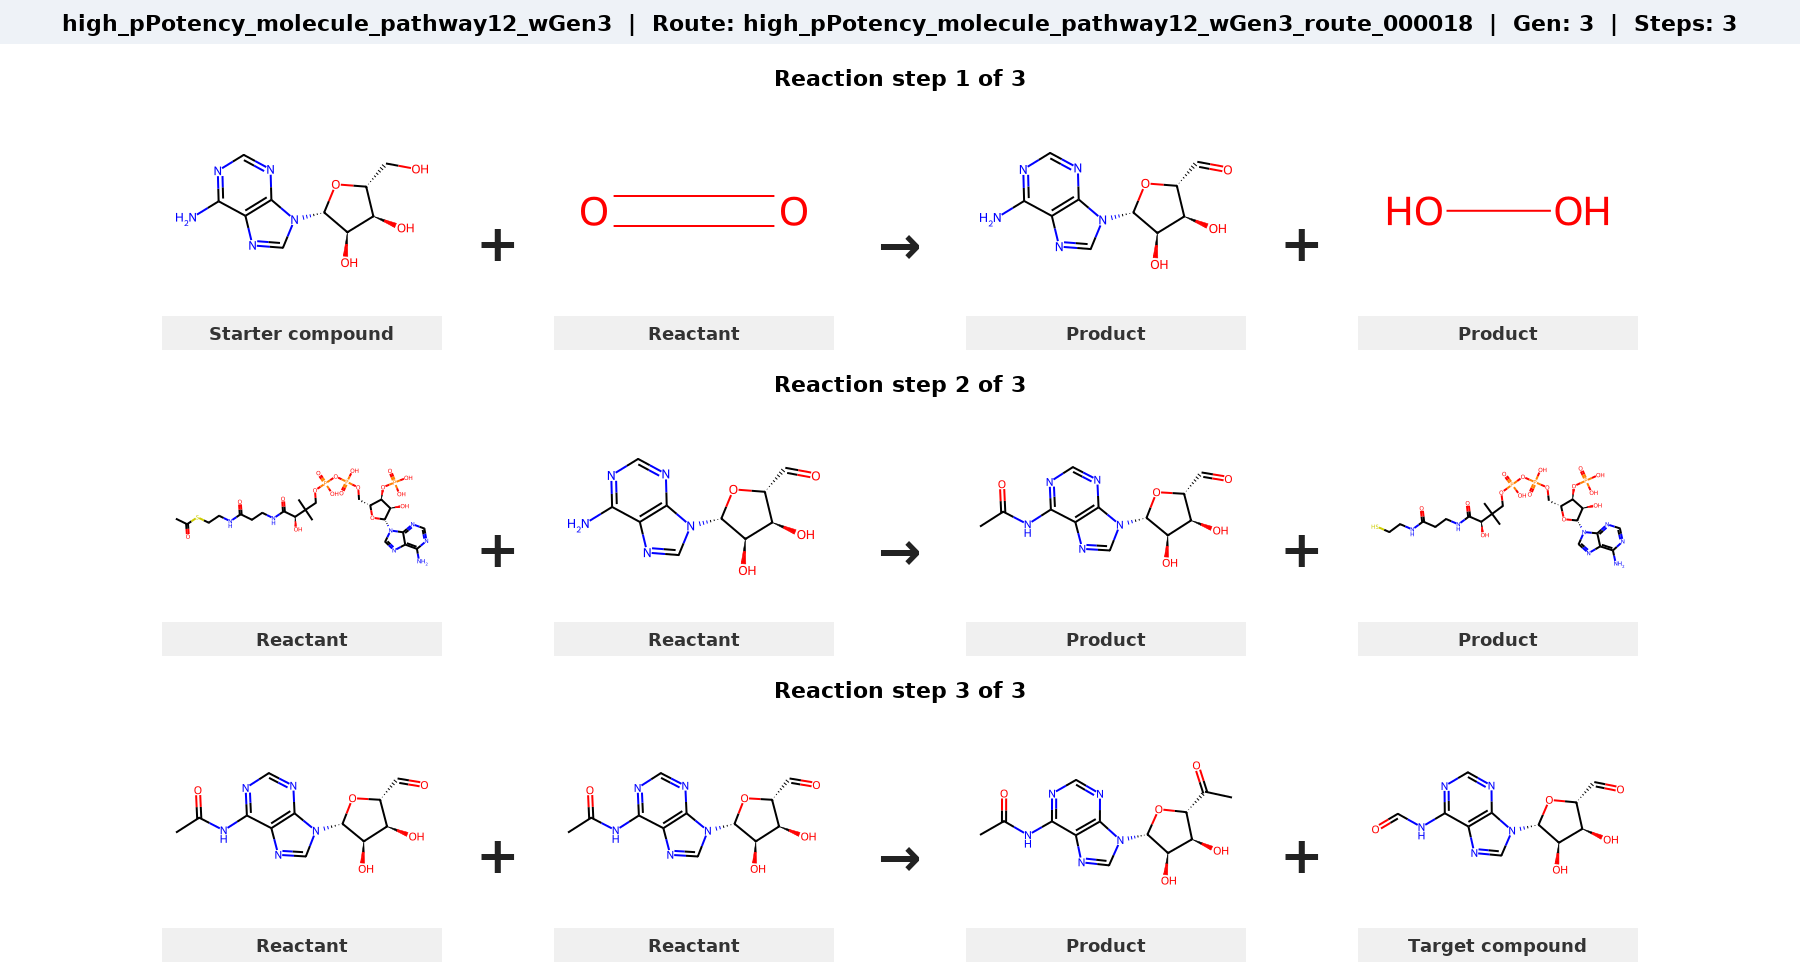

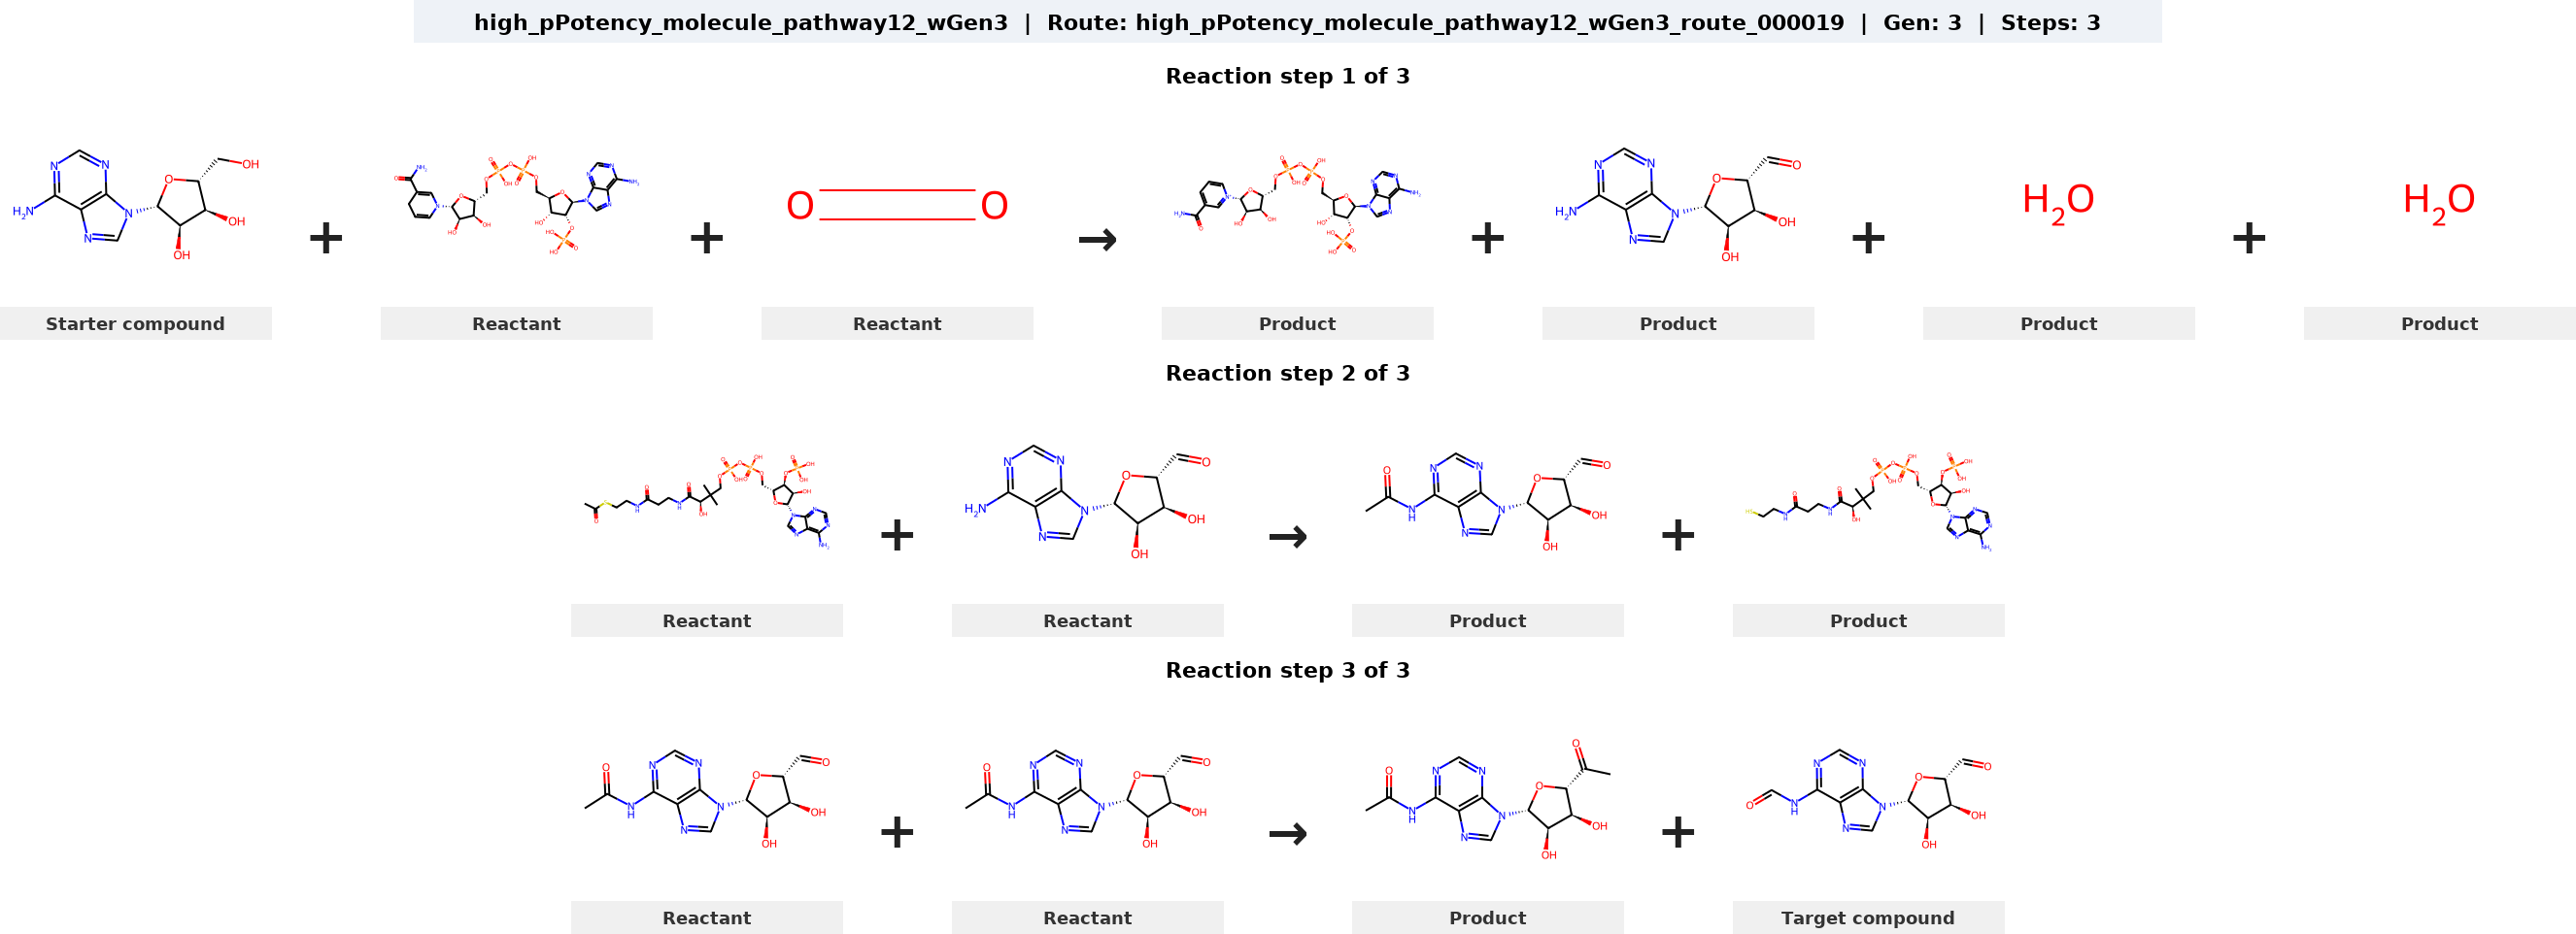

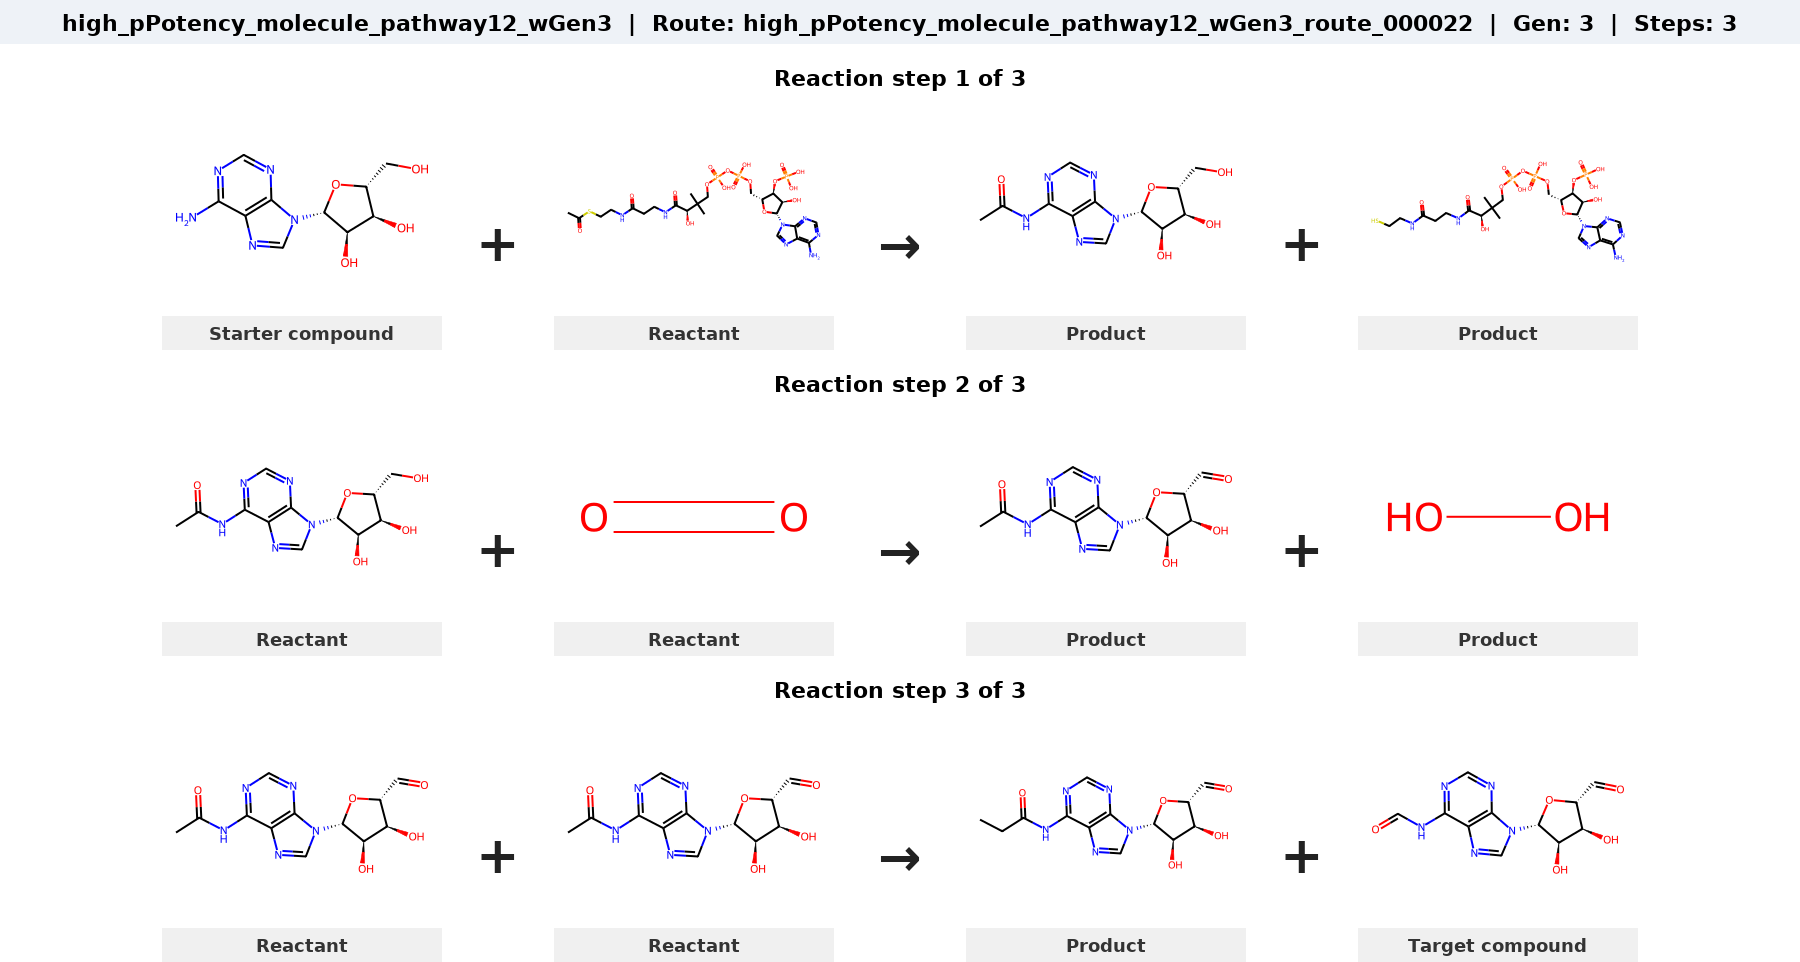

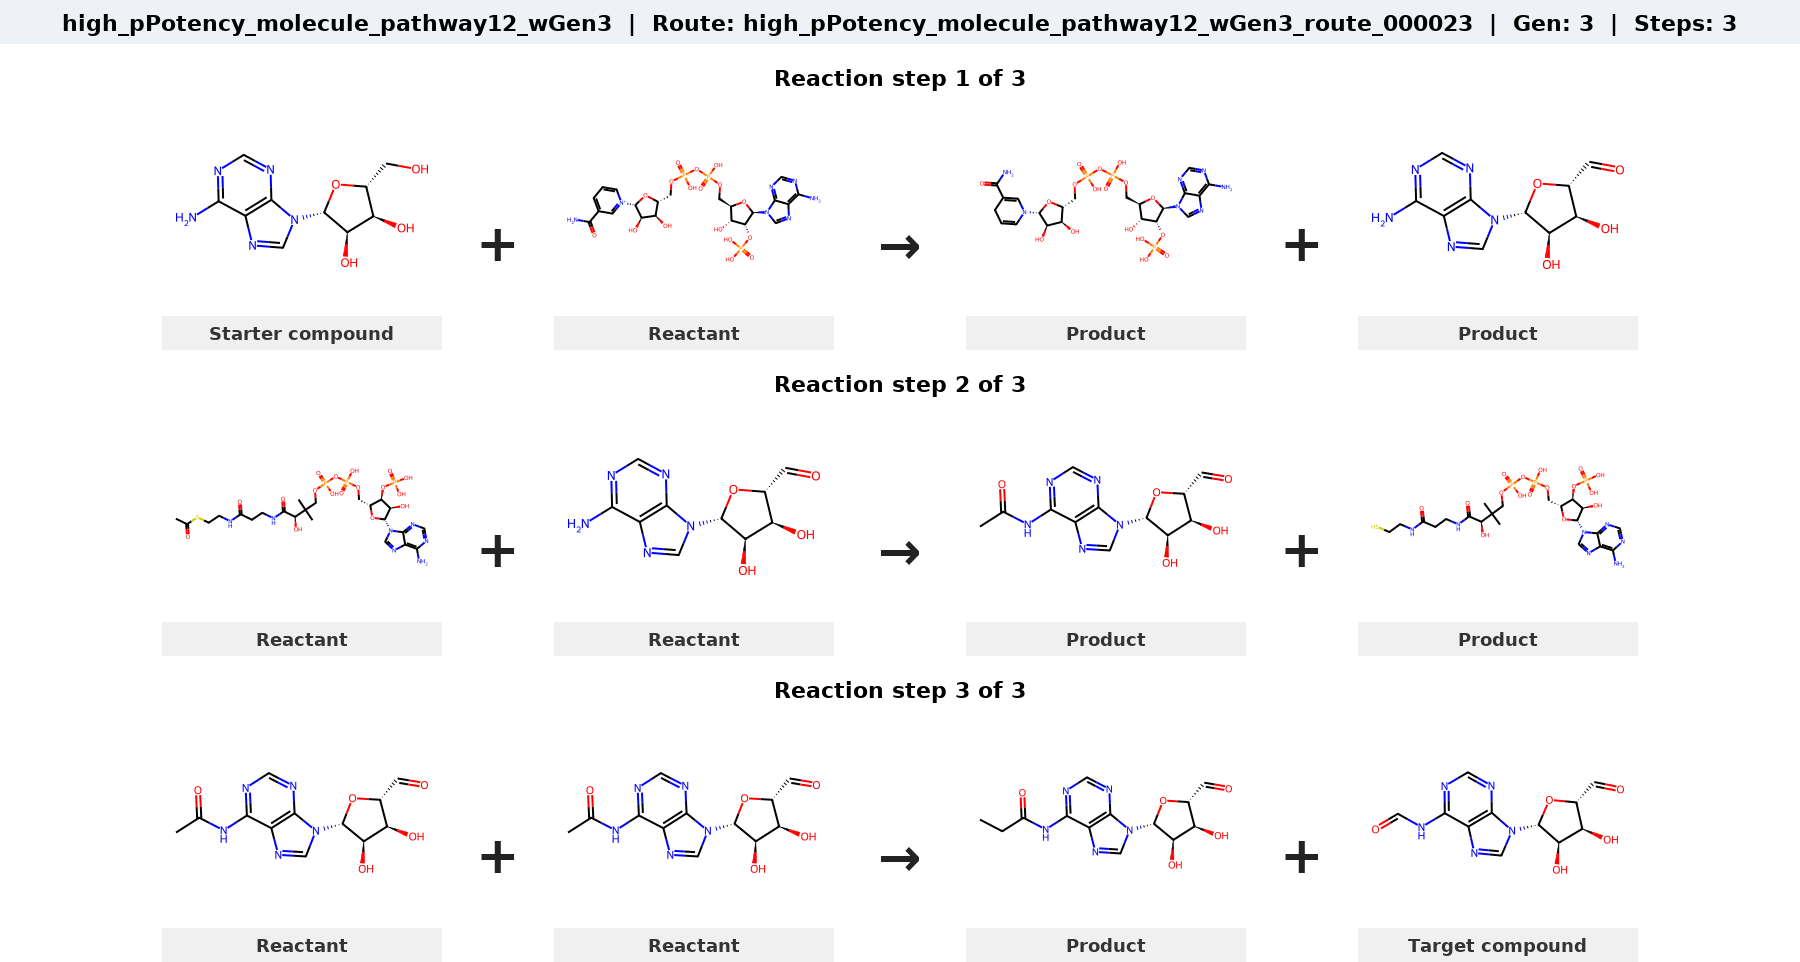

  Saved → /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/DNA_design/pathways_3step.pdf

Complete.


In [149]:
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO

# CONFIG
maxPerStep    = 10
subImgSize    = (280, 210)
pngSubImgSize = (500, 380)
pngDpi        = (300, 300)

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

separatorFont = loadFont(52)
labelFont     = loadFont(18)
headerFont    = loadFont(22)

def splitPathway(pathwayStr):
    return [] if pd.isna(pathwayStr) else [x.strip() for x in str(pathwayStr).split("||") if x.strip()]

def splitStarters(starterStr):
    return [] if pd.isna(starterStr) else [x.strip() for x in str(starterStr).split(";") if x.strip()]

def safeName(rawName):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(rawName))

def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")

def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)

def makeTextBanner(text, bannerWidth, bannerHeight=40, bgColor="white", font=None):
    img = Image.new("RGB", (bannerWidth, bannerHeight), bgColor)
    centeredText(ImageDraw.Draw(img), text, bannerWidth, (bannerHeight - 24) // 2, font or headerFont)
    return img

def stackPanelsVertically(panelList, gapSize=14, bgColor="white"):
    valid = [p for p in panelList if p is not None]
    if not valid:
        return None
    w = max(p.width for p in valid)
    h = sum(p.height for p in valid) + gapSize * (len(valid) - 1)
    canvas = Image.new("RGB", (w, h), bgColor)
    y = 0
    for p in valid:
        canvas.paste(p, ((w - p.width) // 2, y))
        y += p.height + gapSize
    return canvas

def reorderStepsForward(steps, canonStarterSet):
    if len(steps) <= 1:
        return steps
    parsed = []
    for smi in steps:
        if ">>" not in str(smi):
            continue
        rStr, pStr = str(smi).split(">>", 1)
        parsed.append({
            "smi"      : smi,
            "reactants": {canonicalizeSmiles(s.strip()) for s in rStr.split(".") if s.strip()},
            "products" : {canonicalizeSmiles(s.strip()) for s in pStr.split(".") if s.strip()},
        })
    if not parsed:
        return steps
    firstIdx = next((i for i, s in enumerate(parsed) if s["reactants"] & canonStarterSet), None)
    if firstIdx is None:
        return steps
    ordered   = [parsed[firstIdx]]
    remaining = [s for i, s in enumerate(parsed) if i != firstIdx]
    while remaining:
        prevProducts = ordered[-1]["products"]
        nextIdx = next((i for i, s in enumerate(remaining) if s["reactants"] & prevProducts), None)
        if nextIdx is None:
            ordered.extend(remaining)
            break
        ordered.append(remaining[nextIdx])
        remaining = [s for i, s in enumerate(remaining) if i != nextIdx]
    return [s["smi"] for s in ordered]

def getMolLabel(smi, canonStarterSet, canonTargetSmi, side="reactant"):
    canon = canonicalizeSmiles(smi)
    if canon in canonStarterSet:
        return "Starter compound"
    if canon == canonTargetSmi:
        return "Target compound"
    return "Reactant" if side == "reactant" else "Product"

def makeLabeledMolImage(smi, label, subImageSize=(280, 210)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg      = rdkitImageToPil(Draw.MolToImage(mol, size=subImageSize))
    labelBanner = Image.new("RGB", (molImg.width, 34), "#f0f0f0")
    centeredText(ImageDraw.Draw(labelBanner), label, molImg.width, 7, labelFont, "#333333")
    combined = Image.new("RGB", (molImg.width, molImg.height + labelBanner.height), "white")
    combined.paste(molImg,      (0, 0))
    combined.paste(labelBanner, (0, molImg.height))
    return combined

def makeSeparatorImage(text, height, width=90):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bbox         = draw.textbbox((0, 0), text, font=separatorFont)
        textW, textH = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except Exception:
        textW, textH = 30, 50
    draw.text(((width - textW) // 2, (height - textH) // 2), text, fill="#222222", font=separatorFont)
    return img

def makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi,
                             panelTitle, subImageSize=(280, 210)):
    if ">>" not in str(rxnSmi):
        return None
    reactantStr, productStr = str(rxnSmi).split(">>", 1)
    reactantSmiles = (
        [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonicalizeSmiles(s) in canonStarterSet]
        + [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonicalizeSmiles(s) not in canonStarterSet]
    )
    productSmiles = (
        [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonicalizeSmiles(s) != canonTargetSmi]
        + [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonicalizeSmiles(s) == canonTargetSmi]
    )
    reactantImgs = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, side="reactant"), subImageSize)
        for s in reactantSmiles] if img is not None]
    productImgs  = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, side="product"), subImageSize)
        for s in productSmiles]  if img is not None]
    if not reactantImgs or not productImgs:
        return None
    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 16
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    canvas = Image.new("RGB", (totalW, maxH), "white")
    x = 0
    for part in parts:
        canvas.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap
    titleBanner = makeTextBanner(panelTitle, canvas.width, bannerHeight=38)
    final = Image.new("RGB", (canvas.width, canvas.height + titleBanner.height + 10), "white")
    final.paste(titleBanner, (0, 0))
    final.paste(canvas,      (0, titleBanner.height + 10))
    return final

def buildRouteImage(rowData, numSteps, subImageSize, bannerWidth):
    canonStarterSet = {canonicalizeSmiles(s) for s in splitStarters(rowData.get("starterSMILES", ""))}
    canonTargetSmi  = canonicalizeSmiles(rowData.get("targetSMILES", ""))
    forwardSteps    = reorderStepsForward(
        splitPathway(rowData.get("reconstructedPathwayString", np.nan)), canonStarterSet
    )
    panelBlocks = [makeTextBanner(
        f"{rowData['dirName']}  |  Route: {rowData['routeId']}  |  Gen: {rowData['generationRun']}  |  Steps: {numSteps}",
        bannerWidth=bannerWidth, bannerHeight=44, bgColor="#eef2f7",
    )]
    for stepIdx, rxnSmi in enumerate(forwardSteps, start=1):
        panel = makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi,
                                        panelTitle=f"Reaction step {stepIdx} of {numSteps}",
                                        subImageSize=subImageSize)
        if panel:
            panelBlocks.append(panel)
    return stackPanelsVertically(panelBlocks, gapSize=14, bgColor="white")

for numSteps, groupDF in completeRouteLevelDF.groupby("numSteps"):
    subset     = groupDF.head(maxPerStep).reset_index(drop=True)
    stepImages = []
    print(f"\n{numSteps}-step pathways: {len(groupDF):,} available, saving {len(subset):,}")

    for _, rowData in subset.iterrows():
        routeTag   = safeName(str(rowData["routeId"]))
        routeImage = buildRouteImage(rowData, numSteps, subImgSize, bannerWidth=1800)
        if routeImage is None:
            continue
        stepImages.append(routeImage)
        display(routeImage)
        pngImage = buildRouteImage(rowData, numSteps, pngSubImgSize, bannerWidth=3000)
        if pngImage is not None:
            pngImage.save(os.path.join(DNADesignResultsDir, f"pathway_{numSteps}step_{routeTag}.png"), "PNG", dpi=pngDpi)

    if stepImages:
        pdfPath = os.path.join(DNADesignResultsDir, f"pathways_{numSteps}step.pdf")
        stepImages[0].save(pdfPath, "PDF", resolution=150.0, save_all=True, append_images=stepImages[1:])
        print(f"  Saved → {pdfPath}")

print("\nComplete.")